# Inside the Training Loop
### Making a small language model tell the truth about itself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rahulni/Indic_LLM/blob/10-training-loop/10_Training%20Loop/inside_the_training_loop.ipynb)

A language model reads a batch of text and hands back **one number**, the loss. One backward pass turns that number into a gradient for every weight, and one optimizer step moves every weight. Repeat that a few thousand times and a pile of random numbers learns to write stories.

This notebook takes that loop apart and checks each piece with a **measurement** rather than an assertion:

| # | Question | Where |
|---|---|---|
| 1 | What is every tensor in one step, and what does each dimension mean? | §6 |
| 2 | Does the gradient from `backward()` match one measured by nudging a single weight by hand? | §2, §8 |
| 3 | What goes wrong when gradient accumulation averages the wrong way (a bug that lived in major frameworks until 2024)? | §9–§10 |
| 4 | Does the gradient norm move before the loss does? | §11 |
| 5 | How much of the GPU does the loop really use (MFU), and where does the rest go? | §19–§20 |
| 6 | How is 0.1 stored in fp32, bf16 and fp8, bit by bit, and which format should we train in? | §12–§17 |

Two habits run through every section: **print things, and check things.** The serious training bugs are silent: they do not crash, they produce a plausible number and let you keep going. The loss curve will not be the thing that tells you.

## How to read this notebook

Every section has the same shape:

- **Intuition**: the idea in plain words, usually with a picture.
- **Math**: the same idea written exactly, so it can be checked.
- **Code**: the smallest program that shows it.
- **Check**: an `assert` that fails loudly if the claim is wrong (it prints ✓ when it holds).
- **Carry forward**: one line worth remembering.

**Two models, one class.** We write one modern decoder-only transformer (the same blocks Llama, Qwen and SmolLM use) and use it two ways:

| | Model A | SmolLM2-135M |
|---|---|---|
| Weights | trained from scratch here | real pretrained weights from Hugging Face |
| Size | 31.5M parameters (12.6M outside the embedding) | 134.5M parameters |
| Shape | width 384, 8 layers, 6 query heads / 2 key-value heads | width 576, 30 layers, 9 / 3 heads |
| Data | TinyStories, tokenized with SmolLM2's 49,152-token vocabulary | (pretrained on 2T tokens) |
| Used for | every training experiment | the shape tour, the gradient check on trained weights, MFU at real width, a short fine-tune |

**Three modes.** Set `MODE` in the next cell.

| `MODE` | What runs | Needs | Time |
|---|---|---|---|
| `learn` | The cheap demos run live; every training run is **replayed** from the measured results in `assets/results.json` | CPU | a few minutes |
| `quick` | Everything, on a tiny model and a 5 MB data slice. Writes to `assets/quick/` so it never overwrites the real results | any GPU (CPU works, slowly) | ~10 min |
| `full` | The real runs behind every number in the README | a GPU with 8 GB | ~45–75 min on an RTX 3070 Laptop; ~1–1.5 h on a Colab T4 (an estimate, not a measurement) |

**Contents.** Part I, *What one step does*: §1 words · §2 the nudge · §3 backprop by hand · §4 autograd · §5 the model and data · §6 every tensor in one step · §7 one step, start to finish. Part II, *Making the loop tell the truth*: §8 a gradient checked by hand · §9 accumulation · §10 the averaging bug · §11 the gradient norm. Part III, *Numbers inside the machine*: §12 float anatomy · §13 0.1 by hand · §14 the trade · §15 bf16 vs fp16 · §16 newer formats · §17 the choice. Part IV, *What a step costs*: §18 memory · §19 MFU · §20 where the rest goes · §21 watching a long run. Part V: §22 failures that stay quiet · §23 summary.

In [1]:
# ---- the one setting you might change ------------------------------------------------
MODE = "learn"          # "learn" | "quick" | "full"   (see the table above)
# ---------------------------------------------------------------------------------------
import os

MODE = os.environ.get("TL_MODE", MODE)                 # lets a headless run choose the mode
FORCE = os.environ.get("FORCE", "0") == "1"            # ignore cached runs and redo them
PRECISION_OVERRIDE = os.environ.get("TL_PRECISION")    # e.g. "fp16" rehearses the T4 path on any GPU
assert MODE in ("learn", "quick", "full"), MODE
if os.environ.get("TL_MODE"):
    print(f"MODE = {MODE!r}, set by the TL_MODE environment variable, which overrides the line above")

MODE = 'full', set by the TL_MODE environment variable, which overrides the line above


In [2]:
import sys, subprocess, importlib, importlib.util


def ensure(module, pip_name=None):
    """Import a module, installing it first only if it is missing (Colab already has all of these)."""
    try:
        return importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module])
        return importlib.import_module(module)


for _m in ("numpy", "matplotlib", "tokenizers"):
    ensure(_m)

import gc, io, json, math, platform, random, re, struct, time, urllib.request
from collections import OrderedDict, defaultdict
from contextlib import contextmanager
from dataclasses import dataclass, replace, asdict
from fractions import Fraction
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

try:
    from IPython import get_ipython
    from IPython.display import Markdown, display
    _ip = get_ipython()
    IN_NOTEBOOK = _ip is not None and hasattr(_ip, "kernel")
except ImportError:
    IN_NOTEBOOK = False

import matplotlib
if not IN_NOTEBOOK:
    matplotlib.use("Agg")                               # running as a plain script: draw off-screen
import matplotlib.pyplot as plt
from cycler import cycler

In [3]:
HERE = Path.cwd()
DATA = HERE / "data"
ASSETS = HERE / "assets" / ("quick" if MODE == "quick" else "")
CKPT = HERE / "checkpoints" / ("quick" if MODE == "quick" else "")
for _d in (DATA, ASSETS, CKPT):
    _d.mkdir(parents=True, exist_ok=True)

REPO_RAW = "https://raw.githubusercontent.com/rahulni/Indic_LLM/10-training-loop/10_Training%20Loop"

DEV, CAP = "cpu", (0, 0)
try:                                                    # a GPU that is reported but not usable counts as no GPU
    if torch.cuda.is_available() and torch.cuda.device_count() > 0:
        CAP = torch.cuda.get_device_capability()
        DEV = "cuda"
except Exception:
    pass
if PRECISION_OVERRIDE:
    AMP = PRECISION_OVERRIDE
elif DEV == "cuda":
    AMP = "bf16" if CAP >= (8, 0) else "fp16"          # bf16 tensor cores arrived with Ampere (sm80)
else:
    AMP = "fp32"
HAS_TRITON = importlib.util.find_spec("triton") is not None   # torch.compile needs it on GPU

# On Windows (WDDM) the driver quietly pages GPU memory to host RAM instead of raising
# out-of-memory, so "it fits" can be a fiction and every speed number a lie. Capping the
# allocator at what is actually free turns paging back into an honest OOM. Done once.
if DEV == "cuda" and platform.system() == "Windows" and "_MEM_CAP" not in globals():
    _free, _total = torch.cuda.mem_get_info()
    torch.cuda.set_per_process_memory_fraction(_free / _total)
    _MEM_CAP = _free

torch.backends.cuda.matmul.allow_tf32 = False          # fp32 means fp32 unless an experiment says otherwise
torch.backends.cudnn.allow_tf32 = False


def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)


def free_gpu():
    gc.collect()
    if DEV == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def _num(s):
    try:
        return float(s)
    except ValueError:
        return None


def gpu_clocks():
    """SM clock now and at its maximum, temperature and power, from nvidia-smi (empty off-GPU)."""
    if DEV != "cuda":
        return {}
    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=clocks.sm,clocks.max.sm,temperature.gpu,power.draw",
             "--format=csv,noheader,nounits"], capture_output=True, text=True, timeout=10).stdout
        sm, smax, temp, power = [s.strip() for s in out.strip().splitlines()[0].split(",")]
        return dict(sm=_num(sm), sm_max=_num(smax), temp=_num(temp), power=_num(power))
    except Exception:
        return {}


def env_info():
    info = dict(mode=MODE, python=platform.python_version(), torch=torch.__version__,
                platform=platform.platform(), device=DEV, amp=AMP, triton=HAS_TRITON,
                date=time.strftime("%Y-%m-%d %H:%M"))
    if DEV == "cuda":
        p = torch.cuda.get_device_properties(0)
        info.update(gpu=p.name, sms=p.multi_processor_count, capability=f"{p.major}.{p.minor}",
                    vram_gib=round(p.total_memory / 2**30, 2), cuda=torch.version.cuda, clocks=gpu_clocks())
        try:
            info["driver"] = subprocess.run(["nvidia-smi", "--query-gpu=driver_version", "--format=csv,noheader"],
                                            capture_output=True, text=True, timeout=10).stdout.strip()
        except Exception:
            pass
    try:
        info["git_commit"] = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True,
                                            text=True, timeout=10, cwd=HERE).stdout.strip() or None
    except Exception:
        info["git_commit"] = None
    return info


print(f"MODE={MODE}  FORCE={FORCE}  device={DEV}"
      + (f" ({torch.cuda.get_device_name()}, sm{CAP[0]}{CAP[1]})" if DEV == "cuda" else "")
      + f"  autocast={AMP}  torch={torch.__version__}  torch.compile available={HAS_TRITON}")

MODE=full  FORCE=False  device=cuda (NVIDIA GeForce RTX 3070 Laptop GPU, sm86)  autocast=bf16  torch=2.11.0+cu128  torch.compile available=False


**Results store.** Every expensive experiment goes through `experiment(name, fn)`. In `quick` and `full` mode it runs `fn`, stores the result in `results.json` and reuses it if the notebook is re-run (`FORCE=1` redoes everything). In `learn` mode it never trains: it hands back the stored result, so every plot below can be redrawn on a laptop CPU.

In [4]:
RESULTS_FILE = ASSETS / "results.json"


def _load_results():
    if MODE == "learn":
        path = HERE / "assets" / "results.json"
        if not path.exists():
            try:
                urllib.request.urlretrieve(f"{REPO_RAW}/assets/results.json", path)
                print(f"fetched stored results from GitHub -> {path}")
            except Exception as e:
                print(f"no stored results found locally or on GitHub ({e}); replayed sections will be skipped")
                return {}
        return json.loads(path.read_text(encoding="utf-8"))
    if FORCE or not RESULTS_FILE.exists():
        return {}
    return json.loads(RESULTS_FILE.read_text(encoding="utf-8"))


def _clean(o):
    """Make a result JSON-safe and compact: tensors/arrays to lists, floats to 6 significant digits."""
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, torch.Tensor):
        return _clean(o.detach().cpu().tolist())
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    if isinstance(o, (np.floating, float)):
        o = float(o)
        return None if not math.isfinite(o) else float(f"{o:.6g}")
    if isinstance(o, (np.integer,)):
        return int(o)
    return o


R = _load_results()
if MODE != "learn":
    R["env"] = env_info()


def save_results():
    if MODE != "learn":
        RESULTS_FILE.write_text(json.dumps(_clean(R), separators=(",", ":")), encoding="utf-8")


def experiment(name, fn, needs_gpu=False):
    if MODE == "learn":
        if name not in R:
            print(f"[{name}] not in the stored results; skipped")
        return R.get(name)
    if name in R:
        print(f"[{name}] reusing the result stored earlier (FORCE=1 redoes it)")
        return R[name]
    if needs_gpu and DEV != "cuda":
        print(f"[{name}] needs a GPU; skipped on {DEV}")
        return None
    t0 = time.time()
    R[name] = _clean(fn())
    R.setdefault("_seconds", {})[name] = round(time.time() - t0, 1)
    save_results()
    return R[name]


def md_table(rows, headers):
    """A list of rows -> a markdown table (rendered in a notebook, printed in a script)."""
    def fmt(v):
        if isinstance(v, float):
            return f"{v:.4g}" if (abs(v) >= 1e-3 or v == 0) and abs(v) < 1e6 else f"{v:.3e}"
        return str(v)
    lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    lines += ["| " + " | ".join(fmt(v) for v in r) + " |" for r in rows]
    return "\n".join(lines)


def show(text):
    if IN_NOTEBOOK:
        display(Markdown(text))
    else:
        print(text)


def check(cond, msg):
    """Assert, and say so when it holds: every claim in this notebook goes through here."""
    assert cond, "CHECK FAILED: " + msg
    print("✓", msg)


def observe(cond, msg):
    """For outcomes that are measured, not guaranteed: report them either way, never stop the run."""
    print(("✓ " if cond else "✗ (as measured) ") + msg)
    if MODE != "learn":
        R.setdefault("_observations", {})[msg] = bool(cond)

**Plot style.** Dark background; a fixed, colour-blind-checked order of series colours; one y-axis per panel. When two quantities with different units belong together (the loss and the gradient norm, say), they get two panels that share the x-axis, never one panel with two y-scales.

In [5]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#0d1117", "#ffffff", "#c3c2b7", "#898781", "#2c2c2a", "#383835"
C = dict(blue="#3987e5", orange="#d95926", aqua="#199e70", yellow="#c98500",
         magenta="#d55181", green="#008300", violet="#9085e9", red="#e66767")
SERIES = list(C.values())
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "text.color": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 1.6, "font.size": 9.5, "axes.titlesize": 10.5, "axes.titlelocation": "left",
    "legend.frameon": False, "legend.labelcolor": INK2, "axes.prop_cycle": cycler(color=SERIES),
    "figure.dpi": 110, "savefig.dpi": 110, "savefig.bbox": "tight", "axes.axisbelow": True,
})


def finish(fig, name):
    """Save the figure to assets/ (not in learn mode: those are the submitted figures) and show it."""
    if MODE != "learn":
        fig.savefig(ASSETS / f"{name}.png")
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


def label_end(ax, x, y, text, color=INK2, dx=4, dy=0):
    """A direct label at the end of a line, in text ink (the line beside it carries the colour)."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", color=color,
                fontsize=8.5, va="center")

---
# Part I: What one step does

## 1. The words we will need

These words are used loosely almost everywhere, so it pays to fix them once.

| Word | Meaning |
|---|---|
| **gradient** | one number attached to one weight: how much the loss would change if that weight alone moved a little |
| **step** | one complete update: read data, compute the loss, compute every gradient, move every weight once |
| **batch** (global batch) | everything the optimizer "sees" in one step |
| **micro-batch** | what actually fits on one GPU at once; a batch is split into micro-batches when it does not fit |
| **epoch** | one full pass over the dataset. LLM pre-training rarely finishes even one, so we count **steps** and **tokens** instead |

One step is therefore $K$ forward passes, $K$ backward passes and **one** optimizer update, where $K$ is the number of micro-batches per GPU:

$$
\text{global batch} \;=\; \underbrace{\text{micro-batch}}_{\text{what fits}} \times \underbrace{K}_{\text{accumulation steps}} \times \underbrace{\text{number of GPUs}}_{\text{what you can afford}}
$$

**Worked example.** We want 1M tokens per step. Each GPU holds 1,000 tokens and we rent 10 GPUs, so one round of forward passes covers 10,000 tokens. The rest is made up in time instead of hardware: $K = 10^6 / (10^3 \times 10) = 100$ accumulation steps. It is slower than renting 1,000 GPUs, but the arithmetic, and the model you get, are the same.

**Why want a big batch at all?** Each sample's gradient is a noisy vote about which way to move. Averaging $B$ independent votes shrinks the noise like $\sigma/\sqrt{B}$:

$$
\operatorname{Var}\!\Big[\tfrac{1}{B}\textstyle\sum_{i=1}^{B} g_i\Big] = \frac{\sigma^2}{B}
$$

A model that sees one dog, then one cat, then one elephant keeps over-correcting towards the last thing it saw. A model that hears the whole room at once moves towards what is true on average. Language has far more "classes" than any image dataset, which is why LLM batches are measured in millions of tokens.

✓ 1M-token batch on 10 GPUs x 1K tokens = 100 accumulation steps


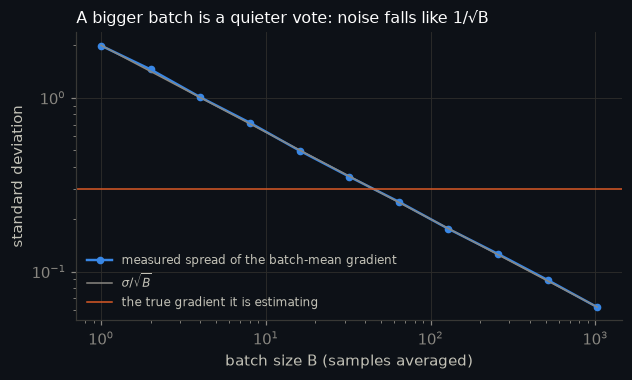

✓ 1024x more samples gives ~32x less noise (1/sqrt(1024))


In [6]:
def accumulation_steps(target_tokens, tokens_per_gpu, n_gpus):
    return math.ceil(target_tokens / (tokens_per_gpu * n_gpus))


check(accumulation_steps(1_000_000, 1_000, 10) == 100, "1M-token batch on 10 GPUs x 1K tokens = 100 accumulation steps")

# Noise of a batch-mean gradient vs batch size: per-sample "gradients" = truth + noise.
gen = torch.Generator().manual_seed(0)
true_g, sigma = 0.3, 2.0
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
spread = []
for B in batch_sizes:
    means = (true_g + sigma * torch.randn(4000, B, generator=gen, dtype=torch.float64)).mean(1)
    spread.append(means.std().item())

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.loglog(batch_sizes, spread, "o-", color=C["blue"], ms=4, label="measured spread of the batch-mean gradient")
ax.loglog(batch_sizes, [sigma / math.sqrt(b) for b in batch_sizes], color=MUTED, lw=1, label=r"$\sigma/\sqrt{B}$")
ax.axhline(true_g, color=C["orange"], lw=1, label="the true gradient it is estimating")
ax.set_xlabel("batch size B (samples averaged)")
ax.set_ylabel("standard deviation")
ax.set_title("A bigger batch is a quieter vote: noise falls like 1/√B")
ax.legend(loc="lower left", fontsize=8)
finish(fig, "batch_noise")
check(abs(spread[-1] / spread[0] - 1 / math.sqrt(1024)) < 0.01, "1024x more samples gives ~32x less noise (1/sqrt(1024))")

Below about $B=64$ the noise is bigger than the gradient itself: a single step is as likely to point the wrong way as the right way. Above it, every step points roughly the right way.

> **Carry forward:** a gradient belongs to one weight, and a step moves all of them at once. The batch the optimizer sees is a choice, independent of what fits in memory.

## 2. Where a gradient comes from: the nudge

**Intuition.** Forget calculus for a moment. Take one weight, raise it by a tiny amount, run the model again and see how much the loss moved. The ratio is the gradient: *which way* to move this weight, and *how urgently*.

Our toy model has one input, two weights and a target: input $x = 2$, weights $w_1 = 3$, $w_2 = 4$, target $t = 20$:

$$
h = w_1 x, \qquad y = w_2 h, \qquad \mathcal{L} = (y - t)^2
$$

| $w_1$ | $y$ | loss |
|---|---|---|
| 3.000 | 24.000 | 16.000 |
| 3.001 | 24.008 | 16.064 |

The loss rose by 0.064 when $w_1$ rose by 0.001, so $\partial\mathcal{L}/\partial w_1 \approx 0.064/0.001 = 64$. Positive means raising this weight makes things worse, so the optimizer will lower it. Large means this weight matters a lot right now.

**Math: how good is a nudge?** Taylor's theorem tells us exactly what a finite difference measures:

$$
\underbrace{\frac{f(w+\varepsilon) - f(w)}{\varepsilon}}_{\text{forward difference}} = f'(w) + \tfrac{1}{2} f''(w)\,\varepsilon + O(\varepsilon^2)
\qquad
\underbrace{\frac{f(w+\varepsilon) - f(w-\varepsilon)}{2\varepsilon}}_{\text{central difference}} = f'(w) + \tfrac{1}{6} f'''(w)\,\varepsilon^2 + O(\varepsilon^4)
$$

For our toy loss $f''(w_1) = 2(x w_2)^2 = 128$, so the forward difference is off by exactly $\tfrac12 \cdot 128 \cdot 0.001 = 0.064$: it reads 64.064, not 64. The central difference cancels the $\varepsilon$ term, and because this loss is quadratic ($f''' = 0$) it is exact.

So why not make $\varepsilon$ tiny? Because the computer stores each loss with a relative error of about $u$ (the unit roundoff: $2^{-24} \approx 6\times10^{-8}$ in fp32, $2^{-53} \approx 1.1\times10^{-16}$ in fp64), and dividing by $\varepsilon$ magnifies it:

$$
\text{error}(\varepsilon) \;\approx\; \underbrace{\tfrac12 |f''|\,\varepsilon}_{\text{truncation: wants small } \varepsilon} \;+\; \underbrace{\frac{2u\,|f|}{\varepsilon}}_{\text{roundoff: wants large } \varepsilon}
\quad\Rightarrow\quad \varepsilon^\star \sim \sqrt{u}\ \text{(forward)},\quad \varepsilon^\star \sim u^{1/3}\ \text{(central)}
$$

The plot below measures this V shape on a function with curvature in every derivative.

In [7]:
def toy_loss(w1, x=2.0, w2=4.0, t=20.0):
    return (w2 * (w1 * x) - t) ** 2


rows = [(w, toy_loss(w)) for w in (3.000, 3.001)]
show(md_table([(f"{w:.3f}", f"{l:.6f}") for w, l in rows], ["w1", "loss"]))
fwd = (toy_loss(3.001) - toy_loss(3.0)) / 0.001
cen = (toy_loss(3.001) - toy_loss(2.999)) / 0.002
print(f"forward difference: {fwd:.6f}    central difference: {cen:.6f}    exact: 64")
check(abs(fwd - 64.064) < 1e-6, "forward difference is off by exactly f''·ε/2 = 0.064")
check(abs(cen - 64.0) < 1e-6, "central difference is exact for a quadratic loss")

| w1 | loss |
|---|---|
| 3.000 | 16.000000 |
| 3.001 | 16.064064 |

forward difference: 64.064000    central difference: 64.000000    exact: 64
✓ forward difference is off by exactly f''·ε/2 = 0.064
✓ central difference is exact for a quadratic loss


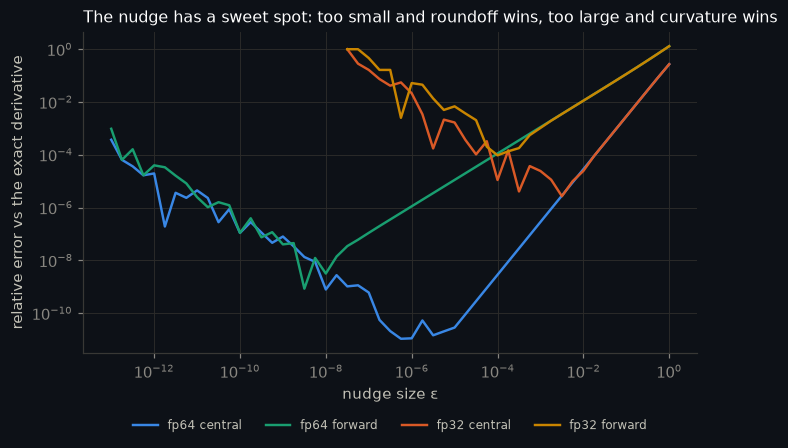

fp64 central  best relative error ≈ 1.5e-11  (~11 matching digits)
fp64 forward  best relative error ≈ 1.2e-08  (~8 matching digits)
fp32 central  best relative error ≈ 1.0e-05  (~5 matching digits)
fp32 forward  best relative error ≈ 1.8e-04  (~4 matching digits)
✓ fp64 central differences reach 9+ matching digits
✓ fp32 bottoms out orders of magnitude higher, whatever ε you pick


In [8]:
# A loss with curvature in every derivative, so the V shape is visible:
#   L(w) = (w2 * softplus(w x) - t)^2,  dL/dw = 2 (y - t) w2 sigmoid(w x) x
def soft_loss(w, dtype):
    w = torch.tensor(w, dtype=dtype)
    return ((4.0 * F.softplus(w * 2.0) - 3.0) ** 2).item()


def soft_grad_exact(w):
    y = 4.0 * math.log1p(math.exp(2.0 * w))
    return 2 * (y - 3.0) * 4.0 * (1 / (1 + math.exp(-2.0 * w))) * 2.0


w0, exact = 0.7, soft_grad_exact(0.7)
eps_grid = [10.0 ** e for e in np.arange(-13, 0.01, 0.25)]
curves = {}
for dname, dt in (("fp64", torch.float64), ("fp32", torch.float32)):
    for kind in ("central", "forward"):
        errs = []
        for eps in eps_grid:
            # Evaluate at w ± eps rounded into the working precision, as a real nudge would be.
            wp = torch.tensor(w0 + eps, dtype=dt).item(); wm = torch.tensor(w0 - eps, dtype=dt).item()
            w_ = torch.tensor(w0, dtype=dt).item()
            if kind == "central":
                num = (soft_loss(wp, dt) - soft_loss(wm, dt)) / (wp - wm) if wp != wm else float("nan")
            else:
                num = (soft_loss(wp, dt) - soft_loss(w_, dt)) / (wp - w_) if wp != w_ else float("nan")
            errs.append(abs(num - exact) / abs(exact) if num == num else float("nan"))
        curves[f"{dname} {kind}"] = errs

fig, ax = plt.subplots(figsize=(7.2, 3.8))
styles = {"fp64 central": C["blue"], "fp64 forward": C["aqua"], "fp32 central": C["orange"], "fp32 forward": C["yellow"]}
for name, errs in curves.items():
    e = np.array(errs, dtype=float); e[e == 0] = 1e-17
    ax.loglog(eps_grid, e, color=styles[name], label=name)
ax.set_xlabel("nudge size ε")
ax.set_ylabel("relative error vs the exact derivative")
ax.set_title("The nudge has a sweet spot: too small and roundoff wins, too large and curvature wins")
ax.legend(fontsize=8, loc="upper center", ncol=4, bbox_to_anchor=(0.5, -0.17))
finish(fig, "nudge_error_vs_eps")

# The floor of each curve, robust to the odd lucky cancellation: the 3rd-smallest error.
floor = {k: np.sort(np.array(v, dtype=float)[np.isfinite(v)])[2] for k, v in curves.items()}
for k, v in floor.items():
    print(f"{k:13s} best relative error ≈ {v:.1e}  (~{-math.log10(v):.0f} matching digits)")
check(floor["fp64 central"] < 1e-9, "fp64 central differences reach 9+ matching digits")
check(floor["fp32 central"] > 100 * floor["fp64 central"], "fp32 bottoms out orders of magnitude higher, whatever ε you pick")

Read the plot from right to left. At large $\varepsilon$ the error falls as the nudge shrinks: a slope of 1 for forward differences, 2 for central. Then it hits the roundoff floor and climbs back up as $1/\varepsilon$. fp64 bottoms out around $10^{-11}$. fp32 bottoms out around $10^{-5}$, six orders of magnitude worse, so a gradient check in fp32 can confirm about five digits and no more.

This is why a gradient check on a real model (§8) is done in **float64**: in fp32 a mismatch in the fifth digit tells you nothing.

> **Carry forward:** a gradient is the answer to a nudge: which way, and how urgently. Measure it with a central difference, in float64, with $\varepsilon \approx 10^{-6}$.

## 3. Following the loss backwards (backpropagation by hand)

**Intuition.** $w_1$ never touches the loss directly. It changes $h$, which changes $y$, which changes the loss. So we walk back one link at a time, multiplying by how much each link amplifies a small change.

| Quantity | Calculation | Value |
|---|---|---|
| $h$ | $w_1 \times x = 3 \times 2$ | 6 |
| $y$ | $w_2 \times h = 4 \times 6$ | 24 |
| $\mathcal{L}$ | $(24 - 20)^2$ | 16 |

$$
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial y} &= 2(y - t) = 8 \\
\frac{\partial \mathcal{L}}{\partial w_2} &= \frac{\partial \mathcal{L}}{\partial y}\cdot h = 8 \times 6 = 48 \\
\frac{\partial \mathcal{L}}{\partial h} &= \frac{\partial \mathcal{L}}{\partial y}\cdot w_2 = 8 \times 4 = 32 \\
\frac{\partial \mathcal{L}}{\partial w_1} &= \frac{\partial \mathcal{L}}{\partial h}\cdot x = 32 \times 2 = 64
\end{aligned}
$$

That is all of backpropagation: **one number comes back from the loss, and every link multiplies it by one local factor.** The 64 matches the nudge.

**Math: the same thing for real layers.** A linear layer computes $y = W x$ with $W \in \mathbb{R}^{m\times n}$. Given the incoming gradient $\bar y = \partial\mathcal{L}/\partial y$, the chain rule gives two outgoing products:

$$
\bar x = W^{\top} \bar y \quad (\text{passed further back}), \qquad \bar W = \bar y\, x^{\top} \quad (\text{this layer's weight gradient})
$$

Each is a matrix product the same size as the forward one. So **backward costs about twice the forward**: for $N$ weights and one token, the forward pass costs $2N$ FLOPs (a multiply and an add per weight) and the backward $4N$. That is the origin of the **$6N$ FLOPs per token** rule we use for MFU in §19.

It also explains why backprop runs *backwards* (reverse mode): there is one output (the loss) and billions of inputs (the weights). One reverse sweep gives all of them for about 2× the cost of a forward pass. A forward-mode sweep would give the derivative for one weight at a time.

In [9]:
x, t = 2.0, 20.0
w1 = torch.tensor(3.0, dtype=torch.float64, requires_grad=True)
w2 = torch.tensor(4.0, dtype=torch.float64, requires_grad=True)
h = w1 * x
y = w2 * h
loss = (y - t) ** 2
loss.backward()

dL_dy = 2 * (y.item() - t)
by_hand = dict(dL_dy=dL_dy, dL_dw2=dL_dy * h.item(), dL_dh=dL_dy * w2.item(), dL_dw1=dL_dy * w2.item() * x)
print("by hand :", by_hand)
print("autograd:", dict(dL_dw1=w1.grad.item(), dL_dw2=w2.grad.item()))
check(by_hand["dL_dw1"] == w1.grad.item() == 64.0, "chain rule by hand = autograd = nudge = 64")
check(by_hand["dL_dw2"] == w2.grad.item() == 48.0, "dL/dw2 = 8 x h = 48")

# The matrix version: for y = W x, x̄ = Wᵀ ȳ and W̄ = ȳ xᵀ.
gen = torch.Generator().manual_seed(1)
W = torch.randn(5, 3, dtype=torch.float64, generator=gen, requires_grad=True)
xv = torch.randn(3, dtype=torch.float64, generator=gen, requires_grad=True)
ybar = torch.randn(5, dtype=torch.float64, generator=gen)
(W @ xv).backward(ybar)
check(torch.allclose(xv.grad, W.detach().T @ ybar), "input gradient of a linear layer is Wᵀ·ȳ")
check(torch.allclose(W.grad, torch.outer(ybar, xv.detach())), "weight gradient of a linear layer is ȳ·xᵀ (an outer product)")

by hand : {'dL_dy': 8.0, 'dL_dw2': 48.0, 'dL_dh': 32.0, 'dL_dw1': 64.0}
autograd: {'dL_dw1': 64.0, 'dL_dw2': 48.0}
✓ chain rule by hand = autograd = nudge = 64
✓ dL/dw2 = 8 x h = 48


✓ input gradient of a linear layer is Wᵀ·ȳ
✓ weight gradient of a linear layer is ȳ·xᵀ (an outer product)


> **Carry forward:** backpropagation is the chain rule, applied one link at a time from the loss towards the inputs. Each linear layer costs one matmul forward and two backward.

## 4. Autograd is bookkeeping, not magic

Four links by hand is pleasant; four hundred layers is not. So during the forward pass the computer **keeps notes**: every time it adds or multiplies, it records what went in and how to send a gradient back. That record is the **computation graph**. `loss.backward()` walks it in reverse, calling each node's local rule.

Here is a complete scalar autograd in about 40 lines. Every operation stores its inputs and a small `_backward` function that knows its local derivative. Note the `+=` in every backward rule. A value used in two places must receive **both** contributions, so gradients *accumulate* rather than overwrite. Remember this: it is why `zero_grad()` exists (§7) and what gradient accumulation exploits (§9).

In [10]:
class Value:
    """A scalar that remembers how it was made, so it can send gradients back."""

    def __init__(self, data, parents=(), op=""):
        self.data, self.grad, self._parents, self.op = float(data), 0.0, parents, op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad                      # d(a+b)/da = 1
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad         # d(ab)/da = b
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):
        out = Value(self.data ** k, (self,), f"**{k}")
        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        th = math.tanh(self.data)
        out = Value(th, (self,), "tanh")
        def _backward():
            self.grad += (1 - th ** 2) * out.grad
        out._backward = _backward
        return out

    __radd__ = __add__
    __rmul__ = __mul__
    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)

    def backward(self):
        order, seen = [], set()
        def visit(v):                                   # topological order: parents before children
            if id(v) not in seen:
                seen.add(id(v))
                for p in v._parents:
                    visit(p)
                order.append(v)
        visit(self)
        self.grad = 1.0                                 # dL/dL
        for v in reversed(order):                       # walk the notes backwards
            v._backward()


w1v, w2v = Value(3.0), Value(4.0)
Lv = (w2v * (w1v * 2.0) - 20.0) ** 2
Lv.backward()
print(f"loss={Lv.data}  dL/dw1={w1v.grad}  dL/dw2={w2v.grad}")
check((w1v.grad, w2v.grad) == (64.0, 48.0), "40 lines of bookkeeping reproduce the 64 and the 48")

loss=16.0  dL/dw1=64.0  dL/dw2=48.0
✓ 40 lines of bookkeeping reproduce the 64 and the 48


The same 40 lines handle a real (tiny) neural network. Below, a 2→4→1 tanh network on four points, built once from `Value`s and once in PyTorch, gives the same gradient for every weight.

In [11]:
gen = torch.Generator().manual_seed(2)
W1t = torch.randn(4, 2, dtype=torch.float64, generator=gen, requires_grad=True)
b1t = torch.randn(4, dtype=torch.float64, generator=gen, requires_grad=True)
W2t = torch.randn(1, 4, dtype=torch.float64, generator=gen, requires_grad=True)
X = torch.tensor([[0.5, -1.0], [1.5, 0.3], [-0.7, 0.8], [0.1, 0.1]], dtype=torch.float64)
Y = torch.tensor([1.0, -1.0, 0.5, 0.0], dtype=torch.float64)
((torch.tanh(X @ W1t.T + b1t) @ W2t.T).squeeze(1) - Y).pow(2).mean().backward()

W1v = [[Value(v) for v in row] for row in W1t.tolist()]
b1v = [Value(v) for v in b1t.tolist()]
W2v = [Value(v) for v in W2t.tolist()[0]]
total = Value(0.0)
for xi, yi in zip(X.tolist(), Y.tolist()):
    hid = [sum((w * xv_ for w, xv_ in zip(W1v[j], xi)), b1v[j]).tanh() for j in range(4)]
    out = sum((w * hj for w, hj in zip(W2v, hid)), Value(0.0))
    total = total + (out - yi) ** 2
total = total * (1 / len(Y))
total.backward()
mine = torch.tensor([[v.grad for v in row] for row in W1v])
print("dL/dW1 from Value:\n", mine.numpy().round(6))
check(torch.allclose(mine.double(), W1t.grad, atol=1e-12), "hand-written autograd = PyTorch autograd on every weight of a small MLP")

dL/dW1 from Value:
 [[-0.282139 -1.554121]
 [ 0.435327 -1.059787]
 [ 0.033086 -0.042621]
 [ 0.381138 -0.835702]]
✓ hand-written autograd = PyTorch autograd on every weight of a small MLP


PyTorch keeps exactly the same notes. Every tensor produced by an operation carries a `grad_fn` pointing at the node that made it, and each node points at its inputs. Walking it shows the graph of the toy model:

In [12]:
w1 = torch.tensor(3.0, dtype=torch.float64, requires_grad=True)
w2 = torch.tensor(4.0, dtype=torch.float64, requires_grad=True)
loss = (w2 * (w1 * 2.0) - 20.0) ** 2


def walk(fn, depth=0):
    if fn is None:
        return
    extra = " (deposits into a leaf tensor's .grad)" if type(fn).__name__ == "AccumulateGrad" else ""
    print("    " * depth + type(fn).__name__ + extra)
    for nxt, _ in fn.next_functions:
        walk(nxt, depth + 1)


walk(loss.grad_fn)

loss.backward(retain_graph=True)
first = w1.grad.item()
loss.backward()                         # a second backward without wiping...
print(f"\nafter one backward: w1.grad = {first};  after a second: w1.grad = {w1.grad.item()}")
check(w1.grad.item() == 2 * first == 128.0, "backward() adds into .grad: two calls give 2 x 64 = 128")

PowBackward0
    SubBackward0
        MulBackward0
            AccumulateGrad (deposits into a leaf tensor's .grad)
            MulBackward0
                AccumulateGrad (deposits into a leaf tensor's .grad)

after one backward: w1.grad = 64.0;  after a second: w1.grad = 128.0
✓ backward() adds into .grad: two calls give 2 x 64 = 128


`AccumulateGrad` is the node that writes into `w.grad`, and it **adds**. Call `backward()` twice and you get twice the gradient.

> **Carry forward:** autograd is bookkeeping. It records the forward pass and replays it backwards with the chain rule, adding into `.grad`. Nothing it does is cleverer than §3; it just does it a few billion times without losing its place.

## 5. The model and the data

### A modern small decoder, block by block

Every block below is the one used by Llama, Qwen and SmolLM, written out so each tensor can be inspected. $B$ is the batch, $T$ the sequence length, $C$ the model width.

**Token embedding.** A lookup table $E \in \mathbb{R}^{V\times C}$: token id $i$ becomes row $E_i$. No arithmetic, just indexing.

**RMSNorm.** Rescale each token's vector to unit root-mean-square, then apply a learned per-channel gain $g$:
$$
\operatorname{RMSNorm}(x) = g \odot \frac{x}{\sqrt{\tfrac{1}{C}\sum_{i} x_i^2 + \epsilon}}
$$
It keeps activations at a predictable scale. Unlike LayerNorm it does not subtract the mean, which saves a reduction and works as well.

**Attention with RoPE.** Each position produces a query $q$, key $k$ and value $v$. Rotary position embedding (RoPE) rotates pairs of coordinates of $q$ and $k$ by an angle proportional to the position $m$, with frequencies $\theta_j = \theta_{\text{base}}^{-2j/D_h}$:
$$
\begin{pmatrix} q'_{j} \\ q'_{j+D_h/2} \end{pmatrix} = \begin{pmatrix} \cos m\theta_j & -\sin m\theta_j \\ \sin m\theta_j & \cos m\theta_j \end{pmatrix}\begin{pmatrix} q_{j} \\ q_{j+D_h/2} \end{pmatrix}
$$
Because rotations compose, $q'_m \cdot k'_n$ depends only on the distance $m-n$. Position becomes relative, for free, with no learned table. Then $\operatorname{softmax}\!\big(q k^\top / \sqrt{D_h}\big)\, v$, with a causal mask so position $m$ only sees positions $\le m$.

**Grouped-query attention (GQA).** $H$ query heads share $H_{kv} < H$ key/value heads. Each key/value head serves $H/H_{kv}$ query heads. That means fewer K/V weights and a smaller KV cache at inference, with almost no loss in quality.

**SwiGLU MLP.** Expand to width $F$, gate, contract:
$$
\operatorname{MLP}(x) = W_{\text{down}}\big(\operatorname{SiLU}(W_{\text{gate}}\,x) \odot W_{\text{up}}\,x\big), \qquad \operatorname{SiLU}(z) = z\,\sigma(z)
$$

**Pre-norm residual block.** $x \leftarrow x + \operatorname{Attn}(\operatorname{RMSNorm}(x))$, then $x \leftarrow x + \operatorname{MLP}(\operatorname{RMSNorm}(x))$. The residual stream carries information straight through. Each block only adds a correction.

**Tied output head.** The logits are $\operatorname{RMSNorm}(x)\,E^\top$, using the *same* matrix as the embedding. Its gradient therefore arrives from two places (the lookup at the bottom and the head at the top) and `AccumulateGrad` adds them, exactly as in §4.

**Loss.** Cross-entropy of the next token, averaged over the positions that have a real target:
$$
\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \log \operatorname{softmax}(z_n)_{y_n}
$$

**Parameter count**, which the code checks against the real model:
$$
N = \underbrace{VC}_{\text{embedding (= head)}} + L\Big(\underbrace{2C\,HD_h + 2C\,H_{kv}D_h}_{\text{q, o, k, v}} + \underbrace{3CF}_{\text{gate, up, down}} + \underbrace{2C}_{\text{two norms}}\Big) + \underbrace{C}_{\text{final norm}}
$$

In [13]:
@dataclass(frozen=True)
class Cfg:
    vocab: int = 49152
    d: int = 384            # C, the width of the residual stream
    n_layer: int = 8        # L
    n_head: int = 6         # H query heads
    n_kv: int = 2           # H_kv key/value heads (GQA)
    ffn: int = 1024         # F, the MLP's hidden width
    rope_theta: float = 10000.0
    eps: float = 1e-5
    dropout: float = 0.0    # zero everywhere except the failure demos
    attn: str = "sdpa"      # "sdpa" = fused attention kernel; "manual" = softmax(QKᵀ)V written out

    @property
    def hd(self):           # D_h, the width of one head
        return self.d // self.n_head


CFG = {
    "tiny": Cfg(d=128, n_layer=2, n_head=4, n_kv=2, ffn=384),
    "A": Cfg(),
    "smollm2_135m": Cfg(d=576, n_layer=30, n_head=9, n_kv=3, ffn=1536, rope_theta=100000.0),
}
MODEL_A = "tiny" if MODE == "quick" else "A"    # quick mode runs every experiment on the tiny model
EOS = 0                                         # SmolLM2's <|endoftext|>; also used as start-of-story


class _Recorder:
    """Collects (where, shape, dtype) for every tensor it is shown while switched on."""
    def __init__(self):
        self.on, self.rows = False, []


REC = _Recorder()


def rec(where, t):
    if REC.on:
        REC.rows.append((where, tuple(t.shape), str(t.dtype).replace("torch.", "")))


def up(x):
    """Upcast fp16/bf16 to fp32 for a reduction; leave fp32 and fp64 alone (a gradient check needs fp64 kept)."""
    return x.to(torch.promote_types(x.dtype, torch.float32))


class RMSNorm(nn.Module):
    def __init__(self, d, eps):
        super().__init__()
        self.weight, self.eps = nn.Parameter(torch.ones(d)), eps

    def forward(self, x):
        h = up(x)
        h = h * torch.rsqrt(h.pow(2).mean(-1, keepdim=True) + self.eps)
        return self.weight * h.to(x.dtype)


def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


class Attention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c, self.n_rep = c, c.n_head // c.n_kv
        self.q_proj = nn.Linear(c.d, c.n_head * c.hd, bias=False)
        self.k_proj = nn.Linear(c.d, c.n_kv * c.hd, bias=False)
        self.v_proj = nn.Linear(c.d, c.n_kv * c.hd, bias=False)
        self.o_proj = nn.Linear(c.n_head * c.hd, c.d, bias=False)
        self._name = "self_attn"

    def forward(self, x, cos, sin):
        B, T, _ = x.shape
        c, n = self.c, self._name
        q = self.q_proj(x).view(B, T, c.n_head, c.hd).transpose(1, 2)      # (B, H, T, D_h)
        k = self.k_proj(x).view(B, T, c.n_kv, c.hd).transpose(1, 2)        # (B, H_kv, T, D_h)
        v = self.v_proj(x).view(B, T, c.n_kv, c.hd).transpose(1, 2)
        rec(f"{n}.q (heads split)", q); rec(f"{n}.k (heads split)", k); rec(f"{n}.v (heads split)", v)
        cos, sin = cos.to(q.dtype), sin.to(q.dtype)
        q = q * cos + rotate_half(q) * sin                                  # RoPE: rotate by position
        k = k * cos + rotate_half(k) * sin
        if self.n_rep > 1:                                                  # GQA: each K/V head serves n_rep query heads
            k = k.repeat_interleave(self.n_rep, dim=1)
            v = v.repeat_interleave(self.n_rep, dim=1)
            rec(f"{n}.k,v (shared to every query head)", k)
        p = c.dropout if self.training else 0.0
        if c.attn == "manual":
            att = (q @ k.transpose(-2, -1)) / math.sqrt(c.hd)                # (B, H, T, T)
            rec(f"{n}.scores QKᵀ/√D_h", att)
            att = att.masked_fill(torch.ones(T, T, dtype=torch.bool, device=x.device).triu(1), float("-inf"))
            att = F.dropout(torch.softmax(up(att), dim=-1).to(q.dtype), p, self.training)
            y = att @ v
        else:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=p)
        rec(f"{n}.attention output", y)
        y = y.transpose(1, 2).reshape(B, T, c.n_head * c.hd)                # heads concatenated back
        return self.o_proj(y)


class MLP(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gate_proj = nn.Linear(c.d, c.ffn, bias=False)
        self.up_proj = nn.Linear(c.d, c.ffn, bias=False)
        self.down_proj = nn.Linear(c.ffn, c.d, bias=False)
        self._name = "mlp"

    def forward(self, x):
        h = F.silu(self.gate_proj(x)) * self.up_proj(x)
        rec(f"{self._name}.SiLU(gate)·up", h)
        return self.down_proj(h)


class Block(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.input_layernorm = RMSNorm(c.d, c.eps)
        self.self_attn = Attention(c)
        self.post_attention_layernorm = RMSNorm(c.d, c.eps)
        self.mlp = MLP(c)
        self.drop = nn.Dropout(c.dropout)

    def forward(self, x, cos, sin):
        x = x + self.drop(self.self_attn(self.input_layernorm(x), cos, sin))
        return x + self.drop(self.mlp(self.post_attention_layernorm(x)))


class LM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c = c
        self.embed_tokens = nn.Embedding(c.vocab, c.d)
        self.layers = nn.ModuleList(Block(c) for _ in range(c.n_layer))
        self.norm = RMSNorm(c.d, c.eps)
        self.lm_head = nn.Linear(c.d, c.vocab, bias=False)
        self.lm_head.weight = self.embed_tokens.weight                     # tied: one matrix, two uses
        self.drop = nn.Dropout(c.dropout)
        self.grad_ckpt, self.ckpt_preserve_rng = False, True               # activation checkpointing (§18, §22)
        self._rope = {}
        for name, m in self.named_modules():
            if hasattr(m, "_name"):
                m._name = name

    def rope(self, T, device):
        key = (T, str(device))
        if key not in self._rope:                                           # built in fp64, cast per use
            inv = 1.0 / self.c.rope_theta ** (torch.arange(0, self.c.hd, 2, dtype=torch.float64, device=device) / self.c.hd)
            ang = torch.outer(torch.arange(T, dtype=torch.float64, device=device), inv)
            ang = torch.cat((ang, ang), dim=-1)
            self._rope[key] = (ang.cos(), ang.sin())
        return self._rope[key]

    def hidden(self, idx):
        cos, sin = self.rope(idx.shape[1], idx.device)
        x = self.drop(self.embed_tokens(idx))
        for blk in self.layers:
            if self.grad_ckpt and self.training:
                x = checkpoint(blk, x, cos, sin, use_reentrant=False, preserve_rng_state=self.ckpt_preserve_rng)
            else:
                x = blk(x, cos, sin)
        return self.norm(x)

    def forward(self, idx, targets=None, reduction="mean"):
        logits = self.lm_head(self.hidden(idx))
        rec("logits", logits)
        if targets is None:
            return logits
        loss = F.cross_entropy(up(logits).flatten(0, 1), targets.flatten(), ignore_index=-100, reduction=reduction)
        rec("loss", loss)
        return loss


def n_params_formula(c):
    attn = 2 * c.d * c.n_head * c.hd + 2 * c.d * c.n_kv * c.hd
    return c.vocab * c.d + c.n_layer * (attn + 3 * c.d * c.ffn + 2 * c.d) + c.d


def init_weights(model):
    """GPT-2 style: N(0, 0.02) for matrices, residual projections shrunk by 1/sqrt(2L), norm gains at 1."""
    for name, p in model.named_parameters():
        if p.dim() == 2:
            nn.init.normal_(p, 0.0, 0.02)
            if name.endswith(("o_proj.weight", "down_proj.weight")):
                p.data.mul_(1 / math.sqrt(2 * model.c.n_layer))
        else:
            nn.init.ones_(p)


def make_model(name, device=None, dtype=torch.float32, seed=0, **overrides):
    c = replace(CFG[name], **overrides)
    torch.manual_seed(seed)
    model = LM(c)
    init_weights(model)
    return model.to(device or DEV, dtype)


for _name, _c in CFG.items():
    with torch.device("meta"):                      # build without allocating memory
        _m = LM(_c)
    _n = sum(p.numel() for p in _m.parameters())    # .parameters() counts the tied matrix once
    print(f"{_name:13s} {_n:>12,} parameters   ({_n - _c.vocab * _c.d:>11,} outside the embedding)")
    check(_n == n_params_formula(_c), f"{_name}: parameter count matches the formula above")

tiny             6,685,312 parameters   (    393,856 outside the embedding)
✓ tiny: parameter count matches the formula above
A               31,463,808 parameters   ( 12,589,440 outside the embedding)
✓ A: parameter count matches the formula above
smollm2_135m   134,515,008 parameters   (106,203,456 outside the embedding)
✓ smollm2_135m: parameter count matches the formula above


### The data: TinyStories

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) is a corpus of short stories written in simple English (by GPT-4, in this version), designed so that small models can learn real language from it. We take the first 100 MB of the training file (about 26M tokens) and the whole 22 MB validation file as held-out data. Stories are separated by `<|endoftext|>`, which is token id 0 in SmolLM2's tokenizer. We use that id both to end a story and to start the next.

Downloads go through a small resumable helper. It asks the server for a byte range, appends to a `.part` file and picks up where it stopped if the connection drops. Hugging Face downloads do drop.

Two ways of cutting the stream into training examples matter later:

- **Packed** (most runs): random 512-token windows from the joined stream. Every micro-batch holds exactly $B \times T$ real targets.
- **Story-level** (the accumulation bug in §10): whole stories, grouped by length, padded to the longest story in the micro-batch. Padding positions get target $-100$, which the loss ignores, so micro-batches hold **different numbers of real tokens**.

tokenizer round trip: [6403, 1980, 253, 655, 28, 14176, 983, 253, 2382, 4405, 30] -> 'Once upon a time, Lily found a red ball.'
✓ the tokenizer round-trips text exactly
✓ <|endoftext|> is token id 0
train slice: 100 MB -> 127,987 stories, 25,356,354 tokens (4.13 characters per token);  held-out: 5,440,765 tokens
story length in tokens: median 176, 95th percentile 373, max 1148; 1.67% are truncated at 512


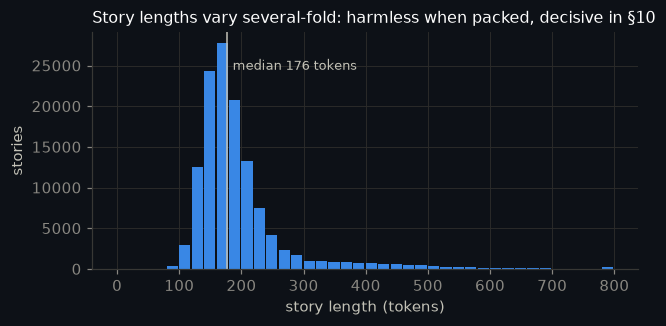

In [14]:
TS_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/"
SMOL_URL = "https://huggingface.co/HuggingFaceTB/SmolLM2-135M/resolve/main/"
TRAIN_MB = {"quick": 5, "full": 100}.get(MODE)
VALID_MB = {"quick": 2, "full": 22}.get(MODE)


def fetch(url, dest, max_bytes=None, tries=12):
    """Resumable download with HTTP Range requests; keeps only the first max_bytes if given."""
    dest = Path(dest)
    if dest.exists():
        return dest
    part = dest.with_name(dest.name + ".part")
    t0, expected = time.time(), None
    for attempt in range(tries):
        have = part.stat().st_size if part.exists() else 0
        if expected is not None and have >= expected:
            break
        rng = f"bytes={have}-" + (str(max_bytes - 1) if max_bytes else "")
        req = urllib.request.Request(url, headers={"Range": rng, "User-Agent": "training-loop-notebook"})
        try:
            with urllib.request.urlopen(req, timeout=60) as r:
                if r.status == 200 and have:                  # server ignored the range: start over
                    part.unlink(); have = 0
                cr = r.headers.get("Content-Range")
                total = int(cr.split("/")[-1]) if cr and "/" in cr else have + int(r.headers.get("Content-Length", 0))
                expected = min(total, max_bytes) if max_bytes else total
                with open(part, "ab") as f:
                    while f.tell() < expected:
                        chunk = r.read(1 << 20)
                        if not chunk:
                            break
                        f.write(chunk)
            if part.stat().st_size >= expected:
                break
        except Exception as e:
            print(f"  download interrupted ({type(e).__name__}: {e}); resuming in a moment")
            time.sleep(min(30, 2 ** attempt))
    else:
        raise RuntimeError(f"could not download {url}")
    if max_bytes and part.stat().st_size > max_bytes:
        with open(part, "r+b") as f:
            f.truncate(max_bytes)
    part.replace(dest)
    print(f"  {dest.name}: {dest.stat().st_size / 2**20:.1f} MiB in {time.time() - t0:.0f}s")
    return dest


def load_tokenizer():
    from tokenizers import Tokenizer
    return Tokenizer.from_file(str(fetch(SMOL_URL + "tokenizer.json", DATA / "smollm2_tokenizer.json")))


def prepare_split(split, mb):
    """Tokenize the first `mb` MB of a TinyStories file into one uint16 stream: EOS s1 EOS s2 EOS ..."""
    out = DATA / f"tinystories_{split}_{mb}MB.npz"
    if out.exists():
        z = np.load(out)
        return {k: z[k] for k in z.files}
    raw = fetch(TS_URL + f"TinyStoriesV2-GPT4-{split}.txt", DATA / f"tinystories_{split}_{mb}MB.txt", max_bytes=mb * 2**20)
    text = raw.read_bytes().decode("utf-8", errors="ignore")
    text = text[: text.rfind("<|endoftext|>")]                 # drop the story the byte limit cut in half
    stories = [s.strip() for s in text.split("<|endoftext|>") if s.strip()]
    pieces = []
    for i in range(0, len(stories), 20000):
        pieces += [np.asarray(e.ids, dtype=np.uint16) for e in TOK.encode_batch_fast(stories[i:i + 20000], add_special_tokens=False)]
    lengths = np.array([len(p) for p in pieces], dtype=np.int64)
    tokens = np.full(int(lengths.sum()) + len(pieces) + 1, EOS, dtype=np.uint16)
    offsets = np.empty(len(pieces), dtype=np.int64)
    pos = 1
    for i, p in enumerate(pieces):
        offsets[i] = pos
        tokens[pos:pos + len(p)] = p
        pos += len(p) + 1
    z = dict(tokens=tokens, offsets=offsets, lengths=lengths, n_chars=np.array(len(text)))
    np.savez(out, **z)
    return z


class PackedLoader:
    """Random T-token windows from the joined stream: every micro-batch has exactly B*T real targets."""

    def __init__(self, split, T, seed):
        self.data, self.T = torch.from_numpy(split["tokens"].astype(np.int32)), T
        self.gen = torch.Generator().manual_seed(seed)

    def micro(self, B):
        i = torch.randint(0, len(self.data) - self.T - 1, (B,), generator=self.gen)
        x = torch.stack([self.data[j:j + self.T] for j in i]).long()
        y = torch.stack([self.data[j + 1:j + 1 + self.T] for j in i]).long()
        return x, y


class StoryLoader:
    """Whole stories grouped into length buckets. A micro-batch holds B stories from one bucket, padded to
    its longest story; padding targets are -100. One global batch = one micro-batch from each bucket, the
    way a length-grouped sampler arranges them, so the micro-batches hold very different token counts."""

    def __init__(self, split, T, n_buckets, seed):
        self.split, self.T = split, T
        order = np.argsort(split["lengths"], kind="stable")
        self.buckets = np.array_split(order, n_buckets)
        self.rng = np.random.default_rng(seed)

    def story(self, i):
        o, n = self.split["offsets"][i], self.split["lengths"][i]
        return torch.from_numpy(self.split["tokens"][o - 1:o + n + 1].astype(np.int64))[: self.T + 1]   # EOS story EOS

    def micro(self, B, bucket):
        seqs = [self.story(i) for i in self.rng.choice(self.buckets[bucket], B, replace=False)]
        L = max(len(s) for s in seqs) - 1
        x = torch.full((B, L), EOS, dtype=torch.long)
        y = torch.full((B, L), -100, dtype=torch.long)
        for r, s in enumerate(seqs):
            x[r, :len(s) - 1], y[r, :len(s) - 1] = s[:-1], s[1:]
        return x, y

    def global_batch(self, B):
        return [self.micro(B, k) for k in range(len(self.buckets))]


TOK = TRAIN = VALID = None
if MODE != "learn":
    TOK = load_tokenizer()
    TRAIN, VALID = prepare_split("train", TRAIN_MB), prepare_split("valid", VALID_MB)
    lens = TRAIN["lengths"]
    R["data_stats"] = _clean(dict(
        train_mb=TRAIN_MB, stories=len(lens), tokens=int(lens.sum()), chars_per_token=float(TRAIN["n_chars"]) / lens.sum(),
        valid_tokens=int(VALID["lengths"].sum()), len_median=float(np.median(lens)), len_p95=float(np.percentile(lens, 95)),
        len_max=int(lens.max()), over_512=float((lens + 1 > 512).mean()),
        len_hist=np.histogram(np.minimum(lens, 799), bins=40, range=(0, 800))[0]))
    save_results()
    ids = TOK.encode("Once upon a time, Lily found a red ball.").ids
    print("tokenizer round trip:", ids, "->", repr(TOK.decode(ids)))
    check(TOK.decode(ids) == "Once upon a time, Lily found a red ball.", "the tokenizer round-trips text exactly")
    check(TOK.token_to_id("<|endoftext|>") == EOS, "<|endoftext|> is token id 0")

ds = R.get("data_stats")
if ds:
    print(f"train slice: {ds['train_mb']} MB -> {ds['stories']:,} stories, {ds['tokens']:,} tokens "
          f"({ds['chars_per_token']:.2f} characters per token);  held-out: {ds['valid_tokens']:,} tokens")
    print(f"story length in tokens: median {ds['len_median']:.0f}, 95th percentile {ds['len_p95']:.0f}, "
          f"max {ds['len_max']}; {100 * ds['over_512']:.2f}% are truncated at 512")
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    edges = np.linspace(0, 800, 41)
    ax.bar(edges[:-1], ds["len_hist"], width=18, align="edge", color=C["blue"])
    ax.axvline(ds["len_median"], color=INK2, lw=1)
    label_end(ax, ds["len_median"], max(ds["len_hist"]) * 0.9, f"median {ds['len_median']:.0f} tokens")
    ax.set_xlabel("story length (tokens)"); ax.set_ylabel("stories")
    ax.set_title("Story lengths vary several-fold: harmless when packed, decisive in §10")
    finish(fig, "story_lengths")

**First sanity check: the loss at initialization.** A freshly initialized model knows nothing, so it should spread its probability evenly over all $V$ tokens. The cross-entropy of a uniform guess is
$$
\mathcal{L}_0 = -\log\tfrac{1}{V} = \ln V = \ln 49152 \approx 10.80
$$
If the first loss you print is far from $\ln V$, something is wrong before training has even started. Common causes: initialization too large, labels shifted the wrong way, or the loss averaged over padding.

In [15]:
m0 = make_model("A" if DEV == "cuda" else "tiny", device=DEV)
gx = torch.Generator().manual_seed(0)
xb = torch.randint(0, 49152, (4, 128), generator=gx).to(DEV)
with torch.no_grad():
    l0 = m0(xb[:, :-1], xb[:, 1:]).item()
print(f"loss at initialization: {l0:.4f}    ln V = {math.log(49152):.4f}")
check(abs(l0 - math.log(49152)) < 0.15, "initial loss is ln(V): the untrained model guesses uniformly")
del m0; free_gpu()

loss at initialization: 10.8669    ln V = 10.8027
✓ initial loss is ln(V): the untrained model guesses uniformly


> **Carry forward:** know the number your loss *must* start at ($\ln V$) and the shape every tensor *must* have before you trust anything the loop prints.

## 6. Every tensor in one step

**The rule:** print every tensor shape in the step, and say in one line what each dimension means. The names first:

| Symbol | Meaning | Model A | SmolLM2-135M |
|---|---|---|---|
| $B$ | sequences in the micro-batch (independent rows, processed in parallel) | 8 | 4 |
| $T$ | positions per sequence (tokens of context) | 512 | 512 |
| $C$ | width of the residual stream (numbers per token, per layer) | 384 | 576 |
| $H$ | query heads (independent attention patterns) | 6 | 9 |
| $H_{kv}$ | key/value heads (each shared by $H/H_{kv}$ query heads) | 2 | 3 |
| $D_h$ | width of one head ($C/H$) | 64 | 64 |
| $F$ | hidden width of the MLP | 1024 | 1536 |
| $V$ | vocabulary size (one score per possible next token) | 49,152 | 49,152 |

Below, forward hooks on every module record every output, and `rec()` calls inside the attention record the tensors that are not module outputs (q, k, v and the attention result). Only layer 0 is listed in full; the other layers repeat it exactly.

In [16]:
MEANING = {
    "input ids": "B×T integers: the token id at every position of every sequence",
    "targets": "B×T integers: the same stream shifted left by one (the next token at each position)",
    "embed_tokens": "one C-wide vector per token: a row lookup, no arithmetic",
    "input_layernorm": "same shape, each token rescaled to unit RMS",
    "q (heads split)": "C split into H heads of D_h: one query per head, per position",
    "k (heads split)": "only H_kv key heads: GQA stores fewer keys",
    "v (heads split)": "only H_kv value heads",
    "k,v (shared to every query head)": "each K/V head copied to the H/H_kv query heads that share it",
    "scores QKᵀ/√D_h": "a T×T table per head: how much each position attends to each earlier one",
    "attention output": "per head, a weighted mix of the values",
    "q_proj": "C → H·D_h query channels (heads not yet split)",
    "k_proj": "C → H_kv·D_h key channels",
    "v_proj": "C → H_kv·D_h value channels",
    "o_proj": "heads concatenated back to C, then mixed",
    "post_attention_layernorm": "residual stream rescaled again before the MLP",
    "gate_proj": "expanded to the MLP width F",
    "up_proj": "a second F-wide projection, the one that gets gated",
    "SiLU(gate)·up": "the gate decides how much of each of the F channels passes",
    "down_proj": "contracted back to C, added to the residual stream",
    "norm": "final RMSNorm of the residual stream",
    "lm_head": "a score for every vocabulary entry, at every position (= logits)",
    "logits": "B×T×V: the biggest tensor in the step",
    "loss": "a single number: the mean of B×T per-token losses",
}


def meaning_of(where):
    for key in sorted(MEANING, key=len, reverse=True):
        if where.endswith(key):
            return MEANING[key]
    return ""


def shape_tour(model, x, y, autocast_dtype=None, keep_layers=(0,)):
    """Run one forward with hooks on every leaf module; return rows (where, shape, dtype, bytes, meaning)."""
    REC.rows, hooks = [("input ids", tuple(x.shape), str(x.dtype).replace("torch.", "")),
                       ("targets", tuple(y.shape), str(y.dtype).replace("torch.", ""))], []
    for name, mod in model.named_modules():
        if name and not list(mod.children()) and not isinstance(mod, nn.Dropout):
            hooks.append(mod.register_forward_hook(lambda m, i, o, n=name: rec(n, o)))
    REC.on = True
    try:
        if autocast_dtype is not None:
            ctx = torch.autocast(x.device.type, dtype=autocast_dtype)
        else:
            ctx = torch.autocast("cpu", enabled=False)
        with ctx, torch.no_grad():          # no graph: a kept loss must not pin every activation in memory
            loss = model(x, y)
    finally:
        REC.on = False
        for h in hooks:
            h.remove()
    rows, skipped = [], set()
    size = {"float32": 4, "float64": 8, "bfloat16": 2, "float16": 2, "int64": 8, "int32": 4}
    for where, shape, dt in REC.rows:
        m = re.match(r"layers\.(\d+)\.", where)
        if m and int(m.group(1)) not in keep_layers:
            skipped.add(int(m.group(1)))
            continue
        n_bytes = math.prod(shape) * size.get(dt, 4) if shape else size.get(dt, 4)
        rows.append((where, "×".join(map(str, shape)) or "() scalar", dt, n_bytes, meaning_of(where)))
    return loss, rows, sorted(skipped)


def fmt_bytes(n):
    for unit in ("B", "KiB", "MiB", "GiB"):
        if n < 1024 or unit == "GiB":
            return f"{n:.0f} {unit}" if unit == "B" else f"{n:.1f} {unit}"
        n /= 1024


def show_tour(rows, skipped):
    show(md_table([(w, s, d, fmt_bytes(b), m) for w, s, d, b, m in rows],
                  ["tensor", "shape", "dtype", "size", "what the dimensions mean"]))
    if skipped:
        print(f"(layers {skipped[0]}–{skipped[-1]} produce exactly the same shapes as layer 0 and are not repeated)")


tour_dev = DEV if DEV == "cuda" else "meta"          # on a CPU-only machine shapes come from a meta-device build
B6, T6 = (4, 128) if (MODE == "quick" and tour_dev != "meta") else (8, 512)
if tour_dev == "meta":
    with torch.device("meta"):
        mA = LM(CFG["A"])
else:
    mA = make_model("A")
xg = torch.randint(0, 49152, (B6, T6 + 1), device=tour_dev)
lossA, rowsA, skippedA = shape_tour(mA, xg[:, :-1], xg[:, 1:])
print(f"Model A, one micro-batch of B={B6} sequences x T={T6} positions "
      "(fp32 here; under bf16 autocast the matmul outputs become bfloat16):")
show_tour(rowsA, skippedA)
if MODE != "learn":
    R["tour_A"] = dict(B=B6, T=T6, rows=rowsA, skipped=[skippedA[0], skippedA[-1]] if skippedA else [])
biggest = max(rowsA, key=lambda r: r[3])
check(biggest[0] in ("logits", "lm_head"), f"the largest activation is the logits, B×T×V = {biggest[1]} ({fmt_bytes(biggest[3])})")
check(lossA.dim() == 0, "the loss is a 0-dimensional tensor: one number")

Model A, one micro-batch of B=8 sequences x T=512 positions (fp32 here; under bf16 autocast the matmul outputs become bfloat16):


| tensor | shape | dtype | size | what the dimensions mean |
|---|---|---|---|---|
| input ids | 8×512 | int64 | 32.0 KiB | B×T integers: the token id at every position of every sequence |
| targets | 8×512 | int64 | 32.0 KiB | B×T integers: the same stream shifted left by one (the next token at each position) |
| embed_tokens | 8×512×384 | float32 | 6.0 MiB | one C-wide vector per token: a row lookup, no arithmetic |
| layers.0.input_layernorm | 8×512×384 | float32 | 6.0 MiB | same shape, each token rescaled to unit RMS |
| layers.0.self_attn.q_proj | 8×512×384 | float32 | 6.0 MiB | C → H·D_h query channels (heads not yet split) |
| layers.0.self_attn.k_proj | 8×512×128 | float32 | 2.0 MiB | C → H_kv·D_h key channels |
| layers.0.self_attn.v_proj | 8×512×128 | float32 | 2.0 MiB | C → H_kv·D_h value channels |
| layers.0.self_attn.q (heads split) | 8×6×512×64 | float32 | 6.0 MiB | C split into H heads of D_h: one query per head, per position |
| layers.0.self_attn.k (heads split) | 8×2×512×64 | float32 | 2.0 MiB | only H_kv key heads: GQA stores fewer keys |
| layers.0.self_attn.v (heads split) | 8×2×512×64 | float32 | 2.0 MiB | only H_kv value heads |
| layers.0.self_attn.k,v (shared to every query head) | 8×6×512×64 | float32 | 6.0 MiB | each K/V head copied to the H/H_kv query heads that share it |
| layers.0.self_attn.attention output | 8×6×512×64 | float32 | 6.0 MiB | per head, a weighted mix of the values |
| layers.0.self_attn.o_proj | 8×512×384 | float32 | 6.0 MiB | heads concatenated back to C, then mixed |
| layers.0.post_attention_layernorm | 8×512×384 | float32 | 6.0 MiB | residual stream rescaled again before the MLP |
| layers.0.mlp.gate_proj | 8×512×1024 | float32 | 16.0 MiB | expanded to the MLP width F |
| layers.0.mlp.up_proj | 8×512×1024 | float32 | 16.0 MiB | a second F-wide projection, the one that gets gated |
| layers.0.mlp.SiLU(gate)·up | 8×512×1024 | float32 | 16.0 MiB | the gate decides how much of each of the F channels passes |
| layers.0.mlp.down_proj | 8×512×384 | float32 | 6.0 MiB | contracted back to C, added to the residual stream |
| norm | 8×512×384 | float32 | 6.0 MiB | final RMSNorm of the residual stream |
| lm_head | 8×512×49152 | float32 | 768.0 MiB | a score for every vocabulary entry, at every position (= logits) |
| logits | 8×512×49152 | float32 | 768.0 MiB | B×T×V: the biggest tensor in the step |
| loss | () scalar | float32 | 4 B | a single number: the mean of B×T per-token losses |

(layers 1–7 produce exactly the same shapes as layer 0 and are not repeated)
✓ the largest activation is the logits, B×T×V = 8×512×49152 (768.0 MiB)
✓ the loss is a 0-dimensional tensor: one number


Two things stand out. The **logits** dwarf everything else: $B \cdot T \cdot V$ = 8 × 512 × 49,152 ≈ 201M numbers, 805 MB in fp32. That is more than all of Model A's weights, gradients and optimizer state together. And attention never materializes a $T\times T$ score table here, because the fused kernel (`scaled_dot_product_attention`) computes it in tiles. With `attn="manual"` it would appear as a $B\times H\times T\times T$ tensor.

### The other tensors of a step: weights, gradients, optimizer state

A step does not only create activations. It also needs a **gradient** for every weight, with the same shape, and the AdamW optimizer keeps **two running averages** per weight (`exp_avg` and `exp_avg_sq`, §18), again the same shape. We run one real backward pass and one optimizer step, then compare.

In [17]:
if tour_dev != "meta":
    xs, ys = xg[:2, :65], xg[:2, 1:66]
    mA.zero_grad(set_to_none=True)
    mA(xs, ys).backward()
    optA = torch.optim.AdamW(mA.parameters(), lr=1e-4)
    optA.step()
    prow, totals = [], dict(p=0, g=0, m=0, v=0)
    for name, p in mA.named_parameters():
        st = optA.state[p]
        totals["p"] += p.numel(); totals["g"] += p.grad.numel()
        totals["m"] += st["exp_avg"].numel(); totals["v"] += st["exp_avg_sq"].numel()
        if name.startswith("layers.") and not name.startswith("layers.0."):
            continue
        prow.append((name, "×".join(map(str, p.shape)), "×".join(map(str, p.grad.shape)),
                     "×".join(map(str, st["exp_avg"].shape)), f"{p.numel():,}", "yes" if p.requires_grad else "no"))
    show(md_table(prow, ["parameter", "weight", "gradient (.grad)", "AdamW exp_avg / exp_avg_sq", "numbers", "trainable"]))
    print("(layers 1–7 repeat layer 0)")
    check(all(r[1] == r[2] == r[3] for r in prow), "every gradient and every optimizer state has exactly its weight's shape")
    check(totals["p"] == totals["g"] == totals["m"] == totals["v"] == n_params_formula(CFG["A"]),
          f"{totals['p']:,} weights -> {totals['g']:,} gradients + 2 x {totals['m']:,} optimizer numbers")
    check("lm_head.weight" not in dict(mA.named_parameters()), "the tied head is not a separate parameter: one matrix, one gradient")
    # Freezing: a weight with requires_grad=False gets no gradient, so it costs no gradient memory and no optimizer state.
    mA.embed_tokens.weight.requires_grad_(False)
    mA.zero_grad(set_to_none=True)
    mA(xs, ys).backward()
    frozen = sum(p.numel() for p in mA.parameters() if not p.requires_grad)
    check(mA.embed_tokens.weight.grad is None and mA.layers[0].mlp.up_proj.weight.grad is not None,
          f"freezing the embedding (and with it the tied head): {frozen:,} weights get no gradient, saving "
          f"{frozen * 12 / 2**20:.0f} MiB of gradient + AdamW state while the other layers still train")
    mA.embed_tokens.weight.requires_grad_(True)
    del optA
del mA; free_gpu()

| parameter | weight | gradient (.grad) | AdamW exp_avg / exp_avg_sq | numbers | trainable |
|---|---|---|---|---|---|
| embed_tokens.weight | 49152×384 | 49152×384 | 49152×384 | 18,874,368 | yes |
| layers.0.input_layernorm.weight | 384 | 384 | 384 | 384 | yes |
| layers.0.self_attn.q_proj.weight | 384×384 | 384×384 | 384×384 | 147,456 | yes |
| layers.0.self_attn.k_proj.weight | 128×384 | 128×384 | 128×384 | 49,152 | yes |
| layers.0.self_attn.v_proj.weight | 128×384 | 128×384 | 128×384 | 49,152 | yes |
| layers.0.self_attn.o_proj.weight | 384×384 | 384×384 | 384×384 | 147,456 | yes |
| layers.0.post_attention_layernorm.weight | 384 | 384 | 384 | 384 | yes |
| layers.0.mlp.gate_proj.weight | 1024×384 | 1024×384 | 1024×384 | 393,216 | yes |
| layers.0.mlp.up_proj.weight | 1024×384 | 1024×384 | 1024×384 | 393,216 | yes |
| layers.0.mlp.down_proj.weight | 384×1024 | 384×1024 | 384×1024 | 393,216 | yes |
| norm.weight | 384 | 384 | 384 | 384 | yes |

(layers 1–7 repeat layer 0)
✓ every gradient and every optimizer state has exactly its weight's shape
✓ 31,463,808 weights -> 31,463,808 gradients + 2 x 31,463,808 optimizer numbers
✓ the tied head is not a separate parameter: one matrix, one gradient
✓ freezing the embedding (and with it the tied head): 18,874,368 weights get no gradient, saving 216 MiB of gradient + AdamW state while the other layers still train


### The same tour on a real pretrained model

Now the real thing: SmolLM2-135M's published weights, loaded into the same `LM` class. The weight file uses the same names as our modules (`model.layers.0.self_attn.q_proj.weight` and so on), stores them in bf16, and has **no `lm_head`**, because the head is tied to the embedding.

Loading weights is where one of the quietest failures in training lives (§22). A checkpoint that does not quite match the model can load "successfully" and leave some weights at their random initial values. So the loader below **refuses** to continue unless every tensor in the file found a parameter, every parameter was filled, and every shape matched. Then it proves the weights are real: a random model scores $\ln V \approx 10.8$ on held-out stories, a trained one far lower.

The safetensors format is simple enough to read by hand: an 8-byte header length, a JSON header giving each tensor's dtype, shape and byte range, then the raw bytes.

In [18]:
def read_safetensors(path):
    with open(path, "rb") as f:
        n = struct.unpack("<Q", f.read(8))[0]
        header = json.loads(f.read(n))
        blob = f.read()
    dtypes = {"BF16": torch.bfloat16, "F16": torch.float16, "F32": torch.float32}
    out = {}
    for k, meta in header.items():
        if k == "__metadata__":
            continue
        s, e = meta["data_offsets"]
        out[k] = torch.frombuffer(bytearray(blob[s:e]), dtype=dtypes[meta["dtype"]]).view(meta["shape"])
    return out


SMOL_SD = None


def load_smollm2(device=None, dtype=torch.float32, verbose=False):
    global SMOL_SD
    if SMOL_SD is None:
        SMOL_SD = read_safetensors(fetch(SMOL_URL + "model.safetensors", DATA / "smollm2_135m.safetensors"))
    model = make_model("smollm2_135m", device="cpu")
    own = model.state_dict()
    mapped = {k.removeprefix("model."): v for k, v in SMOL_SD.items()}
    missing = [k for k in own if k not in mapped and k != "lm_head.weight"]
    unexpected = [k for k in mapped if k not in own]
    bad_shape = [k for k in mapped if k in own and own[k].shape != mapped[k].shape]
    assert not (missing or unexpected or bad_shape), (missing[:3], unexpected[:3], bad_shape[:3])
    with torch.no_grad():
        for k, v in mapped.items():
            own[k].copy_(v.to(torch.float32))
    if verbose:
        check(True, f"all {len(SMOL_SD)} tensors in the file matched a parameter by name and shape; none missing, none left over")
        check(model.lm_head.weight.data_ptr() == model.embed_tokens.weight.data_ptr(), "output head shares the embedding matrix")
    return model.to(device or DEV, dtype)


def val_windows(T, B, n, seed=1234):
    ld = PackedLoader(VALID, T, seed)
    return [ld.micro(B) for _ in range(n)]


def autocast_ctx(precision, device_type=None):
    device_type = device_type or ("cuda" if DEV == "cuda" else "cpu")
    if precision in ("bf16", "fp16", "fp16_noscale"):
        return torch.autocast(device_type, dtype=torch.bfloat16 if precision == "bf16" else torch.float16)
    return torch.autocast(device_type, enabled=False)


@torch.no_grad()
def evaluate(model, windows, precision=AMP):
    was = model.training
    model.eval()
    tot, n = 0.0, 0
    for x, y in windows:
        with autocast_ctx(precision):
            tot += model(x.to(DEV), y.to(DEV), reduction="sum").item()
        n += (y != -100).sum().item()
    model.train(was)
    return tot / n


@torch.no_grad()
def generate(model, prompt, n_new=60, temperature=0.0, seed=0):
    """Greedy (temperature 0) or sampled continuation; no KV cache, which is fine for a few dozen tokens."""
    was = model.training
    model.eval()
    g = torch.Generator(device=DEV).manual_seed(seed)
    ids = torch.tensor([[EOS] + TOK.encode(prompt).ids], device=DEV)
    for _ in range(n_new):
        with autocast_ctx(AMP):
            logits = model(ids[:, -512:])[0, -1].float()
        if temperature == 0:
            nxt = logits.argmax()
        else:
            nxt = torch.multinomial(torch.softmax(logits / temperature, -1), 1, generator=g)[0]
        if nxt.item() == EOS:
            break
        ids = torch.cat([ids, nxt.view(1, 1)], dim=1)
    model.train(was)
    return TOK.decode(ids[0, 1:].tolist())


def smol_tour():
    model = load_smollm2(verbose=True)
    loss_real = evaluate(model, val_windows(256, 4, 5))
    sample = generate(model, "Once upon a time, there was a little cat named", n_new=40)
    x = torch.from_numpy(VALID["tokens"][:65].astype(np.int64)).view(1, 65).to(DEV)
    _, rows, skipped = shape_tour(model, x[:, :-1], x[:, 1:], autocast_dtype=torch.bfloat16 if AMP == "bf16" else None)
    out = dict(loss=loss_real, sample=sample, rows=rows, skipped=[skipped[0], skipped[-1]] if skipped else [],
               n_tensors=len(SMOL_SD), n_params=sum(p.numel() for p in model.parameters()))
    del model; free_gpu()
    return out


smol = experiment("smollm2_tour", smol_tour, needs_gpu=True)
if smol:
    print(f"SmolLM2-135M: {smol['n_params']:,} parameters from {smol['n_tensors']} tensors")
    print(f"held-out loss on TinyStories: {smol['loss']:.3f} nats/token (a random model scores ln V = 10.80)")
    print(f"greedy continuation: {smol['sample']!r}\n")
    print("Shapes for one sequence of 64 tokens (B=1, T=64) under autocast:")
    show_tour([tuple(r) for r in smol["rows"]], smol["skipped"])
    check(smol["loss"] < 3.0, "pretrained weights really loaded: held-out loss is far below ln V")

[smollm2_tour] reusing the result stored earlier (FORCE=1 redoes it)
SmolLM2-135M: 134,515,008 parameters from 272 tensors
held-out loss on TinyStories: 2.131 nats/token (a random model scores ln V = 10.80)
greedy continuation: 'Once upon a time, there was a little cat named Max who loved to play with his friends in the park. They would run around, jump, and chase each other. But sometimes, Max would get frustrated and stop playing. He would stop playing because'

Shapes for one sequence of 64 tokens (B=1, T=64) under autocast:


| tensor | shape | dtype | size | what the dimensions mean |
|---|---|---|---|---|
| input ids | 1×64 | int64 | 512 B | B×T integers: the token id at every position of every sequence |
| targets | 1×64 | int64 | 512 B | B×T integers: the same stream shifted left by one (the next token at each position) |
| embed_tokens | 1×64×576 | float32 | 144.0 KiB | one C-wide vector per token: a row lookup, no arithmetic |
| layers.0.input_layernorm | 1×64×576 | float32 | 144.0 KiB | same shape, each token rescaled to unit RMS |
| layers.0.self_attn.q_proj | 1×64×576 | bfloat16 | 72.0 KiB | C → H·D_h query channels (heads not yet split) |
| layers.0.self_attn.k_proj | 1×64×192 | bfloat16 | 24.0 KiB | C → H_kv·D_h key channels |
| layers.0.self_attn.v_proj | 1×64×192 | bfloat16 | 24.0 KiB | C → H_kv·D_h value channels |
| layers.0.self_attn.q (heads split) | 1×9×64×64 | bfloat16 | 72.0 KiB | C split into H heads of D_h: one query per head, per position |
| layers.0.self_attn.k (heads split) | 1×3×64×64 | bfloat16 | 24.0 KiB | only H_kv key heads: GQA stores fewer keys |
| layers.0.self_attn.v (heads split) | 1×3×64×64 | bfloat16 | 24.0 KiB | only H_kv value heads |
| layers.0.self_attn.k,v (shared to every query head) | 1×9×64×64 | bfloat16 | 72.0 KiB | each K/V head copied to the H/H_kv query heads that share it |
| layers.0.self_attn.attention output | 1×9×64×64 | bfloat16 | 72.0 KiB | per head, a weighted mix of the values |
| layers.0.self_attn.o_proj | 1×64×576 | bfloat16 | 72.0 KiB | heads concatenated back to C, then mixed |
| layers.0.post_attention_layernorm | 1×64×576 | float32 | 144.0 KiB | residual stream rescaled again before the MLP |
| layers.0.mlp.gate_proj | 1×64×1536 | bfloat16 | 192.0 KiB | expanded to the MLP width F |
| layers.0.mlp.up_proj | 1×64×1536 | bfloat16 | 192.0 KiB | a second F-wide projection, the one that gets gated |
| layers.0.mlp.SiLU(gate)·up | 1×64×1536 | bfloat16 | 192.0 KiB | the gate decides how much of each of the F channels passes |
| layers.0.mlp.down_proj | 1×64×576 | bfloat16 | 72.0 KiB | contracted back to C, added to the residual stream |
| norm | 1×64×576 | float32 | 144.0 KiB | final RMSNorm of the residual stream |
| lm_head | 1×64×49152 | bfloat16 | 6.0 MiB | a score for every vocabulary entry, at every position (= logits) |
| logits | 1×64×49152 | bfloat16 | 6.0 MiB | B×T×V: the biggest tensor in the step |
| loss | () scalar | float32 | 4 B | a single number: the mean of B×T per-token losses |

(layers 1–29 produce exactly the same shapes as layer 0 and are not repeated)
✓ pretrained weights really loaded: held-out loss is far below ln V


Under autocast the parameters stay fp32, but every matmul *output* becomes 16-bit, while the RMSNorm reductions and the loss are computed in fp32. The model keeps full-precision master weights and does its heavy arithmetic in 16 bits. §15–§17 explain why that split is the right one.

> **Carry forward:** every tensor in a step has a shape you can predict from $B, T, C, H, H_{kv}, D_h, F, V$. Gradients and optimizer states mirror the weights exactly. The logits ($B\cdot T\cdot V$) are the largest activation of a small LLM.

## 7. One step, start to finish

Everything above assembles into five lines. Every training run in the world is these five lines, repeated until the data or the money runs out:

```python
logits = model(batch)          # forward: tokens -> scores
loss   = loss_fn(logits, y)    # one number
loss.backward()                # fill in every gradient (adds into .grad, §4)
optimizer.step()               # move every weight
optimizer.zero_grad()          # wipe .grad before the next batch
```

The last line surprises people. Because `backward()` **adds** into `.grad`, forgetting to wipe means batch two trains on batch one's gradient plus its own, batch three on all three, and so on. Nothing raises an error. Below we run exactly that mistake next to the correct loop.

The real loop used for every experiment in this notebook adds the instruments a long run needs:

| Instrument | Why |
|---|---|
| **micro-batches with token-weighted accumulation** | the global batch is a choice, independent of memory (§9–§10) |
| **autocast** (bf16, or fp16 + loss scaling on older GPUs) | 16-bit matmuls with fp32 master weights (§15–§17) |
| **gradient norm, every step, before clipping** | the earliest warning a run gives (§11) |
| **clipping at 1.0** | one bad batch cannot throw the weights far (§11) |
| **AdamW** with warmup then cosine decay | the standard recipe; its state costs 8 bytes per weight (§18) |
| **tokens/s, MFU and the GPU clock** | whether the machine is being used, and whether it quietly slowed down (§19–§21) |
| **held-out loss every 100 steps** | the only loss that says whether the model generalizes |
| **stop on a non-finite loss** | a NaN never recovers; continuing only burns compute |

MFU is defined properly in §19. The loop needs the GPU's peak FLOP rate now, so it is computed here.

In [19]:
SPEC_TFLOPS = [   # dense bf16/fp16 tensor-core peak with fp32 accumulation, at boost clock (vendor datasheets)
    ("H100 PCIe", 756), ("H100", 989), ("A100", 312), ("L40S", 362), ("L4", 121), ("A10", 125), ("V100", 125), ("T4", 65),
]


def gemm_tflops(n=4096, dtype=None, iters=30):
    """Measured: the best this GPU does on one big square matmul (a practical ceiling, not a spec)."""
    dtype = dtype or (torch.bfloat16 if AMP == "bf16" else torch.float16)
    a = torch.randn(n, n, device=DEV, dtype=dtype)
    b = torch.randn(n, n, device=DEV, dtype=dtype)
    for _ in range(5):
        a @ b
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(iters):
        a @ b
    torch.cuda.synchronize()
    return 2 * n ** 3 * iters / (time.perf_counter() - t0)


def peak_flops():
    if DEV != "cuda":
        return None, "no GPU"
    p, name = torch.cuda.get_device_properties(0), torch.cuda.get_device_name()
    clk = gpu_clocks().get("sm_max")
    if "GeForce" in name and CAP in ((7, 5), (8, 6), (8, 9)) and clk:
        # GeForce Turing/Ampere/Ada: 512 dense fp16/bf16 FLOP per clock per SM with fp32 accumulation
        return p.multi_processor_count * 512 * clk * 1e6, f"{p.multi_processor_count} SMs x 512 FLOP/clk x {clk:.0f} MHz"
    for key, tf in SPEC_TFLOPS:
        if key in name:
            return tf * 1e12, f"datasheet ({key}: {tf} TFLOPS)"
    return gemm_tflops(), "measured big-matmul ceiling (GPU not in the table)"


PEAK, PEAK_SRC = peak_flops()
if PEAK and MODE != "learn":
    R["peak"] = dict(flops=PEAK, source=PEAK_SRC)        # stored, so a CPU-only replay can still report MFU
if PEAK:
    print(f"peak used for MFU: {PEAK / 1e12:.1f} TFLOPS  [{PEAK_SRC}]")


def flops_per_token(c, T):
    """Training FLOPs per token: 6N for the weights (2 forward + 4 backward) + 12·L·T·C for attention (§19)."""
    return 6 * n_params_formula(c) + 12 * c.n_layer * T * c.d


@contextmanager
def matmul_precision(precision):
    old = torch.backends.cuda.matmul.allow_tf32, torch.backends.cudnn.allow_tf32
    torch.backends.cuda.matmul.allow_tf32 = torch.backends.cudnn.allow_tf32 = precision == "tf32"
    try:
        yield
    finally:
        torch.backends.cuda.matmul.allow_tf32, torch.backends.cudnn.allow_tf32 = old


def qk(full, quick):
    """The full-run value, or a much smaller one in quick mode (learn mode replays the full run, so it gets full values)."""
    return quick if MODE == "quick" else full


@dataclass
class Run:
    cfg: str = MODEL_A
    steps: int = qk(1500, 60)
    micro_bs: int = qk(8, 4)
    accum: int = 4
    T: int = qk(512, 128)
    lr: float = 1e-3
    min_lr_frac: float = 0.1        # cosine decays to this fraction of lr
    warmup: int = qk(100, 10)
    wd: float = 0.1
    clip: float = 1.0               # 0 = never clip (the norm is still measured)
    precision: str = AMP            # "bf16" | "fp16" (with loss scaling) | "fp16_noscale" | "fp32" | "tf32"
    loader: str = "packed"          # "packed" | "stories"
    n_buckets: int = 4
    loss_mode: str = "token"        # "token": sum / all tokens (correct) | "avg_of_avg": mean of micro-batch means
    zero_grad: bool = True
    seed: int = 0                   # model initialization
    data_seed: int = 0              # batch order
    eval_every: int = qk(100, 20)
    eval_batches: int = qk(20, 4)
    lr_ramp: tuple = ()             # (start, end, factor): LR multiplied geometrically up to `factor`
    bad_steps: tuple = ()           # steps whose batch is replaced by random tokens
    init_from: str = ""             # "", "smollm2", or a checkpoint saved earlier
    save_as: str = ""
    log_every: int = qk(100, 20)
    clock_every: int = 50


def lr_at(run, step):
    if step < run.warmup:
        lr = run.lr * (step + 1) / run.warmup
    else:
        prog = (step - run.warmup) / max(1, run.steps - run.warmup)
        lr = run.lr * (run.min_lr_frac + (1 - run.min_lr_frac) * 0.5 * (1 + math.cos(math.pi * prog)))
    if run.lr_ramp:
        s0, s1, fac = run.lr_ramp
        if step >= s0:
            lr *= fac ** ((min(step, s1) - s0) / (s1 - s0))
    return lr


def build_model(run):
    if run.init_from == "smollm2":
        return load_smollm2()
    model = make_model(run.cfg, seed=run.seed)
    if run.init_from:
        model.load_state_dict(torch.load(CKPT / f"{run.init_from}.pt", map_location=DEV))
    return model


def train(run, label=""):
    """The instrumented loop. Returns (history, model)."""
    seed_all(run.seed)
    c = CFG[run.cfg]
    model = build_model(run).train()
    params = list(model.parameters())
    opt = torch.optim.AdamW([{"params": [p for p in params if p.dim() >= 2], "weight_decay": run.wd},
                             {"params": [p for p in params if p.dim() < 2], "weight_decay": 0.0}],
                            lr=run.lr, betas=(0.9, 0.95), fused=DEV == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=run.precision == "fp16" and DEV == "cuda")
    if run.loader == "packed":
        loader = PackedLoader(TRAIN, run.T, seed=run.data_seed)
        next_batch = lambda: [loader.micro(run.micro_bs) for _ in range(run.accum)]
    else:
        loader = StoryLoader(TRAIN, run.T, run.n_buckets, seed=run.data_seed)
        next_batch = lambda: loader.global_batch(run.micro_bs)
    windows = val_windows(run.T, run.micro_bs, run.eval_batches) if run.eval_every else []
    bad_gen = torch.Generator().manual_seed(999 + run.seed)
    H, V = defaultdict(list), dict(step=[], loss=[])
    if DEV == "cuda":
        torch.cuda.reset_peak_memory_stats()
    t_start = time.time()
    with matmul_precision(run.precision):
        for step in range(run.steps):
            lr = lr_at(run, step)
            for g in opt.param_groups:
                g["lr"] = lr
            mbs = next_batch()
            if step in run.bad_steps:      # a corrupted batch: random tokens where there was text
                mbs = [(torch.randint(0, c.vocab, x.shape, generator=bad_gen),
                        torch.where(y == -100, y, torch.randint(0, c.vocab, y.shape, generator=bad_gen))) for x, y in mbs]
            n_k = [int((y != -100).sum()) for _, y in mbs]
            N = sum(n_k)                   # real target tokens in the whole global batch, counted first
            if DEV == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            reported = torch.zeros((), device=DEV)
            true_sum = torch.zeros((), device=DEV)
            flops = 0
            for (x, y), nk in zip(mbs, n_k):
                x, y = x.to(DEV, non_blocking=True), y.to(DEV, non_blocking=True)
                with autocast_ctx(run.precision):
                    if run.loss_mode == "token":          # correct: every token weighs 1/N
                        s = model(x, y, reduction="sum")
                        part = s / N
                        true_sum += s.detach()
                        reported += s.detach() / N
                    else:                                  # the bug: every micro-batch weighs 1/K
                        m = model(x, y)
                        part = m / len(mbs)
                        true_sum += m.detach() * nk
                        reported += m.detach() / len(mbs)
                (scaler.scale(part) if scaler.is_enabled() else part).backward()
                flops += flops_per_token(c, x.shape[1]) * x.numel()
            if scaler.is_enabled():
                scaler.unscale_(opt)
            gnorm = torch.nn.utils.clip_grad_norm_(params, run.clip if run.clip > 0 else float("inf"))
            if scaler.is_enabled():
                scaler.step(opt)
                scaler.update()
            else:
                opt.step()
            if run.zero_grad:
                opt.zero_grad(set_to_none=True)
            loss_v, gn = reported.item(), gnorm.item()    # .item() waits for the GPU: the step is done here
            dt = time.perf_counter() - t0
            H["loss"].append(loss_v); H["true_loss"].append(true_sum.item() / N); H["gnorm"].append(gn)
            H["lr"].append(lr); H["dt"].append(dt); H["tok_s"].append(N / dt)
            H["mfu"].append(flops / dt / PEAK if PEAK else None)
            if run.loader == "stories":
                H["n_k"].append(n_k)
            if scaler.is_enabled():
                H["scale"].append(scaler.get_scale())
            if run.clock_every and DEV == "cuda" and step % run.clock_every == 0:
                H["clock_step"].append(step); H["clock"].append(gpu_clocks().get("sm"))
            if run.eval_every and (step % run.eval_every == 0 or step == run.steps - 1):
                V["step"].append(step); V["loss"].append(evaluate(model, windows, run.precision))
            if not math.isfinite(loss_v) or (not scaler.is_enabled() and not math.isfinite(gn)):
                print(f"  {label}: non-finite at step {step} (loss={loss_v}, grad norm={gn}); stopping")
                H["stopped_at"] = [step]
                break
            if run.log_every and (step % run.log_every == 0 or step == run.steps - 1):
                v = f"  held-out {V['loss'][-1]:.4f}" if V["step"] and V["step"][-1] == step else ""
                print(f"  {label:>16s} step {step:5d}  loss {loss_v:7.4f}  grad-norm {gn:8.3f}  lr {lr:.2e}  {N / dt / 1e3:6.1f}K tok/s{v}")
    out = dict(run=asdict(run), hist=dict(H), val=V, minutes=(time.time() - t_start) / 60,
               peak_mem_gib=torch.cuda.max_memory_allocated() / 2**30 if DEV == "cuda" else None)
    if run.save_as:
        torch.save(model.state_dict(), CKPT / f"{run.save_as}.pt")
    return out, model


def fit_micro_batch(run):
    """Largest micro-batch, halving from the requested one, that survives a full training step (forward, backward
    and the optimizer step that creates AdamW's state); accumulation doubles each time, so the global batch is kept."""
    if DEV != "cuda":
        return run
    mb, acc = run.micro_bs, run.accum
    while mb >= 1:
        m = opt = None
        try:
            free_gpu()
            m = build_model(run)
            opt = torch.optim.AdamW(m.parameters(), lr=0.0, fused=True)
            x, y = PackedLoader(TRAIN, run.T, 0).micro(mb)
            with matmul_precision(run.precision), autocast_ctx(run.precision):
                loss = m(x.to(DEV), y.to(DEV))
            loss.backward()
            opt.step()
            return replace(run, micro_bs=mb, accum=acc)
        except torch.OutOfMemoryError:
            mb, acc = mb // 2, acc * 2
            print(f"  {run.precision}: out of memory, trying micro-batch {mb} x {acc}")
        finally:
            del m, opt
            free_gpu()
    raise RuntimeError("nothing fits")


def arr(y):
    """A list that may hold None (a non-finite value stored as JSON null) -> float array with NaN."""
    return np.array([np.nan if v is None else v for v in y], dtype=float)


def smooth(y, k=25):
    y = np.asarray([np.nan if v is None else v for v in y], dtype=float)
    if len(y) < k:
        return y
    w = np.ones(k) / k
    pad = np.concatenate([np.full(k - 1, y[0]), y])
    return np.convolve(pad, w, mode="valid")

peak used for MFU: 43.0 TFLOPS  [40 SMs x 512 FLOP/clk x 2100 MHz]


### The mistake first: forgetting `zero_grad()`

Two identical runs (same initialization, same batches, no clipping so nothing hides the effect). The only difference is the missing wipe.

[zero_grad_demo] reusing the result stored earlier (FORCE=1 redoes it)


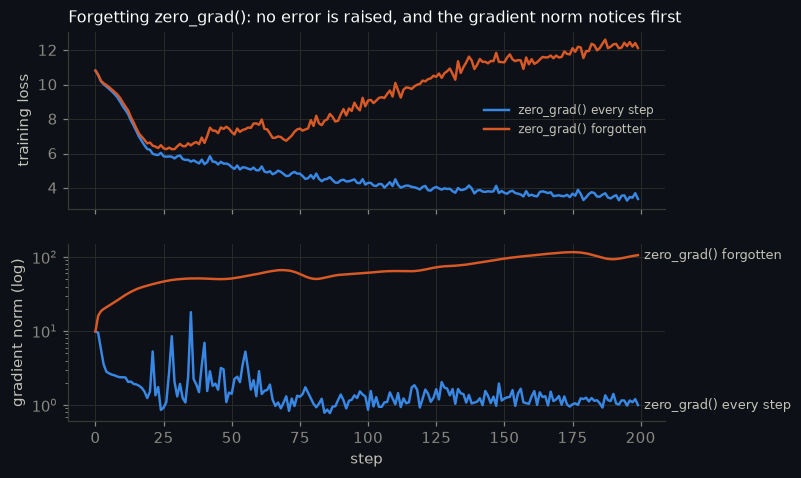

without the wipe the loss kept falling until about step 29 (to 6.25), then rose: final 12.13 vs 3.36 with the wipe
at step 29, while that loss still looked like it was improving, the gradient norm was 49.6 vs 2.06 in the correct run (24x larger)
✓ without zero_grad the stored 'gradient' is a running sum, so its norm keeps growing


In [20]:
def run_zero_grad_demo():
    # No loss scaling here: GradScaler's unscale_() divides everything in .grad by the scale every step, which hides the bug
    prec = "bf16" if CAP >= (8, 0) else "fp32"
    common = dict(steps=qk(200, 30), accum=1, clip=0.0, warmup=qk(20, 5), eval_every=0, log_every=qk(50, 10), min_lr_frac=1.0,
                  precision=prec)
    ok, m = train(Run(**common), "with zero_grad"); del m; free_gpu()
    bad, m = train(Run(**common, zero_grad=False), "without zero_grad"); del m; free_gpu()
    return dict(ok=dict(loss=ok["hist"]["loss"], gnorm=ok["hist"]["gnorm"]),
                bad=dict(loss=bad["hist"]["loss"], gnorm=bad["hist"]["gnorm"]))


zg = experiment("zero_grad_demo", run_zero_grad_demo)
if zg:
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 4.6), sharex=True)
    steps = np.arange(len(zg["ok"]["loss"]))
    for key, col, name in (("ok", C["blue"], "zero_grad() every step"), ("bad", C["orange"], "zero_grad() forgotten")):
        a1.plot(steps, zg[key]["loss"], color=col, label=name)
        a2.semilogy(steps, zg[key]["gnorm"], color=col, label=name)
        label_end(a2, steps[-1], zg[key]["gnorm"][-1], name)
    a1.set_ylabel("training loss"); a2.set_ylabel("gradient norm (log)"); a2.set_xlabel("step")
    a1.set_title("Forgetting zero_grad(): no error is raised, and the gradient norm notices first")
    a1.legend(fontsize=8)
    finish(fig, "zero_grad_demo")
    g_ok, g_bad = zg["ok"]["gnorm"], zg["bad"]["gnorm"]
    l_ok, l_bad = zg["ok"]["loss"], zg["bad"]["loss"]
    t_min = int(np.argmin(smooth(l_bad, 5)))
    print(f"without the wipe the loss kept falling until about step {t_min} (to {min(l_bad):.2f}), "
          f"then {'rose' if l_bad[-1] > min(l_bad) + 0.5 else 'flattened'}: final {l_bad[-1]:.2f} vs {l_ok[-1]:.2f} with the wipe")
    k = min(t_min, len(g_ok) - 1)
    print(f"at step {k}, while that loss still looked like it was improving, the gradient norm was "
          f"{g_bad[k]:.1f} vs {g_ok[k]:.2f} in the correct run ({g_bad[k] / g_ok[k]:.0f}x larger)")
    check(g_bad[-1] > 3 * g_ok[-1], "without zero_grad the stored 'gradient' is a running sum, so its norm keeps growing")

An aside, found while testing this notebook on the fp16 path: with fp16 and a `GradScaler`, this same mistake is almost invisible. `scaler.unscale_()` divides *whatever* is in `.grad` by the loss scale (about 65,536) every step, so the stale running sum is shrunk to nothing before each update. The demo above therefore runs without loss scaling. It is a good example of how two mechanisms can interact so that a bug disappears, until someone switches precision.

Nothing raised an error, and for the first stretch the loss curve looks like a run that is merely a little slower. The gradient norm tells the real story from the first few steps. Without the wipe, `.grad` holds the *sum* of every gradient so far, so its norm grows step after step. AdamW divides each update by its running estimate of that size, which keeps the first steps sane. But the direction it follows is a stale blend of every batch it has ever seen, and once that blend stops pointing downhill the loss turns around. By then the run is wasted. The norm said so long before the loss did.

### The baseline run

Model A, trained from scratch: 8 sequences × 512 tokens per micro-batch, 4 micro-batches per step (16,384 tokens per optimizer step), about 1,500 steps, roughly one pass over the 26M-token slice. Before training, the model babbles. After, it should write something like a story.

[baseline] reusing the result stored earlier (FORCE=1 redoes it)


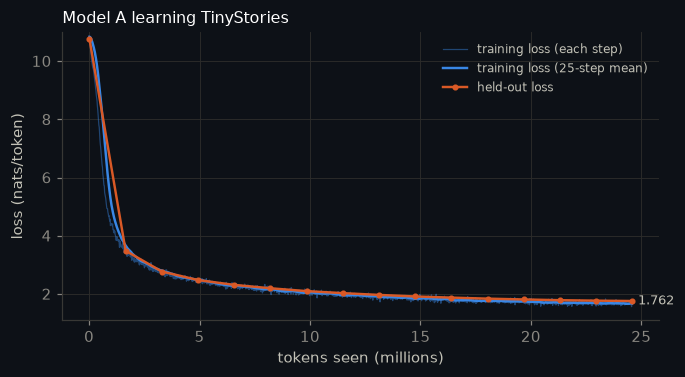

1500 steps, 24.6M tokens in 8.6 min; peak GPU memory 3.48 GiB
held-out loss: 10.768 -> 1.762  (perplexity 5.8: as unsure as a uniform choice among ~6 tokens, down from 49,152)

before training : 'Once upon a time Saturn Bradphas Las cunning NGomp cursesh birds\n                                 wear Fo explanationaretteasciiatteries circulated Can SinceSnfourenh manifest greatly constipation Lic'
after (greedy)  : 'Once upon a time, there was a little boy named Tim. Tim loved to play outside. One day, he saw a big, red ball in the park. He wanted to play with it.\nTim went to the park and saw a girl named Sue. Sue was playing with a ball. Tim asked Sue, "Can I play with you?" Sue said, "Yes, let\'s play!" They played with'
after (sampled) : 'Once upon a time, there was a little girl named Sue. Sue loved to play with her toys. She had a box of toys, and she played with them all day.\nOne day, Sue decided to play with her toys outside. She was having lots of fun. As she played, she saw a 

In [21]:
BASE = Run(save_as="baseline")


def run_baseline():
    m = make_model(BASE.cfg)
    before = generate(m, "Once upon a time", n_new=30, temperature=0.8) if TOK else ""
    del m
    out, model = train(BASE, "baseline")
    out["samples"] = dict(
        before=before,
        greedy=generate(model, "Once upon a time", n_new=80),
        sampled=[generate(model, p, 80, 0.8, seed=i) for i, p in
                 enumerate(["Once upon a time", "Tom and his dog went to", "The little bird was sad because"])])
    del model; free_gpu()
    return out


base = experiment("baseline", run_baseline)
if base:
    h, v = base["hist"], base["val"]
    tokens_per_step = base["run"]["micro_bs"] * base["run"]["accum"] * base["run"]["T"]
    tok = np.arange(1, len(h["loss"]) + 1) * tokens_per_step / 1e6
    fig, ax = plt.subplots(figsize=(7, 3.4))
    ax.plot(tok, h["loss"], color=C["blue"], lw=0.8, alpha=0.45, label="training loss (each step)")
    ax.plot(tok, smooth(h["loss"]), color=C["blue"], label="training loss (25-step mean)")
    ax.plot((np.array(v["step"]) + 1) * tokens_per_step / 1e6, v["loss"], "o-", color=C["orange"], ms=3, label="held-out loss")
    label_end(ax, (v["step"][-1] + 1) * tokens_per_step / 1e6, v["loss"][-1], f"{v['loss'][-1]:.3f}")
    ax.set_xlabel("tokens seen (millions)"); ax.set_ylabel("loss (nats/token)")
    ax.set_ylim(top=min(11, max(v["loss"]) + 0.5))
    ax.set_title("Model A learning TinyStories")
    ax.legend(fontsize=8)
    finish(fig, "baseline_loss")
    print(f"{len(h['loss'])} steps, {tok[-1]:.1f}M tokens in {base['minutes']:.1f} min; peak GPU memory {base['peak_mem_gib'] or 0:.2f} GiB")
    print(f"held-out loss: {v['loss'][0]:.3f} -> {v['loss'][-1]:.3f}  (perplexity {math.exp(v['loss'][-1]):.1f}: "
          f"as unsure as a uniform choice among ~{math.exp(v['loss'][-1]):.0f} tokens, down from 49,152)")
    print("\nbefore training :", repr(base["samples"]["before"][:200]))
    print("after (greedy)  :", repr(base["samples"]["greedy"][:400]))
    for s in base["samples"]["sampled"]:
        print("after (sampled) :", repr(s[:400]))
    check(v["loss"][-1] < v["loss"][0] - 3, "the held-out loss fell by more than 3 nats: the loop learns")

### The same loop fine-tunes real weights

Nothing in `train()` is specific to a model trained from scratch. Pointed at SmolLM2-135M's pretrained weights it fine-tunes them on TinyStories. Only 4 sequences fit per micro-batch here (the $B\cdot T\cdot V$ logits again), so it accumulates 2 micro-batches per step. Note where the loss *starts*: a pretrained model begins near its final loss, not at $\ln V$.

In [22]:
SMOL_FT = Run(cfg="smollm2_135m", init_from="smollm2", steps=qk(200, 10), micro_bs=qk(4, 2), accum=2, lr=1e-4,
              warmup=qk(20, 2), eval_every=qk(50, 5), eval_batches=qk(10, 2), log_every=qk(50, 5))


def run_smol_ft():
    out, model = train(fit_micro_batch(SMOL_FT), "SmolLM2 fine-tune")
    out["sample_after"] = generate(model, "Once upon a time, there was a little cat named", n_new=40)
    del model; free_gpu()
    return out


sft = experiment("smollm2_finetune", run_smol_ft, needs_gpu=True)
if sft:
    v = sft["val"]
    print(f"held-out loss {v['loss'][0]:.3f} -> {v['loss'][-1]:.3f} over {len(sft['hist']['loss'])} steps; "
          f"{np.median(sft['hist']['tok_s']) / 1e3:.1f}K tok/s; peak memory {sft['peak_mem_gib'] or 0:.2f} GiB")
    print("after fine-tuning:", repr(sft["sample_after"]))
    check(v["loss"][-1] <= v["loss"][0] + 0.05, "fine-tuning on in-domain text does not make held-out loss worse")

[smollm2_finetune] reusing the result stored earlier (FORCE=1 redoes it)
held-out loss 2.014 -> 1.541 over 200 steps; 9.4K tok/s; peak memory 5.32 GiB
after fine-tuning: 'Once upon a time, there was a little cat named Kitty. Kitty loved to play with her ball. One day, Kitty saw a big, shiny ball in the park. She wanted to play with it, but she was scared.\n'
✓ fine-tuning on in-domain text does not make held-out loss worse


> **Carry forward:** a step is forward, loss, backward, update, wipe. The wipe is not optional, and a missing one shows up in the gradient norm long before anyone suspects the loss.

---
# Part II: Making the loop tell the truth

## 8. One gradient, checked by hand, on real weights

§2 showed the nudge on a toy. Now the same check on a real transformer: pick a weight, nudge it up and down by $\varepsilon$, run the full model each time, and compare the slope with what `backward()` wrote into `.grad`:

$$
\underbrace{\frac{\mathcal{L}(w + \varepsilon) - \mathcal{L}(w - \varepsilon)}{2\varepsilon}}_{\text{measured}} \;\overset{?}{=}\; \underbrace{\texttt{w.grad}}_{\text{autograd}}
$$

Three choices make the check meaningful rather than noisy, each from §2:

- **float64 everywhere.** That is why the model code never calls `.float()` (it would silently drop fp64 to fp32) and builds its RoPE tables in the activation's dtype.
- **No randomness in the forward pass.** Dropout off (`model.eval()`), and a fixed batch, so the three forward passes compute the same function.
- **A well-conditioned entry.** In each weight matrix we nudge the entry with the largest gradient, so the slope is not lost in roundoff. For the tied embedding we pick a row whose token actually appears in the input. That entry's gradient arrives from two places at once, the lookup at the bottom and the output head at the top.

$\varepsilon = 10^{-5}$ sits at the bottom of fp64's V-shaped error curve for weights of this size.

In [23]:
def grad_check(model, x, y, names, eps=1e-5):
    """Autograd vs central difference for the largest-gradient entry of each named parameter."""
    model.eval()
    model.zero_grad(set_to_none=True)
    model(x, y).backward()
    P, rows = dict(model.named_parameters()), []
    present = torch.unique(x).tolist()
    for name in names:
        p = P[name]
        g = p.grad
        if name == "embed_tokens.weight":       # a row the input really uses: lookup AND head both contribute
            row = max(present, key=lambda t: g[t].abs().max().item())
            idx = (row, int(g[row].abs().argmax()))
        else:
            idx = tuple(int(i) for i in np.unravel_index(int(g.abs().argmax()), tuple(g.shape)))
        auto = g[idx].item()
        with torch.no_grad():
            orig = p[idx].item()
            p[idx] = orig + eps; wp = p[idx].item(); lp = model(x, y).item()
            p[idx] = orig - eps; wm = p[idx].item(); lm = model(x, y).item()
            p[idx] = orig
        num = (lp - lm) / (wp - wm)              # divide by the step actually taken after rounding
        rel = abs(auto - num) / max(abs(auto), abs(num), 1e-300)
        rows.append(dict(param=name, index=list(idx), autograd=auto, numeric=num, rel_err=rel,
                         autograd_s=f"{auto:+.12e}", numeric_s=f"{num:+.12e}",     # strings keep every digit
                         digits=min(16.0, -math.log10(max(rel, 1e-16)))))
    model.zero_grad(set_to_none=True)
    model.train()
    return rows


def check_names(c):
    L = c.n_layer
    return ["embed_tokens.weight", "layers.0.self_attn.q_proj.weight", f"layers.{L // 2}.self_attn.k_proj.weight",
            f"layers.{L // 2}.self_attn.v_proj.weight", f"layers.{L - 1}.self_attn.o_proj.weight",
            "layers.0.mlp.gate_proj.weight", f"layers.{L // 2}.mlp.up_proj.weight", f"layers.{L - 1}.mlp.down_proj.weight",
            f"layers.{L // 2}.input_layernorm.weight", "norm.weight"]


def show_check(rows, title):
    print(title)
    show(md_table([(r["param"], str(tuple(r["index"])), r["autograd_s"], r["numeric_s"],
                    f"{r['rel_err']:.1e}", f"{r['digits']:.1f}") for r in rows],
                  ["parameter", "entry", "autograd (.grad)", "nudge (central difference)", "relative error", "matching digits"]))


# A live check that runs anywhere in seconds: the tiny model, random weights, random tokens, float64.
gdev = DEV if DEV == "cuda" else "cpu"
m_live = make_model("tiny", device=gdev, dtype=torch.float64)
xl = torch.randint(0, 49152, (1, 33), generator=torch.Generator().manual_seed(5)).to(gdev)
live = grad_check(m_live, xl[:, :-1], xl[:, 1:], check_names(CFG["tiny"]))
show_check(live, "Live check: tiny model, random weights, float64")
check(min(r["digits"] for r in live) > 5, f"autograd and the nudge agree on every parameter type (worst: {min(r['digits'] for r in live):.1f} digits)")
del m_live

Live check: tiny model, random weights, float64


| parameter | entry | autograd (.grad) | nudge (central difference) | relative error | matching digits |
|---|---|---|---|---|---|
| embed_tokens.weight | (1032, 110) | +1.643930370591e-01 | +1.643930368722e-01 | 1.1e-09 | 8.9 |
| layers.0.self_attn.q_proj.weight | (45, 45) | +1.068863146751e-03 | +1.068863220155e-03 | 6.9e-08 | 7.2 |
| layers.1.self_attn.k_proj.weight | (33, 20) | +1.099075454723e-03 | +1.099075408462e-03 | 4.2e-08 | 7.4 |
| layers.1.self_attn.v_proj.weight | (6, 26) | +5.902611860923e-02 | +5.902611865949e-02 | 8.5e-10 | 9.1 |
| layers.1.self_attn.o_proj.weight | (10, 10) | +7.894871675297e-02 | +7.894871671965e-02 | 4.2e-10 | 9.4 |
| layers.0.mlp.gate_proj.weight | (46, 31) | +1.357775128608e-02 | +1.357775127886e-02 | 5.3e-10 | 9.3 |
| layers.1.mlp.up_proj.weight | (290, 121) | -1.324873321258e-02 | -1.324873313280e-02 | 6.0e-09 | 8.2 |
| layers.1.mlp.down_proj.weight | (48, 294) | -3.011762985081e-02 | -3.011762998995e-02 | 4.6e-09 | 8.3 |
| layers.1.input_layernorm.weight | (8,) | -5.561072743603e-03 | -5.561072669019e-03 | 1.3e-08 | 7.9 |
| norm.weight | (121,) | -1.166025836784e-02 | -1.166025835885e-02 | 7.7e-10 | 9.1 |

✓ autograd and the nudge agree on every parameter type (worst: 7.2 digits)


Now on weights that have actually learned: Model A after its baseline run, and the real pretrained SmolLM2-135M. Each gets the same ten parameter types, in float64, on one held-out sequence of 64 tokens.

In [24]:
def run_grad_checks():
    out = {}
    x = torch.from_numpy(VALID["tokens"][1000:1065].astype(np.int64)).view(1, 65).to(DEV)
    ck = CKPT / "baseline.pt"
    mA = make_model(MODEL_A, dtype=torch.float64)
    if ck.exists():
        mA.load_state_dict({k: v.double() for k, v in torch.load(ck, map_location=DEV).items()})
    out["A"] = grad_check(mA, x[:, :-1], x[:, 1:], check_names(CFG[MODEL_A]))

    # The same check in fp32, over a range of nudge sizes, for one entry.
    mA32 = mA.float()
    name = "layers.0.mlp.gate_proj.weight"
    out["fp32_sweep"] = [dict(eps=e, **grad_check(mA32, x[:, :-1], x[:, 1:], [name], eps=e)[0]) for e in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5)]

    # When they disagree, on purpose.
    bad = []
    md = make_model(MODEL_A, dtype=torch.float64, dropout=0.1)
    md.load_state_dict(mA.double().state_dict())
    md.train()                                            # dropout ON: every forward draws a new mask
    md.zero_grad(set_to_none=True); md(x[:, :-1], x[:, 1:]).backward()
    p = dict(md.named_parameters())[name]; idx = tuple(int(i) for i in np.unravel_index(int(p.grad.abs().argmax()), tuple(p.shape)))
    auto = p.grad[idx].item()
    with torch.no_grad():
        o = p[idx].item(); p[idx] = o + 1e-5; lp = md(x[:, :-1], x[:, 1:]).item(); p[idx] = o - 1e-5
        lm = md(x[:, :-1], x[:, 1:]).item(); p[idx] = o
    num = (lp - lm) / 2e-5
    bad.append(dict(case="dropout left on (train mode)", autograd=auto, numeric=num, rel_err=abs(auto - num) / abs(auto),
                    why="each forward pass drops a different random set of activations, so the three passes are three different functions"))
    del md
    if DEV == "cuda" and AMP in ("bf16", "fp16"):
        m16 = mA.float()
        m16.eval(); m16.zero_grad(set_to_none=True)
        with autocast_ctx(AMP):
            m16(x[:, :-1], x[:, 1:]).backward()
        p = dict(m16.named_parameters())[name]; idx = tuple(int(i) for i in np.unravel_index(int(p.grad.abs().argmax()), tuple(p.shape)))
        auto = p.grad[idx].item()
        with torch.no_grad(), autocast_ctx(AMP):
            o = p[idx].item(); p[idx] = o + 1e-3; lp = m16(x[:, :-1], x[:, 1:]).item(); p[idx] = o - 1e-3
            lm = m16(x[:, :-1], x[:, 1:]).item(); p[idx] = o
        num = (lp - lm) / 2e-3
        bad.append(dict(case=f"{AMP} autocast, ε=1e-3", autograd=auto, numeric=num, rel_err=abs(auto - num) / abs(auto),
                        why="16-bit matmuls round every activation, so a small nudge is buried under rounding noise"))
        m16.zero_grad(set_to_none=True)
    mA = mA.double()
    r_big = grad_check(mA, x[:, :-1], x[:, 1:], [name], eps=0.5)[0]
    bad.append(dict(case="float64 but ε = 0.5", autograd=r_big["autograd"], numeric=r_big["numeric"], rel_err=r_big["rel_err"],
                    why="the nudge is so large that the loss curves within it: the f'''·ε²/6 truncation term"))
    out["disagree"] = bad
    del mA, mA32; free_gpu()

    ms = load_smollm2(dtype=torch.float64)
    out["smol"] = grad_check(ms, x[:, :-1], x[:, 1:], check_names(CFG["smollm2_135m"]))
    del ms; free_gpu()
    return out


gc_res = experiment("grad_check", run_grad_checks, needs_gpu=True)
if gc_res:
    show_check(gc_res["A"], "Model A after training, float64:")
    show_check(gc_res["smol"], "SmolLM2-135M, pretrained weights, float64:")
    worst = min(r["digits"] for r in gc_res["A"] + gc_res["smol"])
    n_rows = len(gc_res["A"] + gc_res["smol"])
    check(worst > 5, f"all {n_rows} entries agree; the worst matches to {worst:.1f} digits, beyond what fp32 could ever show")
    print("\nThe same entry in fp32, as the nudge size changes:")
    show(md_table([(f"{r['eps']:.0e}", f"{r['autograd']:+.6e}", f"{r['numeric']:+.6e}", f"{r['rel_err']:.1e}")
                   for r in gc_res["fp32_sweep"]], ["ε", "autograd", "nudge", "relative error"]))
    print("When they disagree, and why:")
    show(md_table([(d["case"], f"{d['autograd']:+.4e}", f"{d['numeric']:+.4e}", f"{d['rel_err']:.1e}", d["why"])
                   for d in gc_res["disagree"]], ["setup", "autograd", "nudge", "relative error", "why"]))
    observe(all(d["rel_err"] > 1e-3 for d in gc_res["disagree"]), "every deliberately broken setup visibly disagrees")

[grad_check] reusing the result stored earlier (FORCE=1 redoes it)
Model A after training, float64:


| parameter | entry | autograd (.grad) | nudge (central difference) | relative error | matching digits |
|---|---|---|---|---|---|
| embed_tokens.weight | (650, 159) | -1.706330384675e-01 | -1.706330383878e-01 | 4.7e-10 | 9.3 |
| layers.0.self_attn.q_proj.weight | (320, 151) | +1.351694040602e-02 | +1.351694041141e-02 | 4.0e-10 | 9.4 |
| layers.4.self_attn.k_proj.weight | (82, 214) | -1.615755646390e-02 | -1.615755655937e-02 | 5.9e-09 | 8.2 |
| layers.4.self_attn.v_proj.weight | (20, 377) | +2.577129396013e-02 | +2.577129398773e-02 | 1.1e-09 | 9.0 |
| layers.7.self_attn.o_proj.weight | (127, 75) | +1.891225232469e-02 | +1.891225229755e-02 | 1.4e-09 | 8.8 |
| layers.0.mlp.gate_proj.weight | (704, 77) | +2.897869888850e-02 | +2.897869886276e-02 | 8.9e-10 | 9.1 |
| layers.4.mlp.up_proj.weight | (349, 245) | -9.939396777941e-03 | -9.939396727884e-03 | 5.0e-09 | 8.3 |
| layers.7.mlp.down_proj.weight | (209, 918) | -4.288595461092e-02 | -4.288595460976e-02 | 2.7e-11 | 10.6 |
| layers.4.input_layernorm.weight | (27,) | -6.802888086715e-03 | -6.802888075117e-03 | 1.7e-09 | 8.8 |
| norm.weight | (171,) | -1.535237161853e-02 | -1.535237164053e-02 | 1.4e-09 | 8.8 |

SmolLM2-135M, pretrained weights, float64:


| parameter | entry | autograd (.grad) | nudge (central difference) | relative error | matching digits |
|---|---|---|---|---|---|
| embed_tokens.weight | (650, 17) | +8.120017838607e-01 | +8.120017830790e-01 | 9.6e-10 | 9.0 |
| layers.0.self_attn.q_proj.weight | (539, 471) | -3.362288491322e-03 | -3.362288492067e-03 | 2.2e-10 | 9.7 |
| layers.15.self_attn.k_proj.weight | (122, 247) | +1.182267264327e-01 | +1.182267262755e-01 | 1.3e-09 | 8.9 |
| layers.15.self_attn.v_proj.weight | (71, 507) | +1.872529583904e-01 | +1.872529582280e-01 | 8.7e-10 | 9.1 |
| layers.29.self_attn.o_proj.weight | (299, 242) | -6.027934071664e-03 | -6.027934196242e-03 | 2.1e-08 | 7.7 |
| layers.0.mlp.gate_proj.weight | (371, 260) | +4.634744908862e-02 | +4.634744918965e-02 | 2.2e-09 | 8.7 |
| layers.15.mlp.up_proj.weight | (1184, 247) | -5.614922969251e-02 | -5.614922966579e-02 | 4.8e-10 | 9.3 |
| layers.29.mlp.down_proj.weight | (540, 999) | +1.870405381780e-01 | +1.870405383020e-01 | 6.6e-10 | 9.2 |
| layers.15.input_layernorm.weight | (507,) | +2.578795231609e-01 | +2.578795246453e-01 | 5.8e-09 | 8.2 |
| norm.weight | (17,) | +2.455270606308e-01 | +2.455270606367e-01 | 2.4e-11 | 10.6 |

✓ all 20 entries agree; the worst matches to 7.7 digits, beyond what fp32 could ever show

The same entry in fp32, as the nudge size changes:


| ε | autograd | nudge | relative error |
|---|---|---|---|
| 1e-01 | +2.897860e-02 | +2.895120e-02 | 9.5e-04 |
| 1e-02 | +2.897860e-02 | +2.899170e-02 | 4.5e-04 |
| 1e-03 | +2.897860e-02 | +2.872940e-02 | 8.6e-03 |
| 1e-04 | +2.897860e-02 | +2.622610e-02 | 9.5e-02 |
| 1e-05 | +2.897860e-02 | +4.768110e-02 | 3.9e-01 |

When they disagree, and why:


| setup | autograd | nudge | relative error | why |
|---|---|---|---|---|
| dropout left on (train mode) | +4.5815e-02 | -1.8690e+03 | 4.1e+04 | each forward pass drops a different random set of activations, so the three passes are three different functions |
| bf16 autocast, ε=1e-3 | +2.8809e-02 | +0.0000e+00 | 1.0e+00 | 16-bit matmuls round every activation, so a small nudge is buried under rounding noise |
| float64 but ε = 0.5 | +2.8979e-02 | +2.8216e-02 | 2.6e-02 | the nudge is so large that the loss curves within it: the f'''·ε²/6 truncation term |

✓ every deliberately broken setup visibly disagrees


Agreement to many digits on every kind of parameter (embedding, attention projections, MLP, norm gains, in a trained model and a pretrained one) says the whole chain is right: the model's forward pass, the chain rule through it, and the wiring of the loss. The fp32 sweep shows why fp32 cannot settle the question: the best it manages is a few digits, and only at the right $\varepsilon$.

The disagreements are each worth understanding, because each is a real bug elsewhere:

- **dropout** makes the forward pass random. Anything that recomputes a forward pass (activation checkpointing, reversible layers) must replay *the same* random mask, or its gradients are silently wrong (§22).
- **16-bit autocast** rounds activations, so a gradient check in bf16 checks nothing.
- **a huge ε** measures the average slope over a curved region, not the slope at the point.

> **Carry forward:** when the nudge and `backward()` disagree, you have found something worth understanding. Check in float64, with no randomness, at a sensible ε.

## 9. Gradient accumulation, done right

**Intuition.** A global batch that does not fit is split into $K$ micro-batches that run one after another. Because `backward()` *adds* into `.grad` (§4), running `backward()` on each micro-batch and stepping once at the end produces the gradient of the whole batch, provided each micro-batch's loss is scaled correctly. It is fetching 10 kg of flour as ten 1 kg trips: slower, same flour. And it needs no extra memory: one gradient buffer, however large $K$ is (think of a running sum, 7, then 7+8, then 7+8+9, then 7+8+9+10: one register).

**Math.** Micro-batch $k$ holds $n_k$ real target tokens with losses $\ell_{k,1}, \dots, \ell_{k,n_k}$. With $N = \sum_k n_k$, the loss of the whole global batch is the mean over **all** its tokens:

$$
\mathcal{L} \;=\; \frac{1}{N}\sum_{k=1}^{K}\sum_{i=1}^{n_k} \ell_{k,i}
\;=\; \sum_{k=1}^{K} \frac{n_k}{N}\,\bar{\mathcal{L}}_k,
\qquad \bar{\mathcal{L}}_k = \frac{1}{n_k}\sum_{i} \ell_{k,i}
$$

So the correct recipe is: **count $N$ first**, then for every micro-batch backpropagate $S_k / N$, where $S_k$ is the *sum* of its token losses. The familiar shortcut, backpropagate $\bar{\mathcal{L}}_k / K$, is the same thing only when every $n_k = N/K$.

**Check.** Below, in float64: four micro-batches of very different lengths, accumulated correctly, against the same examples run as one big padded batch.

In [25]:
def synthetic_micro_batches(lengths, B=2, seed=0, vocab=49152):
    """Micro-batches of B sequences each, padded to a common length; real lengths differ per micro-batch."""
    g = torch.Generator().manual_seed(seed)
    mbs = []
    for L in lengths:
        x = torch.randint(0, vocab, (B, L), generator=g)
        y = torch.randint(0, vocab, (B, L), generator=g)
        mbs.append((x, y))
    return mbs


def one_big_batch(mbs):
    Lmax = max(x.shape[1] for x, _ in mbs)
    xs = [F.pad(x, (0, Lmax - x.shape[1]), value=EOS) for x, _ in mbs]
    ys = [F.pad(y, (0, Lmax - y.shape[1]), value=-100) for _, y in mbs]
    return torch.cat(xs), torch.cat(ys)


def grads_of(model, mbs, mode, precision=None):
    """mode: 'big' (one padded batch), 'token' (correct accumulation), 'avg_of_avg' (the bug)."""
    model.zero_grad(set_to_none=True)
    dev = next(model.parameters()).device
    if mode == "big":
        x, y = one_big_batch(mbs)
        model(x.to(dev), y.to(dev)).backward()
    else:
        N = sum(int((y != -100).sum()) for _, y in mbs)
        for x, y in mbs:
            x, y = x.to(dev), y.to(dev)
            loss = model(x, y, reduction="sum") / N if mode == "token" else model(x, y) / len(mbs)
            loss.backward()
    g = torch.cat([p.grad.flatten() for p in model.parameters()]).clone()
    model.zero_grad(set_to_none=True)
    return g


def compare(g, ref):
    return (g - ref).norm().item() / ref.norm().item(), F.cosine_similarity(g, ref, dim=0).item()


m64 = make_model("tiny", device=gdev, dtype=torch.float64)
mbs = synthetic_micro_batches([40, 25, 10, 33])
g_ref, g_acc, g_bug = (grads_of(m64, mbs, m) for m in ("big", "token", "avg_of_avg"))
e_acc, e_bug = compare(g_acc, g_ref)[0], compare(g_bug, g_ref)[0]
print(f"micro-batch lengths 40, 25, 10, 33 (x2 sequences each)")
print(f"correct accumulation vs one big batch : relative difference {e_acc:.1e}")
print(f"average of averages  vs one big batch : relative difference {e_bug:.1e}")
check(e_acc < 1e-12, "token-weighted accumulation reproduces the big-batch gradient to float64 precision")
g_ref_eq = grads_of(m64, synthetic_micro_batches([30, 30, 30, 30]), "big")
g_bug_eq = grads_of(m64, synthetic_micro_batches([30, 30, 30, 30]), "avg_of_avg")
check(compare(g_bug_eq, g_ref_eq)[0] < 1e-12, "with equal micro-batch lengths the shortcut is exact; that is how the bug hid")
del m64

micro-batch lengths 40, 25, 10, 33 (x2 sequences each)
correct accumulation vs one big batch : relative difference 1.9e-15
average of averages  vs one big batch : relative difference 5.9e-01
✓ token-weighted accumulation reproduces the big-batch gradient to float64 precision
✓ with equal micro-batch lengths the shortcut is exact; that is how the bug hid


> **Carry forward:** gradients accumulate, and the loss is normalized by the number of **tokens** in the global batch, not by the number of micro-batches.

## 10. A mistake worth studying: the average of averages

Until 2024, gradient accumulation in the major training frameworks did the shortcut: average each micro-batch's loss over its own tokens, then average those averages. It was found, written up and fixed that year. Take three micro-batches holding different numbers of real tokens, as sequences naturally do:

| Micro-batch | Valid tokens $n_k$ | Average loss $\bar{\mathcal{L}}_k$ |
|---|---|---|
| 1 | 4 | 2.0 |
| 2 | 4 | 2.0 |
| 3 | 2 | 5.0 |

$$
\text{correct: } \frac{4(2.0) + 4(2.0) + 2(5.0)}{4 + 4 + 2} = \frac{26}{10} = 2.6
\qquad
\text{average of averages: } \frac{2.0 + 2.0 + 5.0}{3} = 3.0
$$

The short micro-batch, with half as many tokens, got the same vote as the long ones, and the result is 15.4% too high.

**What the bug really optimizes.** Under the shortcut a token in micro-batch $k$ carries weight $\frac{1}{K n_k}$ instead of $\frac{1}{N}$:

$$
\mathcal{L}_{\text{bug}} = \sum_k \frac{1}{K}\bar{\mathcal{L}}_k = \sum_k \sum_i \underbrace{\frac{1}{K\,n_k}}_{\text{instead of } 1/N}\,\ell_{k,i}
$$

Tokens in short micro-batches are **over-weighted** by $\frac{N}{K n_k}$, and tokens in long ones under-weighted. The two objectives coincide for every possible set of losses exactly when all the $n_k$ are equal, which is what casual tests (and packed batches) produce. That is how it hid: the curves looked plausible while being wrong.

In [26]:
tok_losses = [torch.full((4,), 2.0, dtype=torch.float64), torch.full((4,), 2.0, dtype=torch.float64),
              torch.full((2,), 5.0, dtype=torch.float64)]
correct = torch.cat(tok_losses).mean().item()
avg_avg = torch.stack([t.mean() for t in tok_losses]).mean().item()
print(f"correct {correct:.4f}   average of averages {avg_avg:.4f}   error {100 * (avg_avg - correct) / correct:.1f}%")
check(abs(correct - 2.6) < 1e-12 and abs(avg_avg - 3.0) < 1e-12, "the worked example: 2.6 vs 3.0, 15.4% apart")

correct 2.6000   average of averages 3.0000   error 15.4%
✓ the worked example: 2.6 vs 3.0, 15.4% apart


### The gap, measured on real data

Real stories differ in length, and a length-grouped sampler puts similar lengths together. That is good for padding waste, and maximally bad for this bug. Our `StoryLoader` builds each global batch from four micro-batches, one per length quartile, so $n_k$ ranges from a few hundred to a few thousand tokens.

**First, the gradients themselves.** 50 real global batches, gradients computed three ways on Model A's trained weights, in fp32 with TF32 off: one big padded batch (the definition), correct accumulation, and the average of averages.

[accum_gradients] reusing the result stored earlier (FORCE=1 redoes it)


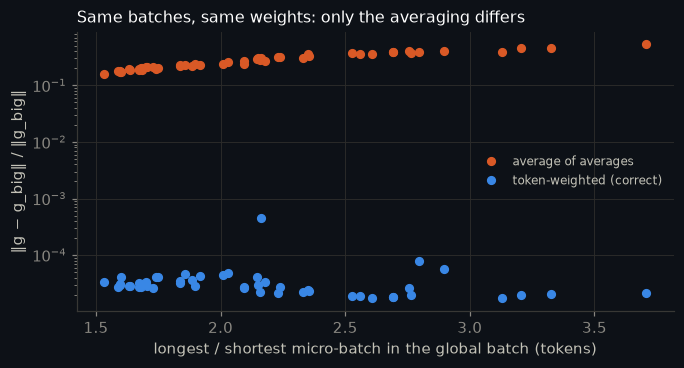

50 global batches; micro-batch token counts ranged 219–942
correct accumulation: median relative error 2.9e-05 (fp32 summation-order noise), cosine 1.0000000
average of averages : median relative error 2.5e-01, cosine 0.9690
✓ the shortcut's gradient is wrong by orders of magnitude more than fp32 noise


In [27]:
def run_accum_gradients():
    ck = CKPT / "baseline.pt"
    m = make_model(MODEL_A)
    if ck.exists():
        m.load_state_dict(torch.load(ck, map_location=DEV))
    loader = StoryLoader(TRAIN, 512, 4, seed=7)        # full-length stories in every mode: truncation equalizes them
    rows = []
    with matmul_precision("fp32"):
        for _ in range(qk(50, 5)):
            mbs = loader.global_batch(2)
            ref = grads_of(m, mbs, "big")
            ok = compare(grads_of(m, mbs, "token"), ref)
            bug = compare(grads_of(m, mbs, "avg_of_avg"), ref)
            rows.append(dict(n_k=[int((y != -100).sum()) for _, y in mbs], ok_err=ok[0], ok_cos=ok[1], bug_err=bug[0], bug_cos=bug[1]))
    del m; free_gpu()
    return rows


acc_g = experiment("accum_gradients", run_accum_gradients)
if acc_g:
    ok_err = np.array([r["ok_err"] for r in acc_g]); bug_err = np.array([r["bug_err"] for r in acc_g])
    ratio = np.array([max(r["n_k"]) / min(r["n_k"]) for r in acc_g])
    fig, ax = plt.subplots(figsize=(7, 3.3))
    ax.semilogy(ratio, bug_err, "o", color=C["orange"], ms=5, label="average of averages")
    ax.semilogy(ratio, ok_err, "o", color=C["blue"], ms=5, label="token-weighted (correct)")
    ax.set_xlabel("longest / shortest micro-batch in the global batch (tokens)")
    ax.set_ylabel("‖g − g_big‖ / ‖g_big‖")
    ax.set_title("Same batches, same weights: only the averaging differs")
    ax.legend(fontsize=8, loc="center right")
    finish(fig, "accum_gradient_error")
    print(f"{len(acc_g)} global batches; micro-batch token counts ranged {min(min(r['n_k']) for r in acc_g)}–"
          f"{max(max(r['n_k']) for r in acc_g)}")
    print(f"correct accumulation: median relative error {np.median(ok_err):.1e} (fp32 summation-order noise), "
          f"cosine {np.median([r['ok_cos'] for r in acc_g]):.7f}")
    print(f"average of averages : median relative error {np.median(bug_err):.1e}, "
          f"cosine {np.median([r['bug_cos'] for r in acc_g]):.4f}")
    check(np.median(bug_err) > 1000 * np.median(ok_err), "the shortcut's gradient is wrong by orders of magnitude more than fp32 noise")

**Then, the training curves.** Two runs from the same initialization see the same batches in the same order. One accumulates correctly, the other averages averages. For the buggy run we also record what its loss *would* have been under the correct formula, on exactly the same batches. That separates "the logged number is wrong" from "the model learned something different".

One pair of runs could be luck, so the pair is repeated with **three seeds**: a different initialization and a different batch order each time. The curves show the first seed; the table and the bottom-right panel show every seed.

[accum_twins_seeds] reusing the result stored earlier (FORCE=1 redoes it)


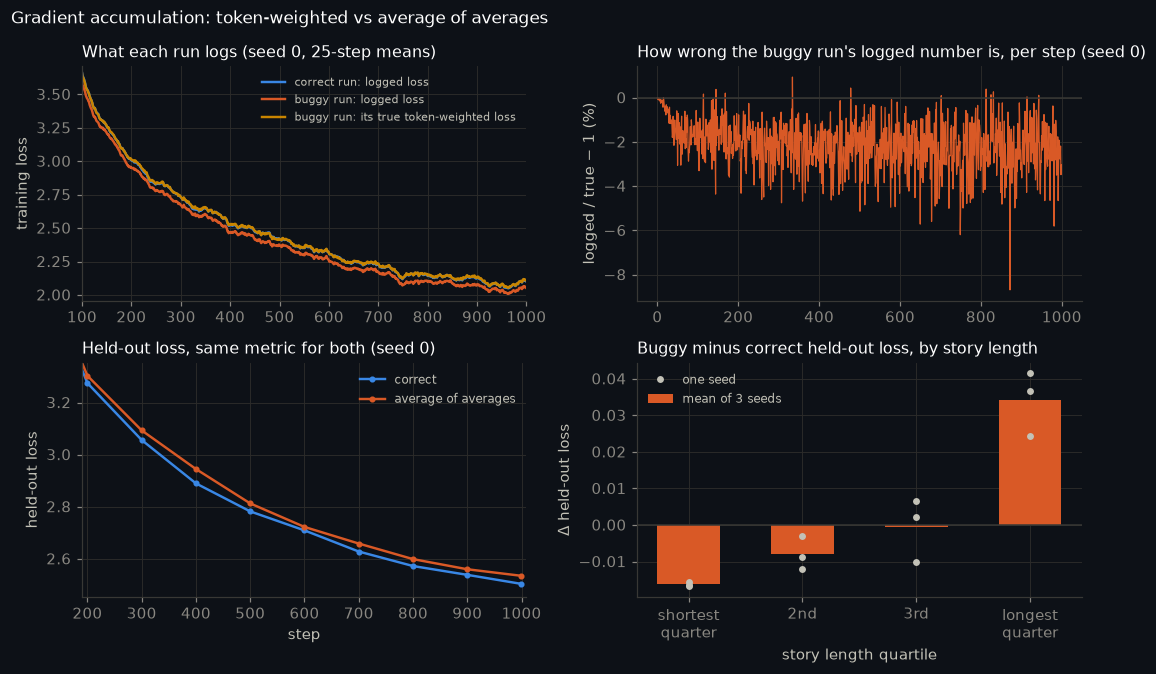

tokens per micro-batch (shortest -> longest quartile), median over steps: [1103, 1327, 1535, 2320]


| seed | logged loss vs its true value (median) | final held-out: correct | final held-out: buggy | buggy − correct | buggy − correct by length quartile (short → long) |
|---|---|---|---|---|---|
| 0 | -2.06% | 2.5039 | 2.5348 | +0.0309 | -0.016, -0.012, -0.010, +0.024 |
| 1 | -2.00% | 2.5403 | 2.5393 | -0.0010 | -0.016, -0.009, +0.002, +0.037 |
| 2 | -2.03% | 2.5079 | 2.5364 | +0.0284 | -0.017, -0.003, +0.007, +0.041 |
| mean ± sd | -2.03 ± 0.03% | 2.5174 ± 0.0199 | 2.5368 ± 0.0023 | +0.0195 ± 0.0178 | -0.016, -0.008, -0.001, +0.034 |

-> the logged number reads low in 3 of 3 seeds: per token, the short stories the bug over-weights have lower loss than the long ones
-> the buggy model ends worse overall in 2 of 3 seeds, and tilted (better on the shortest stories, worse on the longest, as the 1/(K·n_k) weighting predicts) in 3 of 3
✓ in every seed the buggy run's logged loss is off by more than 1%
✓ in every seed the bug tilts the model towards short stories


In [28]:
SEEDS = qk((0, 1, 2), (0, 1))       # every training comparison from here on is repeated over these seeds
ACC = Run(loader="stories", n_buckets=4, T=512, micro_bs=qk(8, 4), steps=qk(1000, 40), lr=1e-3, warmup=qk(50, 5),
          eval_every=qk(100, 10), eval_batches=qk(20, 4), log_every=qk(200, 10))


def bucket_eval(model, n_batches, B):
    """Held-out loss per story-length quartile (token-weighted within each bucket)."""
    ld = StoryLoader(VALID, ACC.T, 4, seed=4321)
    out = []
    for b in range(4):
        out.append(evaluate(model, [ld.micro(B, b) for _ in range(n_batches)]))
    return out


def run_accum_twins():
    res = {}
    for sd in SEEDS:
        res[str(sd)] = {}
        for mode in ("token", "avg_of_avg"):
            out, model = train(replace(ACC, loss_mode=mode, seed=sd, data_seed=sd),
                               f"{'correct' if mode == 'token' else 'avg of avgs'} s{sd}")
            res[str(sd)][mode] = dict(loss=out["hist"]["loss"], true_loss=out["hist"]["true_loss"], n_k=out["hist"]["n_k"],
                                      val=out["val"], bucket_val=bucket_eval(model, qk(20, 2), qk(8, 4)))
            del model; free_gpu()
    return res


def twin_rows(tw):
    """One summary row per seed: logged-loss error, final held-out losses, and the per-quartile difference."""
    rows = []
    for sd in sorted(tw, key=int):
        ok, bug = tw[sd]["token"], tw[sd]["avg_of_avg"]
        gap = 100 * (arr(bug["loss"]) - arr(bug["true_loss"])) / arr(bug["true_loss"])
        rows.append(dict(seed=int(sd), gap=float(np.median(gap)), val_ok=ok["val"]["loss"][-1], val_bug=bug["val"]["loss"][-1],
                         bucket=(np.array(bug["bucket_val"]) - np.array(ok["bucket_val"])).tolist()))
    return rows


def mean_sd(xs, fmt="{:+.4f}"):
    """'mean ± sample standard deviation' (just the mean for a single value)."""
    xs = np.asarray(xs, dtype=float)
    if len(xs) < 2:
        return fmt.format(xs.mean())
    return f"{fmt.format(xs.mean())} ± {fmt.format(xs.std(ddof=1)).lstrip('+')}"


twins = experiment("accum_twins_seeds", run_accum_twins)
if twins:
    seeds_t = sorted(twins, key=int)
    ok, bug = twins[seeds_t[0]]["token"], twins[seeds_t[0]]["avg_of_avg"]
    rows_t = twin_rows(twins)
    steps = np.arange(len(ok["loss"]))
    gap = 100 * (arr(bug["loss"]) - arr(bug["true_loss"])) / arr(bug["true_loss"])
    fig, axs = plt.subplots(2, 2, figsize=(10, 6.2))
    a = axs[0, 0]
    a.plot(steps, smooth(ok["loss"]), color=C["blue"], label="correct run: logged loss")
    a.plot(steps, smooth(bug["loss"]), color=C["orange"], label="buggy run: logged loss")
    a.plot(steps, smooth(bug["true_loss"]), color=C["yellow"], label="buggy run: its true token-weighted loss")
    a.set_title(f"What each run logs (seed {seeds_t[0]}, 25-step means)"); a.set_ylabel("training loss"); a.legend(fontsize=7.5)
    s0 = len(steps) // 10
    lo_ = np.nanmin(smooth(bug["loss"])[s0:]); hi_ = np.nanmax(smooth(bug["true_loss"])[s0:])
    a.set_xlim(s0, len(steps)); a.set_ylim(lo_ - 0.05, hi_ + 0.05)
    a = axs[0, 1]
    a.plot(steps, gap, color=C["orange"], lw=0.8)
    a.axhline(0, color=AXIS, lw=1)
    a.set_title(f"How wrong the buggy run's logged number is, per step (seed {seeds_t[0]})"); a.set_ylabel("logged / true − 1 (%)")
    a = axs[1, 0]
    a.plot(ok["val"]["step"], ok["val"]["loss"], "o-", color=C["blue"], ms=3, label="correct")
    a.plot(bug["val"]["step"], bug["val"]["loss"], "o-", color=C["orange"], ms=3, label="average of averages")
    a.set_title(f"Held-out loss, same metric for both (seed {seeds_t[0]})"); a.set_xlabel("step"); a.set_ylabel("held-out loss")
    k0 = max(1, len(ok["val"]["step"]) // 5)
    a.set_xlim(ok["val"]["step"][k0] - 10, ok["val"]["step"][-1] + 10)
    a.set_ylim(min(ok["val"]["loss"][-1], bug["val"]["loss"][-1]) - 0.05, max(ok["val"]["loss"][k0], bug["val"]["loss"][k0]) + 0.05)
    a.legend(fontsize=8)
    a = axs[1, 1]
    D = np.array([r["bucket"] for r in rows_t])
    xb_ = np.arange(4)
    a.bar(xb_, D.mean(0), width=0.55, color=C["orange"], label=f"mean of {len(D)} seeds")
    for i_, drow in enumerate(D):
        a.plot(xb_, drow, "o", color=INK2, ms=3.5, label="one seed" if i_ == 0 else None)
    a.axhline(0, color=AXIS, lw=1)
    a.set_xticks(xb_, ["shortest\nquarter", "2nd", "3rd", "longest\nquarter"])
    a.set_title("Buggy minus correct held-out loss, by story length"); a.set_xlabel("story length quartile")
    a.set_ylabel("Δ held-out loss"); a.legend(fontsize=8)
    fig.suptitle("Gradient accumulation: token-weighted vs average of averages", color=INK, x=0.01, ha="left", fontsize=11)
    fig.tight_layout()
    finish(fig, "accum_bug")
    nk = np.array(ok["n_k"])
    print(f"tokens per micro-batch (shortest -> longest quartile), median over steps: {np.median(nk, axis=0).astype(int).tolist()}")
    show(md_table([(r["seed"], f"{r['gap']:+.2f}%", f"{r['val_ok']:.4f}", f"{r['val_bug']:.4f}", f"{r['val_bug'] - r['val_ok']:+.4f}",
                    ", ".join(f"{v:+.3f}" for v in r["bucket"])) for r in rows_t] +
                  [("mean ± sd", mean_sd([r["gap"] for r in rows_t], "{:+.2f}") + "%", mean_sd([r["val_ok"] for r in rows_t], "{:.4f}"),
                    mean_sd([r["val_bug"] for r in rows_t], "{:.4f}"), mean_sd([r["val_bug"] - r["val_ok"] for r in rows_t]),
                    ", ".join(f"{v:+.3f}" for v in D.mean(0)))],
                  ["seed", "logged loss vs its true value (median)", "final held-out: correct", "final held-out: buggy",
                   "buggy − correct", "buggy − correct by length quartile (short → long)"]))
    n_ = len(rows_t)
    low = sum(r["gap"] < 0 for r in rows_t)
    tilt = sum(r["bucket"][0] < 0 < r["bucket"][-1] for r in rows_t)
    worse = sum(r["val_bug"] > r["val_ok"] for r in rows_t)
    print(f"-> the logged number reads low in {low} of {n_} seeds: per token, the short stories the bug over-weights have "
          f"{'lower' if low > n_ / 2 else 'higher'} loss than the long ones")
    print(f"-> the buggy model ends worse overall in {worse} of {n_} seeds, and tilted (better on the shortest stories, worse on "
          f"the longest, as the 1/(K·n_k) weighting predicts) in {tilt} of {n_}")
    observe(all(abs(r["gap"]) > 1.0 for r in rows_t), "in every seed the buggy run's logged loss is off by more than 1%")
    observe(tilt == n_, "in every seed the bug tilts the model towards short stories")

How to read the four panels:

- **Top left and top right: the logged number is wrong, every step.** The buggy run reports the average of averages, so the short micro-batches get an inflated vote. Whichever way the short stories' per-token loss differs from the long ones', the logged number is dragged that way. The gap is the bug in its purest form: same model, same batch, two answers.
- **Bottom left and the table: the model.** Whether the *trained model* ends up measurably worse depends on how different the micro-batches are and how long you train. The table gives the honest size of the overall effect next to its seed-to-seed spread: small, and plausible. That is exactly how the bug survived until 2024.
- **Bottom right: where it lands.** The bug re-weights the objective towards short sequences, so its fingerprint is a changed *balance*: better on the short stories it over-weights, worse on the long ones it under-weights. Each dot is one seed, so you can see whether the pattern repeats.

**The fix**, as used in `train()` above:

```python
N = sum((y != -100).sum() for _, y in micro_batches)       # count real tokens first
for x, y in micro_batches:
    loss = model(x, y, reduction="sum") / N                  # each token weighs exactly 1/N
    loss.backward()
```

> **Carry forward:** a number that looks plausible is not evidence. The bug produced believable curves in every major framework for years.

## 11. The gradient norm: does it move before the loss?

**Definition.** Stack every gradient of every parameter into one long vector $g$. Its length is the gradient norm:

$$
\lVert g \rVert = \sqrt{\textstyle\sum_{p}\sum_{j} g_{p,j}^2}
$$

**Clipping** caps that length at $c$ by scaling *every* gradient by the same factor, which changes the length but never the direction:

$$
g \;\leftarrow\; g \cdot \min\!\Big(1, \frac{c}{\lVert g\rVert}\Big)
\qquad\text{e.g. } \lVert g\rVert = 8.4,\ c = 1.0 \;\Rightarrow\; \text{scale by } \tfrac{1.0}{8.4} = 0.119
$$

**Why the norm should move before the loss.** Two reasons, one structural and one statistical. First, near a good region the loss is roughly a bowl: $\mathcal{L} \approx \mathcal{L}^\ast + \tfrac12 \lambda x^2$ along its steepest direction, where $x$ is the distance from the bottom. The gradient there is $\lambda x$. Suppose the learning rate gets too large for that direction. The weights start to overshoot and $x$ grows by a factor $r > 1$ every step. The gradient norm grows like $r^t$ **from its own small baseline**. The loss grows like $r^{2t}$, but on top of a large constant $\mathcal{L}^\ast$ (here, several nats) that hides the change until it is big. In relative terms the norm sees it first. Second, the loss of each step is measured on *different text*, so it jumps around from batch to batch. The norm is a smoother signal, so a real change stands out from its noise sooner. A detector that asks "is this unusual for this trace?" therefore fires on the norm first.

Three experiments, with the detection rule fixed in code **before** any run was looked at:

1. A **robust detector** on the healthy baseline. A trace "moves" at step $t$ when $\log(\text{trace})$ sits more than 4 robust standard deviations (median absolute deviation × 1.4826) above the median of the 50 steps before $t$, for 3 steps in a row.
2. An **instability on purpose**: from the trained model, raise the learning rate geometrically until training breaks, with no clipping, and see which trace the detector flags first. This is repeated over three seeds (batch orders), and once more with clipping on, to measure whether clipping rescues a learning rate that is too high.
3. **What clipping protects against**: three batches of pure noise injected into a healthy run, with and without clipping at 1.0.

In [29]:
DETECT = dict(window=50, z=4.0, consecutive=3)      # fixed before any run was looked at


def first_departure(series, start=None, window=DETECT["window"], z=DETECT["z"], consecutive=DETECT["consecutive"]):
    s = np.log(np.maximum(np.asarray([np.nan if v is None else v for v in series], dtype=float), 1e-12))
    for t in range(max(start or window, window), len(s) - consecutive + 1):
        base = s[t - window:t]
        base = base[np.isfinite(base)]
        if len(base) < window // 2:
            continue
        med = np.median(base)
        mad = 1.4826 * np.median(np.abs(base - med)) + 1e-9
        seg = s[t:t + consecutive]
        if np.all(~np.isfinite(seg) | ((seg - med) / mad > z)):
            return t
    return None


def all_departures(series, start, horizon=None):
    out, t = [], start
    while True:
        e = first_departure(series, start=t)
        if e is None or (horizon and e > horizon):
            return out
        out.append(e)
        t = e + DETECT["window"]


v = np.random.default_rng(0).normal(size=1000)
v_clipped = v * min(1, 1.0 / np.linalg.norm(v))
print(f"a 1000-dim gradient of norm {np.linalg.norm(v):.2f} clipped to {np.linalg.norm(v_clipped):.2f}")
check(abs(np.linalg.norm(v_clipped) - 1) < 1e-12 and abs(np.dot(v, v_clipped) / np.linalg.norm(v) / np.linalg.norm(v_clipped) - 1) < 1e-12,
      "clipping changes the length to exactly c and leaves the direction untouched (cosine = 1)")
print(f"8.4 clipped to 1.0 -> scale factor {1.0 / 8.4:.3f}")

a 1000-dim gradient of norm 30.92 clipped to 1.00
✓ clipping changes the length to exactly c and leaves the direction untouched (cosine = 1)
8.4 clipped to 1.0 -> scale factor 0.119


In [30]:
if base:
    h = base["hist"]
    warm = base["run"]["warmup"] + DETECT["window"]
    ev_norm = all_departures(h["gnorm"], warm)
    ev_loss = all_departures(h["loss"], warm)
    print(f"baseline run, steps {warm}–{len(h['gnorm']) - 1}: the detector flags the grad norm at steps {ev_norm or 'none'} "
          f"and the loss at steps {ev_loss or 'none'}")
    natural = []
    for tn in ev_norm:
        later = [tl for tl in ev_loss if tn <= tl <= tn + 30]
        natural.append(dict(norm_step=tn, loss_step=later[0] if later else None))
    R["natural_events"] = natural
    for e in natural:
        print(f"  norm moved at step {e['norm_step']}; loss " + (f"moved at step {e['loss_step']} (lead {e['loss_step'] - e['norm_step']} steps)"
                                                               if e["loss_step"] is not None else "did not follow within 30 steps"))
    if not natural:
        print("-> no natural event: in this healthy run neither trace ever jumped, so there is no step where the norm moved first. "
              "The lead is measured below, on an instability created on purpose.")
    g = np.array(h["gnorm"][base["run"]["warmup"]:])
    pct = np.percentile(g, [50, 90, 99])
    clipped_frac = float((np.array(h["gnorm"]) > base["run"]["clip"]).mean())
    R["clip_stats"] = dict(p50=pct[0], p90=pct[1], p99=pct[2], max=float(g.max()), clipped_frac=clipped_frac)
    save_results()

baseline run, steps 150–1499: the detector flags the grad norm at steps none and the loss at steps none
-> no natural event: in this healthy run neither trace ever jumped, so there is no step where the norm moved first. The lead is measured below, on an instability created on purpose.


A healthy run may give the detector little to find, and that is a result too. The stress test below creates the event on purpose.

[stress_seeds] reusing the result stored earlier (FORCE=1 redoes it)


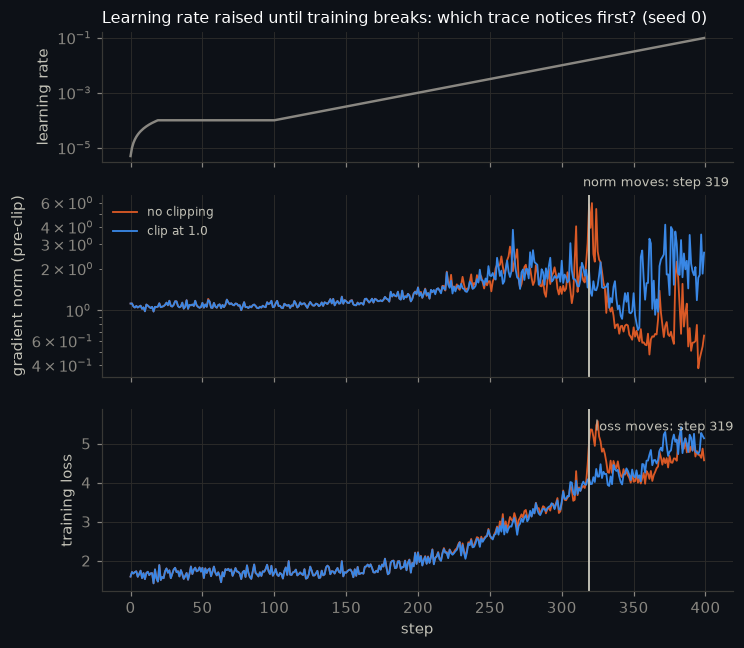

| seed (no clipping) | pre-registered rule: norm departs at step | loss departs at step | lead (steps) |
|---|---|---|---|
| 0 | 319 | 319 | 0 |
| 1 | never | never | — |
| 2 | never | 375 | — |

✗ (as measured) in every seed the pre-registered rule flags the gradient norm first, or only the norm


In [31]:
# Continue from the trained model at the learning rate it finished at (1e-4), so nothing drifts before the ramp.
STRESS = Run(init_from="baseline", steps=qk(400, 40), micro_bs=qk(8, 4), accum=1, lr=1e-4, warmup=qk(20, 4), min_lr_frac=1.0,
             lr_ramp=(qk(100, 10), qk(400, 40), 1000.0), clip=0.0, eval_every=0, log_every=qk(100, 10))


def run_stress():
    res = {"noclip": {}, "clip": {}}
    for sd in SEEDS:
        for key, clip in (("noclip", 0.0), ("clip", 1.0)):
            out, m = train(replace(STRESS, clip=clip, seed=sd, data_seed=sd), f"LR ramp, {key}, s{sd}"); del m; free_gpu()
            h = out["hist"]
            res[key][str(sd)] = dict(loss=h["loss"], gnorm=h["gnorm"], lr=h["lr"], stopped_at=h.get("stopped_at"))
    return res


def step_txt(t):
    return "never" if t is None else str(t)


stress = experiment("stress_seeds", run_stress)
if stress:
    seeds_s = sorted(stress["noclip"], key=int)
    det = {sd: dict(norm_step=first_departure(stress["noclip"][sd]["gnorm"], start=STRESS.lr_ramp[0]),
                    loss_step=first_departure(stress["noclip"][sd]["loss"], start=STRESS.lr_ramp[0])) for sd in seeds_s}
    R["stress_detect_seeds"] = det
    save_results()
    s0, c0 = stress["noclip"][seeds_s[0]], stress["clip"][seeds_s[0]]
    t_norm, t_loss = det[seeds_s[0]]["norm_step"], det[seeds_s[0]]["loss_step"]
    fig, axs = plt.subplots(3, 1, figsize=(7.4, 6.6), sharex=True, gridspec_kw=dict(height_ratios=[1, 1.4, 1.4]))
    axs[0].semilogy(np.arange(len(s0["lr"])), s0["lr"], color=MUTED); axs[0].set_ylabel("learning rate")
    for r_, col, name in ((s0, C["orange"], "no clipping"), (c0, C["blue"], "clip at 1.0")):
        st_ = np.arange(len(r_["loss"]))
        axs[1].semilogy(st_, arr(r_["gnorm"]), color=col, lw=1.2, label=name)
        axs[2].plot(st_, arr(r_["loss"]), color=col, lw=1.2, label=name)
    axs[1].set_ylabel("gradient norm (pre-clip)"); axs[2].set_ylabel("training loss"); axs[2].set_xlabel("step")
    fin = [v for r_ in (s0, c0) for v in r_["loss"] if v is not None and math.isfinite(v)]
    axs[2].set_ylim(min(fin) - 0.2, min(max(fin), 12) + 0.3)
    for ax_ in axs[1:]:
        for t_ in (t_norm, t_loss):
            if t_ is not None:
                ax_.axvline(t_, color=INK2, lw=1)
    if t_norm is not None:
        label_end(axs[1], t_norm, arr(s0["gnorm"])[t_norm], f"norm moves: step {t_norm}", dx=-4, dy=14)
    if t_loss is not None:
        label_end(axs[2], t_loss, arr(s0["loss"])[t_loss], f"loss moves: step {t_loss}", dx=4, dy=10)
    axs[1].legend(fontsize=8, loc="upper left")
    axs[0].set_title(f"Learning rate raised until training breaks: which trace notices first? (seed {seeds_s[0]})")
    finish(fig, "gradnorm_leads_loss")
    show(md_table([(sd, step_txt(d["norm_step"]), step_txt(d["loss_step"]),
                    (d["loss_step"] - d["norm_step"]) if d["norm_step"] is not None and d["loss_step"] is not None else "—")
                   for sd, d in det.items()],
                  ["seed (no clipping)", "pre-registered rule: norm departs at step", "loss departs at step", "lead (steps)"]))
    for sd in seeds_s:
        if stress["noclip"][sd].get("stopped_at"):
            print(f"seed {sd}: the loss became non-finite at step {stress['noclip'][sd]['stopped_at'][0]} and the run was stopped")
    observe(all(d["norm_step"] is not None and (d["loss_step"] is None or d["norm_step"] < d["loss_step"]) for d in det.values()),
            "in every seed the pre-registered rule flags the gradient norm first, or only the norm")

**A second look, added after seeing the first result.** The pre-registered rule compares each step with the 50 steps just before it. A *slow, steady* climb keeps raising that baseline, so a gradual drift can go unflagged until something abrupt happens, or never. Look at the loss panel: it starts creeping up well before the rule fires, if it fires at all. So the same question is asked a second way, for every seed, against a **fixed** baseline taken before the ramp began (steps 50–99), at three thresholds. The first rule's verdict stands as recorded; this view shows how large the lead really is.

In [32]:
def departure_fixed(series, base, z, consecutive=DETECT["consecutive"]):
    s_ = np.log(np.maximum(arr(series), 1e-12))
    b = s_[base[0]:base[1]]
    med = np.median(b); mad = 1.4826 * np.median(np.abs(b - med)) + 1e-9
    zs = (s_ - med) / mad
    for t in range(base[1], len(s_) - consecutive + 1):
        if np.all(~np.isfinite(zs[t:t + consecutive]) | (zs[t:t + consecutive] > z)):
            return t
    return None


if stress:
    base_win = (min(DETECT["window"], STRESS.lr_ramp[0] // 2), STRESS.lr_ramp[0])   # steps 50–99 in the full run
    rows, fixed = [], {}
    for sd in seeds_s:
        s_, fixed[sd], cells = stress["noclip"][sd], {}, [sd]
        for z in (3.0, 4.0, 6.0):
            tn, tl = departure_fixed(s_["gnorm"], base_win, z), departure_fixed(s_["loss"], base_win, z)
            fixed[sd][str(z)] = dict(norm_step=tn, loss_step=tl)
            cells.append(f"{step_txt(tn)} / {step_txt(tl)}" + (f" (lead {tl - tn})" if tn is not None and tl is not None else ""))
        rows.append(tuple(cells))
    R["stress_detect_fixed_seeds"] = fixed
    save_results()
    show(md_table(rows, ["seed", f"z > 3: norm / loss step (fixed baseline, steps {base_win[0]}–{base_win[1] - 1})", "z > 4", "z > 6"]))
    leads = [v["loss_step"] - v["norm_step"] for f_ in fixed.values() for v in f_.values()
             if v["norm_step"] is not None and v["loss_step"] is not None]
    n_cases = sum(len(f_) for f_ in fixed.values())
    if leads:
        print(f"lead over all {n_cases} seed × threshold cases: {min(leads)} to {max(leads)} steps, median {np.median(leads):.0f}")
    observe(len(leads) == n_cases and all(l > 0 for l in leads), "against a fixed baseline, in every seed and at every threshold, the norm moves first")

| seed | z > 3: norm / loss step (fixed baseline, steps 50–99) | z > 4 | z > 6 |
|---|---|---|---|
| 0 | 181 / 217 (lead 36) | 197 / 226 (lead 29) | 213 / 246 (lead 33) |
| 1 | 159 / 203 (lead 44) | 187 / 215 (lead 28) | 195 / 238 (lead 43) |
| 2 | 172 / 205 (lead 33) | 197 / 221 (lead 24) | 204 / 224 (lead 20) |

lead over all 9 seed × threshold cases: 20 to 44 steps, median 33
✓ against a fixed baseline, in every seed and at every threshold, the norm moves first


**Does clipping rescue a learning rate that is too high?** Every stress run was repeated with clipping at 1.0 (the blue lines in the plot). Theory says it should hardly help. AdamW divides each update by its running estimate of the gradient's size, so scaling every gradient down by the same factor barely changes the step. The measurement uses a "breaking point" defined before any clipped run was looked at: the first step after the ramp starts where the loss exceeds 1.5× its pre-ramp median.

In [33]:
def break_step(loss, ref):
    l_ = arr(loss)
    idx = np.where(~np.isfinite(l_) | (l_ > 1.5 * ref))[0]
    idx = idx[idx >= STRESS.lr_ramp[0]]
    return int(idx[0]) if len(idx) else None


if stress:
    rows, delays, never = [], [], 0
    for sd in seeds_s:
        r_n, r_c = stress["noclip"][sd], stress["clip"][sd]
        ref = float(np.nanmedian(arr(r_n["loss"])[base_win[0]:base_win[1]]))
        bn, bc = break_step(r_n["loss"], ref), break_step(r_c["loss"], ref)
        if bn is not None and bc is not None:
            delays.append(bc - bn)
        never += bc is None and bn is not None
        rows.append((sd, f"{ref:.3f}", step_txt(bn), step_txt(bc),
                     f"{np.nanmean(arr(r_n['loss'])[-50:]):.3f}", f"{np.nanmean(arr(r_c['loss'])[-50:]):.3f}"))
    R["stress_clip_table"] = rows
    save_results()
    show(md_table(rows, ["seed", "loss before the ramp", "breaks at step: no clip", "breaks at step: clip at 1.0",
                         "mean loss, last 50 steps: no clip", "clip at 1.0"]))
    per_step = 1000.0 ** (1 / (STRESS.lr_ramp[1] - STRESS.lr_ramp[0]))
    if delays:
        print(f"clipping moved the breaking point by {np.mean(delays):+.0f} steps on average (per seed: {delays}); the learning rate "
              f"grows x{per_step:.4f} per step, so that is a learning rate x{per_step ** np.mean(delays):.2f} as large before it breaks")
    if never:
        print(f"in {never} seed(s) the clipped run never reached the breaking point within the run")

| seed | loss before the ramp | breaks at step: no clip | breaks at step: clip at 1.0 | mean loss, last 50 steps: no clip | clip at 1.0 |
|---|---|---|---|---|---|
| 0 | 1.713 | 241 | 241 | 4.544 | 4.796 |
| 1 | 1.702 | 241 | 249 | 4.780 | 4.816 |
| 2 | 1.704 | 245 | 245 | 5.082 | 4.821 |

clipping moved the breaking point by +3 steps on average (per seed: [0, 8, 0]); the learning rate grows x1.0233 per step, so that is a learning rate x1.06 as large before it breaks


**What clipping is for.** Whatever it does for a learning rate that is too high, clipping's main job is something else: **one abnormal batch** whose gradient is far larger than its neighbours'. Below, the trained model keeps training at the learning rate it finished with and sees three batches of random tokens at steps 150–152, with and without clipping at 1.0, for each seed. The plot shows the first seed; the table shows all of them.

[bad_batch_seeds] reusing the result stored earlier (FORCE=1 redoes it)


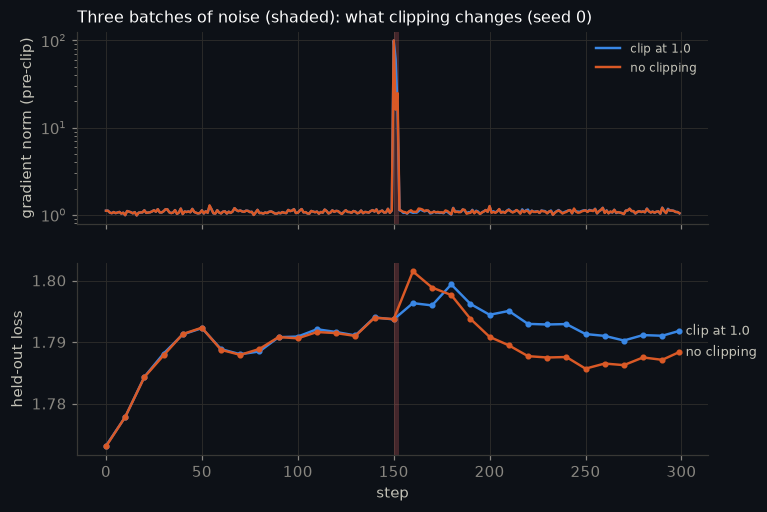

| seed | grad norm on the noise | worst damage: clip at 1.0 | no clipping | held-out at end: clip at 1.0 | no clipping |
|---|---|---|---|---|---|
| 0 | 100.2 (typical 1.08) | +0.0074 | +0.0097 | 1.7919 | 1.7884 |
| 1 | 93.7 (typical 1.09) | +0.0039 | +0.0088 | 1.7979 | 1.7954 |
| 2 | 99.6 (typical 1.09) | +0.0042 | +0.0077 | 1.7950 | 1.7933 |
| mean ± sd |  | +0.0052 ± 0.0019 | +0.0087 ± 0.0010 | 1.7949 ± 0.0030 | 1.7924 ± 0.0036 |

clipping reduced the worst damage in 3 of 3 seeds; by the end of the run the two differ by 0.0025 on average. AdamW already limits how far one batch can move the weights, so the benefit is bounded here; it grows with how big and how frequent the spikes are, which is why clipping is on from step one rather than added after the first incident.


In [34]:
BAD = Run(init_from="baseline", steps=qk(300, 40), micro_bs=qk(8, 4), accum=1, lr=1e-4, warmup=qk(10, 2), min_lr_frac=1.0,
          bad_steps=tuple(range(qk(150, 20), qk(153, 23))), eval_every=qk(10, 5), eval_batches=qk(5, 2), log_every=qk(100, 10))


def run_bad_batch():
    res = {}
    for sd in SEEDS:
        res[str(sd)] = {}
        for clip in (1.0, 0.0):
            out, m = train(replace(BAD, clip=clip, seed=sd, data_seed=sd), f"bad batches, clip={clip:g}, s{sd}"); del m; free_gpu()
            res[str(sd)][f"clip_{clip:g}"] = dict(loss=out["hist"]["loss"], gnorm=out["hist"]["gnorm"], val=out["val"])
    return res


def damage(r, b0, b_last):
    """Held-out loss before the noise, its worst value in the 30 steps after, the difference, and the final value."""
    vs, vl = np.array(r["val"]["step"]), np.array(r["val"]["loss"])
    before = vl[(vs < b0) & (vs >= b0 - 50)].mean()
    after = vl[(vs > b_last) & (vs <= b_last + 30)].max()
    return before, after, after - before, vl[-1]


bad = experiment("bad_batch_seeds", run_bad_batch)
if bad:
    b0, b_last = BAD.bad_steps[0], BAD.bad_steps[-1]
    seeds_b = sorted(bad, key=int)
    first = bad[seeds_b[0]]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.4, 5), sharex=True)
    for key, col, name in (("clip_1", C["blue"], "clip at 1.0"), ("clip_0", C["orange"], "no clipping")):
        r = first[key]
        a1.semilogy(np.arange(len(r["gnorm"])), r["gnorm"], color=col, label=name)
        a2.plot(r["val"]["step"], r["val"]["loss"], "o-", color=col, ms=3, label=name)
        label_end(a2, r["val"]["step"][-1], r["val"]["loss"][-1], name)
    for a_ in (a1, a2):
        a_.axvspan(b0, b_last + 1, color=C["red"], alpha=0.25, lw=0)
    a1.set_ylabel("gradient norm (pre-clip)"); a2.set_ylabel("held-out loss"); a2.set_xlabel("step")
    a1.set_title(f"Three batches of noise (shaded): what clipping changes (seed {seeds_b[0]})"); a1.legend(fontsize=8)
    finish(fig, "bad_batch_clip")
    rows, per_seed = [], []
    for sd in seeds_b:
        dc, dn = damage(bad[sd]["clip_1"], b0, b_last), damage(bad[sd]["clip_0"], b0, b_last)
        per_seed.append(dict(seed=int(sd), damage_clip=dc[2], damage_none=dn[2], end_clip=dc[3], end_none=dn[3],
                             spike=max(bad[sd]["clip_0"]["gnorm"][b0:b0 + 3]), typical=float(np.median(bad[sd]["clip_0"]["gnorm"][b0 - 50:b0]))))
        rows.append((sd, f"{per_seed[-1]['spike']:.1f} (typical {per_seed[-1]['typical']:.2f})", f"{dc[2]:+.4f}", f"{dn[2]:+.4f}",
                     f"{dc[3]:.4f}", f"{dn[3]:.4f}"))
    rows.append(("mean ± sd", "", mean_sd([r["damage_clip"] for r in per_seed]), mean_sd([r["damage_none"] for r in per_seed]),
                 mean_sd([r["end_clip"] for r in per_seed], "{:.4f}"), mean_sd([r["end_none"] for r in per_seed], "{:.4f}")))
    show(md_table(rows, ["seed", "grad norm on the noise", "worst damage: clip at 1.0", "no clipping",
                         "held-out at end: clip at 1.0", "no clipping"]))
    R["bad_batch_seeds_table"] = per_seed
    save_results()
    k = sum(r["damage_clip"] < r["damage_none"] for r in per_seed)
    print(f"clipping reduced the worst damage in {k} of {len(per_seed)} seeds; by the end of the run the two differ by "
          f"{np.mean([abs(r['end_clip'] - r['end_none']) for r in per_seed]):.4f} on average. AdamW already limits how far one batch can "
          "move the weights, so the benefit is bounded here; it grows with how big and how frequent the spikes are, which is why "
          "clipping is on from step one rather than added after the first incident.")

**Choosing the clip threshold from data, not habit.** The threshold should sit above the norms of ordinary steps and below the spikes. Here is the baseline run's distribution after warmup, against the conventional 1.0:

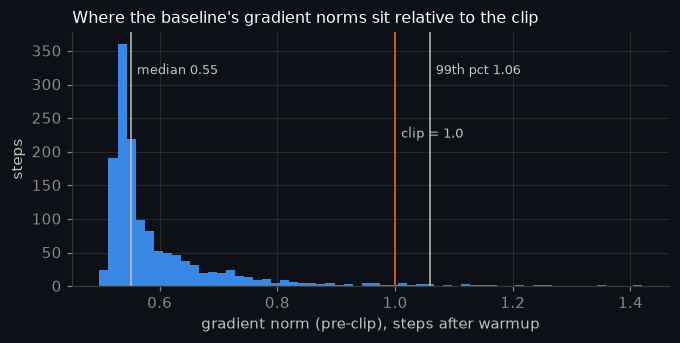

median 0.551, 90th pct 0.715, 99th pct 1.059, max 1.419; 6.7% of all steps were clipped at 1.0 (most of them during warmup)


In [35]:
cs = R.get("clip_stats")
if cs and base:
    g = np.array(base["hist"]["gnorm"])
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(g[base["run"]["warmup"]:], bins=60, color=C["blue"])
    for p, lab in ((cs["p50"], "median"), (cs["p99"], "99th pct")):
        ax.axvline(p, color=INK2, lw=1); label_end(ax, p, ax.get_ylim()[1] * 0.85, f"{lab} {p:.2f}")
    ax.axvline(1.0, color=C["orange"], lw=1.2); label_end(ax, 1.0, ax.get_ylim()[1] * 0.6, "clip = 1.0")
    ax.set_xlabel("gradient norm (pre-clip), steps after warmup"); ax.set_ylabel("steps")
    ax.set_title("Where the baseline's gradient norms sit relative to the clip")
    finish(fig, "gradnorm_hist")
    print(f"median {cs['p50']:.3f}, 90th pct {cs['p90']:.3f}, 99th pct {cs['p99']:.3f}, max {cs['max']:.3f}; "
          f"{100 * cs['clipped_frac']:.1f}% of all steps were clipped at 1.0 (most of them during warmup)")

> **Carry forward:** log the gradient norm from step one. In the instabilities created here it moved before the loss in every seed when both were measured against a fixed baseline, but a rolling-window detector, the kind that is easy to bolt onto a dashboard, did not catch the lead. Watch the norm against a reference you set before trouble starts. Clip from step one too, choose the threshold from the distribution you measured, and do not expect clipping to rescue a learning rate that is simply too high.

---
# Part III: Numbers inside the machine

## 12. How a computer holds a number

A computer has a fixed number of bits and must store values as large as 50,000 and as small as 0.00000001 in the same box. Plain counting cannot stretch that far, so the bits are split between three jobs, the way we write $6.02\times10^{23}$: the power says **how big**, the digits say **which number**.

| Piece | Its job | Bits |
|---|---|---|
| **sign** $s$ | positive or negative | always 1 |
| **exponent** $e$ | how big: the power of two | a few ($E$) |
| **mantissa** $m$ | the digits: where between two powers of two | the rest ($M$) |

**Math.** With bias $b = 2^{E-1}-1$ (so the stored exponent never needs a sign of its own):

$$
\text{normal } (0 < e < e_{\max}): \quad x = (-1)^s \times 2^{\,e - b} \times \Big(1 + \frac{m}{2^M}\Big)
\qquad\qquad
\text{subnormal } (e = 0): \quad x = (-1)^s \times 2^{\,1 - b} \times \frac{m}{2^M}
$$

The leading "1." of a normal number is not stored at all (it is always there, so it is free). Subnormals give up that hidden 1 to creep below the smallest normal number, losing digits as they go. The all-ones exponent is usually reserved for infinity and NaN, except in fp8 E4M3 (which keeps only one NaN pattern and uses the rest for numbers, reaching 448) and fp4 E2M1 (no specials at all).

| Format | $E$ | $M$ | bias | used for |
|---|---|---|---|---|
| fp32 | 8 | 23 | 127 | master weights, optimizer state, reductions |
| fp16 | 5 | 10 | 15 | mixed precision on older GPUs (with loss scaling) |
| bf16 | 8 | 7 | 127 | mixed precision on Ampere and later |
| fp8 E4M3 | 4 | 3 | 7 | matmul inputs on Hopper/Blackwell |
| fp8 E5M2 | 5 | 2 | 15 | gradients, where range matters more than digits |
| fp4 E2M1 | 2 | 1 | 1 | weights/activations with a shared block scale (Blackwell) |

**The trade, in one sentence:** exponent bits buy range, mantissa bits buy detail, and with a fixed total, more of one means less of the other.

Below: an exact encoder written from these formulas with Python's exact rational numbers (no floating point anywhere), then a fast vectorized version, both checked bit-for-bit against PyTorch's own conversions.

In [36]:
FORMATS = OrderedDict([                     # name: (E, M, style); style decides what the all-ones exponent means
    ("fp32", (8, 23, "ieee")),
    ("fp16", (5, 10, "ieee")),
    ("bf16", (8, 7, "ieee")),
    ("fp8 E4M3", (4, 3, "fn")),             # "finite": no infinities, only S.1111.111 is NaN
    ("fp8 E5M2", (5, 2, "ieee")),
    ("fp4 E2M1", (2, 1, "fp4")),            # no infinities and no NaN
])
TORCH_DTYPE = {"fp32": torch.float32, "fp16": torch.float16, "bf16": torch.bfloat16,
               "fp8 E4M3": torch.float8_e4m3fn, "fp8 E5M2": torch.float8_e5m2}


def fmt_props(E, M, style):
    bias = 2 ** (E - 1) - 1
    top = 2 ** E - 1                        # the all-ones exponent field
    if style == "ieee":                     # all-ones exponent reserved for inf/NaN
        max_v = (2 - Fraction(1, 2 ** M)) * Fraction(2) ** (top - 1 - bias)
    elif style == "fn":                     # all-ones exponent is usable except mantissa all-ones (NaN)
        max_v = (1 + Fraction(2 ** M - 2, 2 ** M)) * Fraction(2) ** (top - bias)
    else:                                   # every pattern is a number
        max_v = (1 + Fraction(2 ** M - 1, 2 ** M)) * Fraction(2) ** (top - bias)
    return dict(bias=bias, max=max_v, min_normal=Fraction(2) ** (1 - bias), min_sub=Fraction(2) ** (1 - bias - M),
                eps=Fraction(1, 2 ** M), digits=(M + 1) * math.log10(2))


def floor_log2(a):
    """Exact floor(log2(a)) for a positive Fraction."""
    e = a.numerator.bit_length() - a.denominator.bit_length()
    while Fraction(2) ** e > a:
        e -= 1
    while Fraction(2) ** (e + 1) <= a:
        e += 1
    return e


def encode_exact(x, E, M, style):
    """Round the exact rational x into the format (round to nearest, ties to even).
    Returns (sign, exponent field, mantissa field, stored value as a Fraction)."""
    x = Fraction(x)
    sign, a = int(x < 0), abs(x)
    P = fmt_props(E, M, style)
    if a == 0:
        return sign, 0, 0, Fraction(0)
    e = max(floor_log2(a), 1 - P["bias"])                # below the normal range the exponent stops falling
    n = round(a / Fraction(2) ** (e - M))                # Python rounds a Fraction half-to-even
    if n == 2 ** (M + 1):                                # rounding carried into the next power of two
        n, e = n // 2, e + 1
    value = n * Fraction(2) ** (e - M)
    if value > P["max"]:
        raise OverflowError(f"{float(x)} is beyond the largest value {float(P['max'])}")
    if n >= 2 ** M:
        return sign, e + P["bias"], n - 2 ** M, value * (1 - 2 * sign)
    return sign, 0, n, value * (1 - 2 * sign)            # subnormal: exponent field 0, no hidden 1


def quantize(x, E, M, style):
    """Vectorized: the value each element would have after rounding into the format (ties to even), in float64."""
    x = x.double()
    P = fmt_props(E, M, style)
    a = x.abs()
    _, ex = torch.frexp(a)                               # a = f * 2**ex with f in [0.5, 1): floor(log2 a) = ex - 1
    e = torch.clamp(ex - 1, min=1 - P["bias"])
    ulp = torch.ldexp(torch.ones_like(a), e - M)         # spacing of representable values around a
    q = torch.round(a / ulp) * ulp                       # torch.round is half-to-even
    mx = float(P["max"])
    if style == "ieee":
        q = torch.where(q > mx, torch.full_like(q, float("inf")), q)
    elif style == "fn":
        q = torch.where(q > mx, torch.full_like(q, float("nan")), q)
    else:
        q = torch.clamp(q, max=mx)                       # fp4 saturates
    q = torch.where(a == 0, torch.zeros_like(q), q)
    return torch.copysign(q, x)


# Bit-for-bit check against PyTorch: random values spread over each format's whole range (subnormals included),
# plus every exact midpoint between neighbouring representable values (the cases where rounding mode matters).
gen = torch.Generator().manual_seed(0)
results = []
for name, (E, M, style) in FORMATS.items():
    if name not in TORCH_DTYPE:
        continue
    P = fmt_props(E, M, style)
    lo, hi = math.log2(float(P["min_sub"])) - 1, math.log2(float(P["max"]) * 0.98)
    mags = torch.exp2(lo + (hi - lo) * torch.rand(100_000, generator=gen, dtype=torch.float64))
    vals = mags * torch.where(torch.rand(100_000, generator=gen) < 0.5, -1.0, 1.0).double()
    reps = quantize(vals, E, M, style).unique()
    reps = reps[torch.isfinite(reps)].sort().values
    mids = ((reps[1:] + reps[:-1]) / 2)[:20000]
    vals = torch.cat([vals, mids])
    src = vals if name == "fp32" else vals.float()           # PyTorch converts to 16/8-bit via fp32: feed it fp32
    mine = quantize(src.double(), E, M, style)
    theirs = src.to(TORCH_DTYPE[name]).double()
    same = (mine == theirs) | (mine.isnan() & theirs.isnan())
    results.append((name, len(vals), int(same.sum())))
show(md_table([(n, f"{t:,}", f"{s:,}", "yes" if s == t else "NO") for n, t, s in results],
              ["format", "values tested", "identical to PyTorch", "bit-exact"]))
check(all(s == t for _, t, s in results), "the hand-written rounding matches PyTorch on every value, midpoints included")

| format | values tested | identical to PyTorch | bit-exact |
|---|---|---|---|
| fp32 | 120,000 | 120,000 | yes |
| fp16 | 120,000 | 120,000 | yes |
| bf16 | 120,000 | 120,000 | yes |
| fp8 E4M3 | 100,251 | 100,251 | yes |
| fp8 E5M2 | 100,245 | 100,245 | yes |

✓ the hand-written rounding matches PyTorch on every value, midpoints included


> **Carry forward:** a float is sign × 2^(exponent − bias) × 1.mantissa. Exponent bits buy range, mantissa bits buy detail.

## 13. The number 0.1, by hand

0.1 is the classic number a computer cannot store exactly: in binary it never ends. Here is how each format gets as close as it can.

**Step 1: find the power of two.** $2^{-4} = 0.0625 \le 0.1 < 0.125 = 2^{-3}$, so $0.1 = 1.6 \times 2^{-4}$. The exponent is $-4$ and the significand is $1.6$.

**Step 2: write the fraction 0.6 in binary.** Repeatedly double and peel off the integer part:

In [37]:
frac, rows = Fraction(6, 10), []
for i in range(12):
    frac *= 2
    bit = int(frac >= 1)
    rows.append((f"{float(frac / 2):.1f} × 2 = {float(frac):.1f}", bit))
    frac -= bit
show(md_table(rows, ["doubling", "bit"]))
print("0.6 = 0." + "".join(str(b) for _, b in rows) + "...  (the block 1001 repeats forever)")

| doubling | bit |
|---|---|
| 0.6 × 2 = 1.2 | 1 |
| 0.2 × 2 = 0.4 | 0 |
| 0.4 × 2 = 0.8 | 0 |
| 0.8 × 2 = 1.6 | 1 |
| 0.6 × 2 = 1.2 | 1 |
| 0.2 × 2 = 0.4 | 0 |
| 0.4 × 2 = 0.8 | 0 |
| 0.8 × 2 = 1.6 | 1 |
| 0.6 × 2 = 1.2 | 1 |
| 0.2 × 2 = 0.4 | 0 |
| 0.4 × 2 = 0.8 | 0 |
| 0.8 × 2 = 1.6 | 1 |

0.6 = 0.100110011001...  (the block 1001 repeats forever)


So $1.6 = 1.\,1001\,1001\,1001\,1001\ldots_2$, and the hidden leading 1 is not stored.

**Step 3: store the exponent** as $-4 + \text{bias}$. **Step 4: keep $M$ mantissa bits and round** by looking at what is cut off. If the first dropped bit (the *guard* bit) is 1 and anything after it is nonzero, round up. If the guard bit is 0, round down. An exact tie goes to the even neighbour.

In [38]:
def bits_str(field, width):
    return format(field, f"0{width}b") if width else ""


x01 = Fraction(1, 10)
pattern = "1001" * 10                                  # 0.6 in binary, enough bits for every format here
walk, bit_rows = [], {}
for name, (E, M, style) in FORMATS.items():
    if name == "fp4 E2M1":
        continue
    s, e_f, m_f, val = encode_exact(x01, E, M, style)
    bias = fmt_props(E, M, style)["bias"]
    kept, guard, rest = pattern[:M], pattern[M], pattern[M + 1:]
    action = "round up" if guard == "1" and "1" in rest else ("round down" if guard == "0" else "tie")
    err = abs(val - x01) / x01
    bit_rows[name] = (s, bits_str(e_f, E), bits_str(m_f, M), val)
    walk.append((name, f"−4 + {bias} = {-4 + bias} → {bits_str(e_f, E)}", f"{kept} · {guard}{rest[:3]}…", action,
                 bits_str(m_f, M), f"{s} {bits_str(e_f, E)} {bits_str(m_f, M)}",
                 f"0x{(s << (E + M)) | (e_f << M) | m_f:0{(1 + E + M) // 4}X}", f"{float(val):.12g}", f"{float(err):.2e}"))
show(md_table(walk, ["format", "exponent field", "kept bits · first cut bits", "rounding", "stored mantissa",
                     "sign exponent mantissa", "hex", "stored value", "relative error"]))
if MODE != "learn":
    R["bits_0p1"] = walk

for name, (E, M, style) in FORMATS.items():
    if name in TORCH_DTYPE:
        n_bits = 1 + E + M
        t = torch.tensor(0.1, dtype=torch.float64 if name == "fp32" else torch.float32).to(TORCH_DTYPE[name])
        raw = t.view({32: torch.int32, 16: torch.int16, 8: torch.uint8}[n_bits]).item() & ((1 << n_bits) - 1)
        s, e_b, m_b, _ = bit_rows[name]
        assert format(raw, f"0{n_bits}b") == f"{s}{e_b}{m_b}", name
check(True, "PyTorch stores 0.1 with exactly these bits in fp32, fp16, bf16, fp8 E4M3 and fp8 E5M2")

one = []
for name, (E, M, style) in FORMATS.items():
    s, e_f, m_f, val = encode_exact(1, E, M, style)
    one.append((name, f"{s} {bits_str(e_f, E)} {bits_str(m_f, M)}", f"0x{(s << (E + M)) | (e_f << M) | m_f:0{max(1, (1 + E + M) // 4)}X}", float(val)))
print("And 1.0, which every format stores exactly (exponent field = bias, mantissa all zero):")
show(md_table(one, ["format", "bits", "hex", "value"]))

| format | exponent field | kept bits · first cut bits | rounding | stored mantissa | sign exponent mantissa | hex | stored value | relative error |
|---|---|---|---|---|---|---|---|---|
| fp32 | −4 + 127 = 123 → 01111011 | 10011001100110011001100 · 1100… | round up | 10011001100110011001101 | 0 01111011 10011001100110011001101 | 0x3DCCCCCD | 0.10000000149 | 1.49e-08 |
| fp16 | −4 + 15 = 11 → 01011 | 1001100110 · 0110… | round down | 1001100110 | 0 01011 1001100110 | 0x2E66 | 0.0999755859375 | 2.44e-04 |
| bf16 | −4 + 127 = 123 → 01111011 | 1001100 · 1100… | round up | 1001101 | 0 01111011 1001101 | 0x3DCD | 0.10009765625 | 9.77e-04 |
| fp8 E4M3 | −4 + 7 = 3 → 0011 | 100 · 1100… | round up | 101 | 0 0011 101 | 0x1D | 0.1015625 | 1.56e-02 |
| fp8 E5M2 | −4 + 15 = 11 → 01011 | 10 · 0110… | round down | 10 | 0 01011 10 | 0x2E | 0.09375 | 6.25e-02 |

✓ PyTorch stores 0.1 with exactly these bits in fp32, fp16, bf16, fp8 E4M3 and fp8 E5M2
And 1.0, which every format stores exactly (exponent field = bias, mantissa all zero):


| format | bits | hex | value |
|---|---|---|---|
| fp32 | 0 01111111 00000000000000000000000 | 0x3F800000 | 1 |
| fp16 | 0 01111 0000000000 | 0x3C00 | 1 |
| bf16 | 0 01111111 0000000 | 0x3F80 | 1 |
| fp8 E4M3 | 0 0111 000 | 0x38 | 1 |
| fp8 E5M2 | 0 01111 00 | 0x3C | 1 |
| fp4 E2M1 | 0 01 0 | 0x2 | 1 |

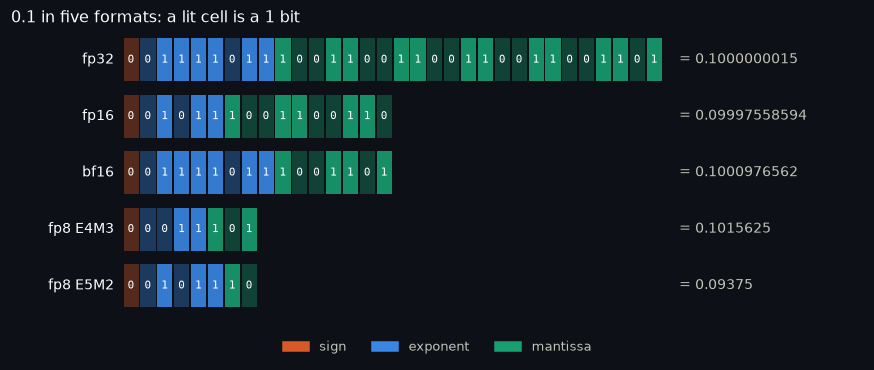

In [39]:
fig, ax = plt.subplots(figsize=(10, 3.4))
order = ["fp32", "fp16", "bf16", "fp8 E4M3", "fp8 E5M2"]
cw = 0.27
for r, name in enumerate(order):
    s, e_b, m_b, val = bit_rows[name]
    y = len(order) - 1 - r
    cells = [(s, C["orange"])] + [(b, C["blue"]) for b in e_b] + [(b, C["aqua"]) for b in m_b]
    for i, (b, col) in enumerate(cells):
        ax.add_patch(plt.Rectangle((i * cw, y + 0.12), cw * 0.9, 0.76, color=col, alpha=0.9 if b == "1" else 0.35, lw=0))
        ax.text(i * cw + cw * 0.45, y + 0.5, b, ha="center", va="center", color=INK, fontsize=7.5, family="monospace")
    ax.text(-0.15, y + 0.5, name, ha="right", va="center", color=INK, fontsize=9)
    ax.text(32 * cw + 0.25, y + 0.5, f"= {float(val):.10g}", ha="left", va="center", color=INK2, fontsize=9)
for col, lab in ((C["orange"], "sign"), (C["blue"], "exponent"), (C["aqua"], "mantissa")):
    ax.add_patch(plt.Rectangle((0, -10), 0.1, 0.1, color=col, label=lab))
ax.set_xlim(-1.8, 32 * cw + 3.2); ax.set_ylim(-0.1, len(order)); ax.axis("off")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=8.5)
ax.set_title("0.1 in five formats: a lit cell is a 1 bit", loc="left")
finish(fig, "bits_of_0p1")

Reading the table: **fp32** keeps 23 bits of the repeating pattern and is off by about 1.5 parts in $10^8$. **bf16** keeps the same 8-bit exponent as fp32 (its top 16 bits *are* fp32's top 16 bits, rounded) but only 7 mantissa bits, so it is off by 0.1%. **fp16** has 3 more mantissa bits than bf16 and is 4× more accurate here, but its 5-bit exponent will cost it dearly in §15. **fp8 E4M3** stores 0.1 as 0.1015625 (off by 1.6%), and **E5M2** as 0.09375 (off by 6%).

> **Carry forward:** most decimals are not representable. Every format stores the nearest neighbour it has, and the neighbours get farther apart as the mantissa shrinks.

## 14. The trade, in one table

Everything about a format follows from $E$ and $M$:

$$
\text{largest} \approx 2^{\,2^{E-1}}, \qquad \text{smallest normal} = 2^{\,1-b}, \qquad \text{smallest subnormal} = 2^{\,1-b-M}, \qquad \varepsilon = 2^{-M}, \qquad \text{decimal digits} = (M+1)\log_{10}2
$$

($\varepsilon$, the *machine epsilon*, is the gap between 1 and the next number up. Relative rounding error is at most $\varepsilon/2$.)

In [40]:
rows = []
for name, (E, M, style) in FORMATS.items():
    P = fmt_props(E, M, style)
    rows.append((name, 1 + E + M, E, M, f"{float(P['max']):.4g}", f"{float(P['min_normal']):.3g}",
                 f"{float(P['min_sub']):.3g}", f"{float(P['eps']):.3g}", f"{P['digits']:.1f}"))
    if name in TORCH_DTYPE:
        fi = torch.finfo(TORCH_DTYPE[name])
        assert (fi.max, fi.tiny, fi.eps) == (float(P["max"]), float(P["min_normal"]), float(P["eps"])), name
show(md_table(rows, ["format", "bits", "E", "M", "largest", "smallest normal", "smallest subnormal", "ε", "decimal digits"]))
check(True, "largest value, smallest normal and ε derived from (E, M) match torch.finfo for all five torch formats")

| format | bits | E | M | largest | smallest normal | smallest subnormal | ε | decimal digits |
|---|---|---|---|---|---|---|---|---|
| fp32 | 32 | 8 | 23 | 3.403e+38 | 1.18e-38 | 1.4e-45 | 1.19e-07 | 7.2 |
| fp16 | 16 | 5 | 10 | 6.55e+04 | 6.1e-05 | 5.96e-08 | 0.000977 | 3.3 |
| bf16 | 16 | 8 | 7 | 3.39e+38 | 1.18e-38 | 9.18e-41 | 0.00781 | 2.4 |
| fp8 E4M3 | 8 | 4 | 3 | 448 | 0.0156 | 0.00195 | 0.125 | 1.2 |
| fp8 E5M2 | 8 | 5 | 2 | 5.734e+04 | 6.1e-05 | 1.53e-05 | 0.25 | 0.9 |
| fp4 E2M1 | 4 | 2 | 1 | 6 | 1 | 0.5 | 0.5 | 0.6 |

✓ largest value, smallest normal and ε derived from (E, M) match torch.finfo for all five torch formats


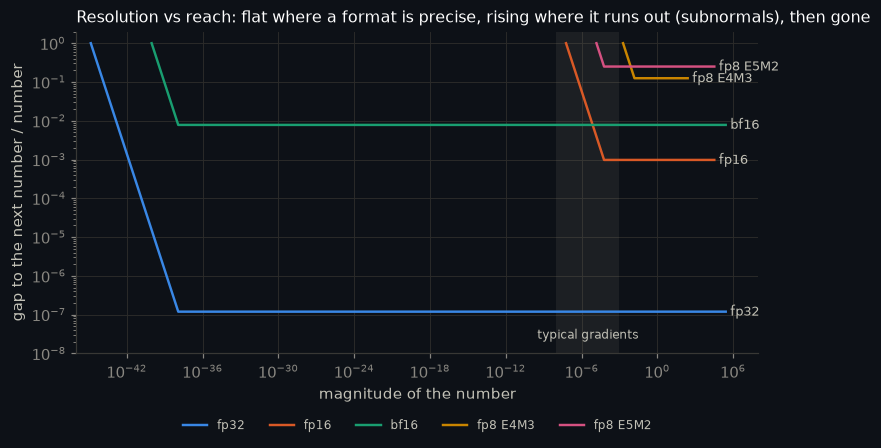

In [41]:
xs = 2.0 ** np.arange(-152, 19)                      # exact powers of two: the spacing is cleanest to read there
fig, ax = plt.subplots(figsize=(8, 3.8))
for (name, (E, M, style)), col in zip(FORMATS.items(), SERIES):
    if name == "fp4 E2M1":
        continue
    P = fmt_props(E, M, style)
    e = np.maximum(np.floor(np.log2(xs)), 1 - P["bias"])
    rel = 2.0 ** (e - M) / xs
    ok = (xs >= float(P["min_sub"])) & (xs <= float(P["max"]))
    ax.loglog(xs[ok], rel[ok], color=col, label=name)
    label_end(ax, xs[ok][-1], rel[ok][-1], name, dx=3)
ax.axvspan(1e-8, 1e-3, color=MUTED, alpha=0.12, lw=0)
ax.text(10 ** -5.5, 2e-8, "typical gradients", color=INK2, fontsize=8, ha="center", va="bottom")
ax.set_ylim(1e-8, 2); ax.set_xlim(1e-46, 1e8)
ax.set_xlabel("magnitude of the number"); ax.set_ylabel("gap to the next number / number")
ax.set_title("Resolution vs reach: flat where a format is precise, rising where it runs out (subnormals), then gone")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=5)
finish(fig, "format_resolution")

Each line is flat at $\approx 2^{-M}$ across the format's normal range: that is its resolution. On the left, each rises steeply through the subnormals and then simply ends: below that, the number becomes zero. fp32 and bf16 reach equally far left (same 8-bit exponent). fp16 stops near $6\times10^{-8}$, and its precise range ends near $6\times10^{-5}$, squarely inside the band where gradients live.

> **Carry forward:** look at a format's range before its precision. Running out of range turns a number into 0 or ∞; running out of precision only makes it a little wrong.

## 15. Why bf16 replaced fp16

| Format | Exponent bits | Mantissa bits | Smallest normal | Decimal digits |
|---|---|---|---|---|
| fp32 | 8 | 23 | $1.18\times10^{-38}$ | 7.2 |
| fp16 | 5 | 10 | $6.1\times10^{-5}$ | 3.3 |
| bf16 | 8 | 7 | $1.18\times10^{-38}$ | 2.4 |

bf16 keeps all eight of fp32's exponent bits, so it reaches exactly as far, and pays with detail (2.4 digits instead of 7.2). fp16 made the opposite bargain: more digits, much less range. Late in training, gradients become genuinely tiny, and fp16 rounds anything below about $3\times10^{-8}$ to **exactly zero**. A zero gradient means that weight does not move: the model quietly stops learning exactly where the signal was faintest.

The rescue for fp16 is **loss scaling**: multiply the loss by $S$ (say 1024) before `backward()`, so every gradient is $S$ times larger and clears the floor, then divide by $S$ before the optimizer uses them:

$$
10^{-8} \times 1024 = 1.02\times10^{-5}\ \text{(survives in fp16)}, \quad\text{then}\quad \div 1024
$$

PyTorch's `GradScaler` picks $S$ dynamically: it doubles it every so often and halves it (skipping that step) whenever a gradient overflows to infinity. It works, and it is one more moving part to get wrong. bf16's smallest subnormal is $9.2\times10^{-41}$, which no gradient will ever approach, so with bf16 the whole apparatus is unnecessary.

**Measured on our model.** Below: the actual gradients of Model A on one batch, computed in fp32, then asked what fp16 and bf16 would do to each of them. This covers the weight gradients, and also the *activation* gradients that flow backwards between layers, which is where an fp16 backward pass really lives.

[grad_magnitudes] reusing the result stored earlier (FORCE=1 redoes it)


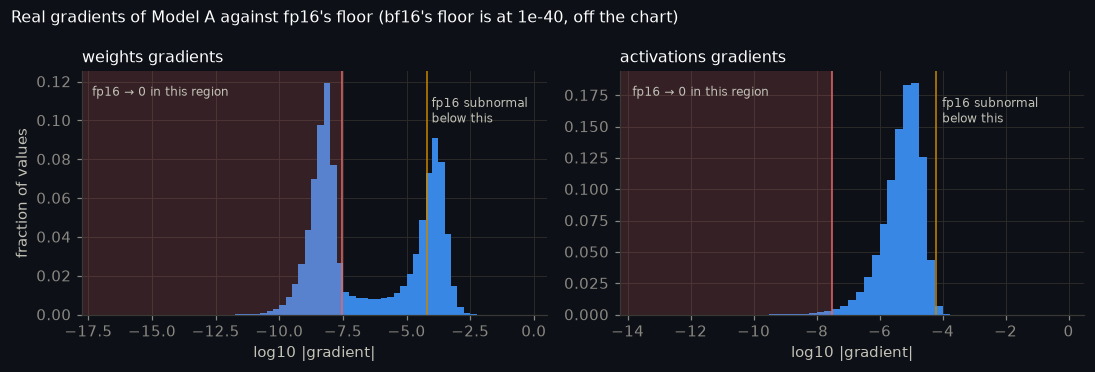

| gradient | median magnitude | fp16: becomes 0 | fp16: subnormal (digits lost) | fp16 ×1024: becomes 0 | bf16: becomes 0 |
|---|---|---|---|---|---|
| weights (31,463,808 values) | 3.63e-08 | 49.515% | 21.00% | 0.1981% | 0.0000% |
| activations (12,582,912 values) | 6.53e-06 | 0.806% | 98.66% | 0.0019% | 0.0000% |

✓ loss scaling rescues gradients that plain fp16 would flush to zero
the embedding/output matrix is 60% of the weights but owns 100% of the weight gradients fp16 would zero: the rows of tokens absent from the batch get only a sliver of gradient through the softmax (the left peak)


In [42]:
F16 = fmt_props(5, 10, "ieee")
FP16_SUB, FP16_NORMAL = float(F16["min_sub"]), float(F16["min_normal"])


def run_grad_magnitudes():
    ck = CKPT / "baseline.pt"
    m = make_model(MODEL_A)
    if ck.exists():
        m.load_state_dict(torch.load(ck, map_location=DEV))
    acts = []

    def grab_grad(mod, inputs, output):          # a forward hook must return None, or it replaces the output
        output.register_hook(lambda g: acts.append(g.detach().flatten()))

    hooks = [blk.register_forward_hook(grab_grad) for blk in m.layers]
    x, y = PackedLoader(VALID, qk(512, 128), seed=3).micro(qk(8, 4))
    with matmul_precision("fp32"):
        m(x.to(DEV), y.to(DEV)).backward()
    for h_ in hooks:
        h_.remove()
    out = {}
    bins = np.arange(-46, 1.01, 0.25)
    emb = m.embed_tokens.weight.grad.flatten()
    others = torch.cat([p.grad.flatten() for n_, p in m.named_parameters() if n_ != "embed_tokens.weight"])
    tiny_e, tiny_o = int(((emb != 0) & (emb.half() == 0)).sum()), int(((others != 0) & (others.half() == 0)).sum())
    out["embedding_share_of_fp16_zeros"] = tiny_e / max(1, tiny_e + tiny_o)
    out["embedding_share_of_weights"] = emb.numel() / (emb.numel() + others.numel())
    for kind, g in (("weights", torch.cat([p.grad.flatten() for p in m.parameters()])), ("activations", torch.cat(acts))):
        g = g[g != 0]
        a = g.abs().double().cpu()
        rec_ = dict(n=len(a), hist=np.histogram(np.log10(a.numpy()), bins=bins)[0], median=float(a.median()))
        for S in (1, 1024):
            gs = (g * S)
            rec_[f"fp16_zero_S{S}"] = float((gs.half() == 0).float().mean())
            rec_[f"fp16_subnormal_S{S}"] = float(((gs.abs() < FP16_NORMAL) & (gs.half() != 0)).float().mean())
        rec_["bf16_zero"] = float((g.bfloat16() == 0).float().mean())
        out[kind] = rec_
    del m; free_gpu()
    out["bins"] = bins
    return out


gm = experiment("grad_magnitudes", run_grad_magnitudes)
if gm:
    bins = np.array(gm["bins"])
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.4), sharey=False)
    for ax, kind in zip(axs, ("weights", "activations")):
        r = gm[kind]
        ax.bar(bins[:-1], np.array(r["hist"]) / r["n"], width=0.25, align="edge", color=C["blue"])
        ax.axvspan(-47, math.log10(FP16_SUB / 2), color=C["red"], alpha=0.18, lw=0)
        ax.axvline(math.log10(FP16_NORMAL), color=C["yellow"], lw=1)
        ax.axvline(math.log10(FP16_SUB / 2), color=C["red"], lw=1)
        lo = bins[:-1][np.array(r["hist"]) > 0].min() - 1
        ax.set_xlim(min(lo, -10), 0.5)
        ax.set_xlabel("log10 |gradient|"); ax.set_title(f"{kind} gradients")
        ax.text(ax.get_xlim()[0] + 0.4, ax.get_ylim()[1] * 0.9, "fp16 → 0 in this region", ha="left", color=INK2, fontsize=8)
        ax.text(math.log10(FP16_NORMAL) + 0.2, ax.get_ylim()[1] * 0.9, "fp16 subnormal\nbelow this", ha="left", color=INK2, fontsize=8, va="top")
    axs[0].set_ylabel("fraction of values")
    fig.suptitle("Real gradients of Model A against fp16's floor (bf16's floor is at 1e-40, off the chart)", color=INK, x=0.01, ha="left", fontsize=10.5)
    fig.tight_layout()
    finish(fig, "grad_magnitudes_vs_fp16")
    rows = []
    for kind in ("weights", "activations"):
        r = gm[kind]
        rows.append((f"{kind} ({r['n']:,} values)", f"{r['median']:.2e}", f"{100 * r['fp16_zero_S1']:.3f}%",
                     f"{100 * r['fp16_subnormal_S1']:.2f}%", f"{100 * r['fp16_zero_S1024']:.4f}%", f"{100 * r['bf16_zero']:.4f}%"))
    show(md_table(rows, ["gradient", "median magnitude", "fp16: becomes 0", "fp16: subnormal (digits lost)",
                         "fp16 ×1024: becomes 0", "bf16: becomes 0"]))
    observe(gm["activations"]["fp16_zero_S1"] > gm["activations"]["fp16_zero_S1024"],
            "loss scaling rescues gradients that plain fp16 would flush to zero")
    if "embedding_share_of_fp16_zeros" in gm:
        print(f"the embedding/output matrix is {100 * gm['embedding_share_of_weights']:.0f}% of the weights but owns "
              f"{100 * gm['embedding_share_of_fp16_zeros']:.0f}% of the weight gradients fp16 would zero: the rows of tokens "
              "absent from the batch get only a sliver of gradient through the softmax (the left peak)")

**Then the training curves.** The same model and data, trained five ways, each with three seeds: fp32, TF32 (fp32 storage with 10-bit-mantissa tensor-core matmuls), bf16 autocast, fp16 autocast with `GradScaler`, and fp16 autocast *without* loss scaling. All of them use fp32 master weights. If a precision needs more memory, it gets a smaller micro-batch and more accumulation, so every run sees the same global batch.

           fp32 s0 step     0  loss 10.8169  grad-norm    9.890  lr 3.33e-05    21.9K tok/s  held-out 10.6349


           fp32 s0 step   200  loss  3.5937  grad-norm    0.935  lr 6.07e-04    28.7K tok/s  held-out 3.3050


           fp32 s0 step   399  loss  2.7458  grad-norm    0.792  lr 1.00e-04    27.4K tok/s  held-out 2.9279


           fp32 s1 step     0  loss 10.8653  grad-norm   14.294  lr 3.33e-05    20.5K tok/s  held-out 10.6100


           fp32 s1 step   200  loss  3.0311  grad-norm    0.944  lr 6.07e-04    26.1K tok/s  held-out 3.2930


...

   fp16_noscale s1 step   200  loss  3.1875  grad-norm    1.659  lr 6.07e-04    43.2K tok/s  held-out 3.4638


   fp16_noscale s1 step   399  loss  2.9613  grad-norm    0.957  lr 1.00e-04    46.1K tok/s  held-out 3.0661


   fp16_noscale s2 step     0  loss 10.8786  grad-norm   11.791  lr 3.33e-05    25.0K tok/s  held-out 10.6696


   fp16_noscale s2 step   200  loss  3.4901  grad-norm    1.604  lr 6.07e-04    43.3K tok/s  held-out 3.5800


   fp16_noscale s2 step   399  loss  3.4885  grad-norm    1.431  lr 1.00e-04    43.6K tok/s  held-out 3.1368


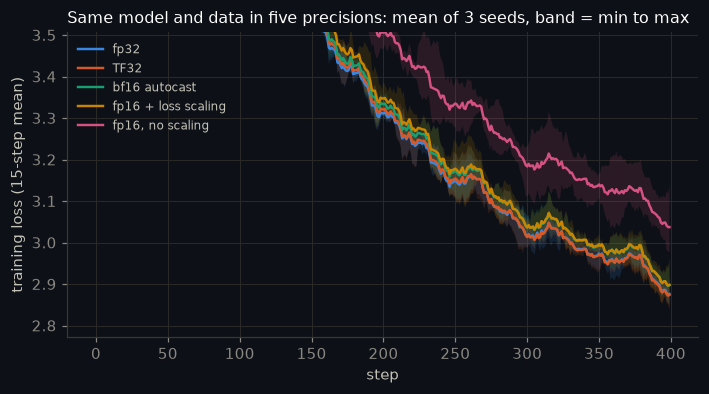

| precision | micro-batch × accumulation | final held-out loss, mean ± sd | per seed | tokens/s | peak memory | mean SM clock |
|---|---|---|---|---|---|---|
| fp32 | 8×1 | 2.9253 ± 0.0039 | 2.9279, 2.9272, 2.9208 | 26.9K | 3.86 GiB | 1830 MHz |
| TF32 | 8×1 | 2.9204 ± 0.0165 | 2.9393, 2.9089, 2.9130 | 31.7K | 3.86 GiB | 1862 MHz |
| bf16 autocast | 8×1 | 2.9418 ± 0.0170 | 2.9520, 2.9222, 2.9513 | 42.0K | 3.60 GiB | 1838 MHz |
| fp16 + loss scaling | 8×1 | 2.9454 ± 0.0279 | 2.9635, 2.9132, 2.9594 | 41.5K | 3.60 GiB | 1828 MHz |
| fp16, no scaling | 8×1 | 3.0850 ± 0.0454 | 3.0522, 3.0661, 3.1368 | 41.9K | 3.60 GiB | 1830 MHz |

(tokens/s here is indicative: the runs went one after another and a laptop GPU slows as it heats.
 §20 measures speed properly, alternating configurations to cancel the drift.)
fp16 without loss scaling: 3.0850 ± 0.0454; the other precisions' means span 2.9204–2.9454; it was the worst precision in 3 of 3 seeds
✓ in every seed, fp16 without loss scaling is the precision that learns worst
bf16 ran 1.6x as many tokens/s as fp32, in 0.93x the memory


In [43]:
PREC = Run(steps=qk(400, 30), micro_bs=qk(8, 4), accum=1, warmup=qk(30, 5), eval_every=qk(100, 10), eval_batches=qk(10, 2),
           log_every=qk(200, 10), min_lr_frac=0.1)


def run_precisions():
    names = ["fp32", "tf32", "bf16", "fp16", "fp16_noscale"] if DEV == "cuda" else ["fp32"]
    if CAP < (8, 0):
        names.remove("bf16")                      # no bf16 tensor cores before Ampere (e.g. a T4)
    res = {}
    for p in names:
        run0 = fit_micro_batch(replace(PREC, precision=p))
        per = []
        for sd in SEEDS:
            out, m = train(replace(run0, seed=sd, data_seed=sd), f"{p} s{sd}"); del m; free_gpu()
            h = out["hist"]
            per.append(dict(loss=h["true_loss"], val=out["val"], tok_s=float(np.median(h["tok_s"][5:])), peak_mem_gib=out["peak_mem_gib"],
                            clock=float(np.median([c for c in h.get("clock", []) if c])) if h.get("clock") else None))
        res[p] = dict(micro_bs=run0.micro_bs, accum=run0.accum, seeds=per)
    return res


prec = experiment("precision_seeds", run_precisions)
if prec:
    labels = dict(fp32="fp32", tf32="TF32", bf16="bf16 autocast", fp16="fp16 + loss scaling", fp16_noscale="fp16, no scaling")
    n_seeds = len(next(iter(prec.values()))["seeds"])
    fig, ax = plt.subplots(figsize=(7.4, 3.6))
    lows = []
    for (p, r), col in zip(prec.items(), SERIES):
        curves = np.array([smooth(s_["loss"], 15) for s_ in r["seeds"]])
        x_ = np.arange(curves.shape[1])
        ax.plot(x_, np.nanmean(curves, 0), color=col, label=labels[p])
        if len(curves) > 1:
            ax.fill_between(x_, np.nanmin(curves, 0), np.nanmax(curves, 0), color=col, alpha=0.15, lw=0)
        lows.append(np.nanmin(np.nanmean(curves, 0)))
    top = np.nanpercentile(np.nanmean([smooth(s_["loss"], 15) for s_ in prec["fp32"]["seeds"]], 0), 60)
    ax.set_ylim(min(lows) - 0.1, top)
    ax.set_xlabel("step"); ax.set_ylabel("training loss (15-step mean)")
    ax.set_title(f"Same model and data in five precisions: mean of {n_seeds} seeds, band = min to max")
    ax.legend(fontsize=8)
    finish(fig, "precision_curves")
    finals = {p: [s_["val"]["loss"][-1] for s_ in r["seeds"]] for p, r in prec.items()}
    rows = [(labels[p], f"{r['micro_bs']}×{r['accum']}", mean_sd(finals[p], "{:.4f}"), ", ".join(f"{v:.4f}" for v in finals[p]),
             f"{np.mean([s_['tok_s'] for s_ in r['seeds']]) / 1e3:.1f}K", f"{max(s_['peak_mem_gib'] or 0 for s_ in r['seeds']):.2f} GiB",
             f"{np.mean([s_['clock'] or 0 for s_ in r['seeds']]):.0f} MHz") for p, r in prec.items()]
    show(md_table(rows, ["precision", "micro-batch × accumulation", "final held-out loss, mean ± sd", "per seed", "tokens/s",
                         "peak memory", "mean SM clock"]))
    print("(tokens/s here is indicative: the runs went one after another and a laptop GPU slows as it heats.\n"
          " §20 measures speed properly, alternating configurations to cancel the drift.)")
    if "fp16_noscale" in finals and len(finals) > 1:
        others = [p for p in finals if p != "fp16_noscale"]
        worst_in = sum(finals["fp16_noscale"][i] > max(finals[p][i] for p in others) for i in range(n_seeds))
        means = {p: np.mean(v) for p, v in finals.items()}
        print(f"fp16 without loss scaling: {mean_sd(finals['fp16_noscale'], '{:.4f}')}; the other precisions' means span "
              f"{min(means[p] for p in others):.4f}–{max(means[p] for p in others):.4f}; it was the worst precision in {worst_in} of {n_seeds} seeds")
        observe(worst_in == n_seeds, "in every seed, fp16 without loss scaling is the precision that learns worst")
    if "bf16" in prec:
        tok = {p: np.mean([s_["tok_s"] for s_ in r["seeds"]]) for p, r in prec.items()}
        mem = {p: max(s_["peak_mem_gib"] or 0 for s_ in r["seeds"]) for p, r in prec.items()}
        print(f"bf16 ran {tok['bf16'] / tok['fp32']:.1f}x as many tokens/s as fp32, in {mem['bf16'] / mem['fp32']:.2f}x the memory")

Read the curves with the gradient table above. fp32, TF32, bf16 and fp16 *with* loss scaling land together: all keep fp32 master weights, and none loses gradients. fp16 **without** scaling flushes a large share of the gradients to exactly zero, and it is the one that learns visibly worse (the printout counts in how many seeds). Meanwhile the 16-bit runs move about twice as many tokens per second as fp32. bf16 gets fp16's speed with fp32's range, so the danger is not managed by a scaler. It simply cannot happen.

> **Carry forward:** bf16 is less precise than fp16 and won anyway, because range mattered more than digits.

## 16. The newer formats: fp8 and fp4

Once the trade is clear, the newer formats read easily:

| Format | Bits | Exponent | Mantissa | Decimal digits |
|---|---|---|---|---|
| fp8 E4M3 | 8 | 4 | 3 | 1.2 |
| fp8 E5M2 | 8 | 5 | 2 | 0.9 |
| fp4 E2M1 | 4 | 2 | 1 | 0.6 |

Six tenths of a decimal digit ought to worry you. fp4 E2M1 can represent exactly fifteen values: $0, \pm0.5, \pm1, \pm1.5, \pm2, \pm3, \pm4, \pm6$. It works only because its numbers are **never alone**: a block of them shares one scale factor, stored once.

$$
\text{NVFP4: } \frac{16 \times 4 \text{ bits} + 8 \text{ bits of shared scale}}{16} = 4.5 \text{ bits per value}
\qquad
\text{MXFP8: } \frac{32\times 8 + 8}{32} = 8.25 \text{ bits per value}
$$

**Scaling is the whole trick.** fp8 E4M3 cannot represent anything below $2^{-9} \approx 0.002$, so an unscaled weight of 0.001 becomes 0 (100% error). Divide a tensor by its own maximum first (store the scale in fp32 on the side) and its values land where the format is precise. A shared scale has a cost: one **outlier** in a block forces a large scale on every value in it.

Our GPU (Ampere) has no fp8 tensor cores, so this section **simulates** the formats with the exact rounding from §12: quantize, dequantize, and measure the error. Hopper and Blackwell GPUs do the same arithmetic in hardware, faster.

In [44]:
E4M3, E2M1 = FORMATS["fp8 E4M3"], FORMATS["fp4 E2M1"]
MAX_E4M3, MAX_E2M1 = float(fmt_props(*E4M3)["max"]), float(fmt_props(*E2M1)["max"])


def q_tensor(x, fmt, scale="none", block=None):
    """Quantize-dequantize x into fmt with no scale, one scale per tensor, or one scale per block of `block` values."""
    E, M, style = fmt
    mx = float(fmt_props(*fmt)["max"])
    x = x.double()
    if scale == "none":
        return quantize(x, *fmt)
    if scale == "tensor":
        s = x.abs().max() / mx
        return quantize((x / s).clamp(-mx, mx), *fmt) * s
    xb = x.reshape(-1, block)
    amax = xb.abs().amax(1, keepdim=True).clamp_min(1e-30)
    if scale == "pow2":                    # MX: the shared scale is a power of two (an 8-bit exponent, E8M0)
        emax = math.floor(math.log2(mx))
        s = torch.exp2(torch.floor(torch.log2(amax)) - emax)
    else:                                  # NVFP4: the shared scale is itself an fp8 E4M3 number, plus one fp32 per tensor
        st = x.abs().max() / (mx * MAX_E4M3)
        s = quantize(amax / mx / st, *E4M3) * st
        s = torch.where(s == 0, torch.ones_like(s), s)
    return (quantize((xb / s).clamp(-mx, mx), *fmt) * s).reshape(x.shape)    # scaled formats saturate


SCHEMES = [("fp8 E4M3, no scale", E4M3, "none", None, 8), ("fp8 E4M3, one scale per tensor", E4M3, "tensor", None, 8),
           ("MXFP8 (E4M3, power-of-2 scale per 32)", E4M3, "pow2", 32, 8.25),
           ("fp4 E2M1, one scale per tensor", E2M1, "tensor", None, 4),
           ("MXFP4 (E2M1, power-of-2 scale per 32)", E2M1, "pow2", 32, 4.25),
           ("NVFP4 (E2M1, E4M3 scale per 16)", E2M1, "nv", 16, 4.5)]


def quant_table(x):
    rows = []
    for name, fmt, sc, blk, bits in SCHEMES:
        q = q_tensor(x, fmt, sc, blk)
        err = ((q - x.double()).norm() / x.double().norm()).item()
        zero = ((q == 0) & (x != 0)).double().mean().item()
        rows.append(dict(scheme=name, bits=bits, rel_err=err, zeroed=zero))
    return rows


def show_quant(rows, title):
    print(title)
    show(md_table([(r["scheme"], r["bits"], f"{100 * r['rel_err']:.2f}%", f"{100 * r['zeroed']:.2f}%") for r in rows],
                  ["scheme", "bits per value", "relative error", "values flushed to 0"]))


# Live demo on synthetic tensors: Student-t values (heavy tails, like real ones) at three typical sizes.
gq = torch.Generator().manual_seed(0)
torch.manual_seed(0)
t_base = torch.distributions.StudentT(4.0).sample((256, 256)).double()
sizes = {"weights (std 0.02)": 0.02, "residual-branch weights (std 0.005)": 0.005, "gradients (std 1e-5)": 1e-5}
rows, flushed = [], {}
for lab, std in sizes.items():
    x_ = t_base * std
    for sc, sc_lab in (("none", "no scale"), ("tensor", "one scale per tensor")):
        q = q_tensor(x_, E4M3, sc)
        err = ((q - x_).norm() / x_.norm()).item(); fl = ((q == 0) & (x_ != 0)).double().mean().item()
        flushed[(lab, sc)] = fl
        rows.append((lab, sc_lab, f"{100 * err:.2f}%", f"{100 * fl:.2f}%"))
print("fp8 E4M3 with and without a scale, on tensors of three sizes:")
show(md_table(rows, ["tensor", "fp8 E4M3", "relative error", "values flushed to 0"]))
check(flushed[("gradients (std 1e-5)", "none")] > 0.9 and flushed[("gradients (std 1e-5)", "tensor")] < 0.01,
      "unscaled fp8 erases a gradient-sized tensor completely; a per-tensor scale keeps it")
w_syn = t_base * 0.02
show_quant(quant_table(w_syn), "Every scheme on the synthetic weight matrix (std 0.02):")

# The outlier: 16 ordinary values and one 100x larger in the same block.
blk = torch.randn(64, 16, generator=gq, dtype=torch.float64) * 0.02
blk_out = blk.clone(); blk_out[0, 0] = 2.0
rows = []
for name, data in (("no outlier", blk), ("one outlier (100x) in block 0", blk_out)):
    for sc, lab in (("tensor", "one scale per tensor"), ("nv", "one scale per 16-value block")):
        q = q_tensor(data, E2M1, sc, 16)
        e_rest = ((q[1:] - data[1:]).norm() / data[1:].norm()).item()          # every block except the outlier's
        e_blk0 = ((q[0, 1:] - data[0, 1:]).norm() / data[0, 1:].norm()).item()  # the outlier's neighbours
        rows.append((name, lab, f"{100 * e_blk0:.1f}%", f"{100 * e_rest:.1f}%"))
show(md_table(rows, ["data", "fp4 scaling", "error: neighbours of the outlier", "error: all other blocks"]))

fp8 E4M3 with and without a scale, on tensors of three sizes:


| tensor | fp8 E4M3 | relative error | values flushed to 0 |
|---|---|---|---|
| weights (std 0.02) | no scale | 2.95% | 3.67% |
| weights (std 0.02) | one scale per tensor | 2.65% | 0.00% |
| residual-branch weights (std 0.005) | no scale | 8.01% | 14.51% |
| residual-branch weights (std 0.005) | one scale per tensor | 2.65% | 0.00% |
| gradients (std 1e-5) | no scale | 100.00% | 100.00% |
| gradients (std 1e-5) | one scale per tensor | 2.65% | 0.00% |

✓ unscaled fp8 erases a gradient-sized tensor completely; a per-tensor scale keeps it
Every scheme on the synthetic weight matrix (std 0.02):


| scheme | bits per value | relative error | values flushed to 0 |
|---|---|---|---|
| fp8 E4M3, no scale | 8 | 2.95% | 3.67% |
| fp8 E4M3, one scale per tensor | 8 | 2.65% | 0.00% |
| MXFP8 (E4M3, power-of-2 scale per 32) | 8.25 | 3.29% | 0.00% |
| fp4 E2M1, one scale per tensor | 4 | 50.30% | 73.58% |
| MXFP4 (E2M1, power-of-2 scale per 32) | 4.25 | 13.14% | 13.81% |
| NVFP4 (E2M1, E4M3 scale per 16) | 4.5 | 9.20% | 10.25% |

| data | fp4 scaling | error: neighbours of the outlier | error: all other blocks |
|---|---|---|---|
| no outlier | one scale per tensor | 11.3% | 11.5% |
| no outlier | one scale per 16-value block | 10.3% | 9.5% |
| one outlier (100x) in block 0 | one scale per tensor | 100.0% | 100.0% |
| one outlier (100x) in block 0 | one scale per 16-value block | 100.0% | 9.5% |

In [45]:
def run_quant_real():
    ck = CKPT / "baseline.pt"
    if not ck.exists():
        return None
    m = make_model(MODEL_A)
    m.load_state_dict(torch.load(ck, map_location=DEV))
    cap = {}

    def grab_input(mod, inputs, output):          # returns None: capture only, never replace the output
        cap["x"] = inputs[0].detach()

    h_ = m.layers[0].self_attn.q_proj.register_forward_hook(grab_input)
    x, y = PackedLoader(VALID, qk(512, 128), seed=11).micro(qk(4, 2))
    with torch.no_grad():
        m(x.to(DEV), y.to(DEV))
    h_.remove()
    W = m.layers[0].self_attn.q_proj.weight.detach().double().cpu()
    X = cap["x"].reshape(-1, cap["x"].shape[-1]).double().cpu()
    out = dict(weights=quant_table(W), activations=quant_table(X))
    Y = X @ W.T
    mm = []
    for name, qx, qw in (("bf16 inputs", quantize(X, 8, 7, "ieee"), quantize(W, 8, 7, "ieee")),
                         ("fp8 E4M3, no scale", q_tensor(X, E4M3), q_tensor(W, E4M3)),
                         ("fp8 E4M3, per-tensor scales", q_tensor(X, E4M3, "tensor"), q_tensor(W, E4M3, "tensor")),
                         ("NVFP4 (E2M1, scale per 16)", q_tensor(X, E2M1, "nv", 16), q_tensor(W, E2M1, "nv", 16))):
        mm.append(dict(case=name, rel_err=((qx @ qw.T - Y).norm() / Y.norm()).item()))
    out["matmul"] = mm
    out["w_absmax"], out["x_absmax"] = W.abs().max().item(), X.abs().max().item()
    del m; free_gpu()
    return out


qr = experiment("quant_real", run_quant_real)
if qr:
    show_quant(qr["weights"], f"Model A, layer 0 query weights (largest |w| = {qr['w_absmax']:.3f}):")
    show_quant(qr["activations"], f"Model A, layer 0 activations entering q_proj (largest |x| = {qr['x_absmax']:.2f}):")
    print("A whole matmul, Y = X Wᵀ, with both inputs rounded (accumulation exact):")
    show(md_table([(r["case"], f"{100 * r['rel_err']:.3f}%") for r in qr["matmul"]], ["inputs", "relative error of Y"]))

Model A, layer 0 query weights (largest |w| = 0.158):


| scheme | bits per value | relative error | values flushed to 0 |
|---|---|---|---|
| fp8 E4M3, no scale | 8 | 2.93% | 2.77% |
| fp8 E4M3, one scale per tensor | 8 | 2.66% | 0.00% |
| MXFP8 (E4M3, power-of-2 scale per 32) | 8.25 | 3.04% | 0.00% |
| fp4 E2M1, one scale per tensor | 4 | 14.66% | 19.08% |
| MXFP4 (E2M1, power-of-2 scale per 32) | 4.25 | 11.62% | 8.33% |
| NVFP4 (E2M1, E4M3 scale per 16) | 4.5 | 9.52% | 6.67% |

Model A, layer 0 activations entering q_proj (largest |x| = 4.42):


| scheme | bits per value | relative error | values flushed to 0 |
|---|---|---|---|
| fp8 E4M3, no scale | 8 | 2.61% | 0.07% |
| fp8 E4M3, one scale per tensor | 8 | 2.66% | 0.00% |
| MXFP8 (E4M3, power-of-2 scale per 32) | 8.25 | 3.08% | 0.00% |
| fp4 E2M1, one scale per tensor | 4 | 13.18% | 13.68% |
| MXFP4 (E2M1, power-of-2 scale per 32) | 4.25 | 11.56% | 6.29% |
| NVFP4 (E2M1, E4M3 scale per 16) | 4.5 | 9.69% | 5.23% |

A whole matmul, Y = X Wᵀ, with both inputs rounded (accumulation exact):


| inputs | relative error of Y |
|---|---|
| bf16 inputs | 0.096% |
| fp8 E4M3, no scale | 1.589% |
| fp8 E4M3, per-tensor scales | 1.515% |
| NVFP4 (E2M1, scale per 16) | 5.633% |

Three lessons in those tables:

1. **Unscaled fp8 fails on small tensors.** Typical weights survive, already losing digits in E4M3's subnormal range. Gradients, a thousand times smaller, vanish entirely. A single per-tensor scale fixes both, which is why fp8 training always carries a scale per tensor (or per block).
2. **Block scales buy back what fewer bits lose.** Plain fp4 with one scale per tensor is crude. With a scale per 16 values (NVFP4) the error falls a lot, for half a bit per value.
3. **Outliers are the price of sharing.** One large value inflates its block's scale and rounds its neighbours away. Smaller blocks contain the damage. This is why production fp4 recipes keep the most sensitive parts (attention's softmax, which amplifies whatever noise it is handed, plus norms, the loss and the optimizer) in higher precision.

> **Carry forward:** we do not shrink everything equally. We shrink where the error does not accumulate, and we give every small format a scale.

## 17. Which format would I train in, and why?

**For this model on this GPU: bf16 mixed precision.** That means bf16 for matmul inputs and activations, and fp32 for master weights, optimizer state, reductions (norms, softmax, loss) and the gradient that the optimizer reads. The reasons, each measured above:

- **Range like fp32** (§14, §15): no gradient underflows, so no loss scaling, no skipped steps and no scaler to tune.
- **Speed and memory** (§15, §20): half the bytes per activation, and the GPU's tensor cores run bf16 at full rate. fp32 (no tensor cores) and TF32 are both slower on this GPU.
- **Its precision is enough for matmuls.** 2.4 digits per input, but each output sums hundreds of products in fp32, and the noise averages out. The loss curves match fp32's.

**Why not keep the *weights* in bf16 too?** Because an update is usually far smaller than a weight. bf16's spacing near 1.0 is $2^{-7} = 0.0078$. Add an update of 0.001 to a weight of 1.0 in bf16 and nothing happens:

In [46]:
w_bf = torch.tensor(1.0, dtype=torch.bfloat16)
w_32 = torch.tensor(1.0, dtype=torch.float32)
for _ in range(100):
    w_bf = w_bf + torch.tensor(0.001, dtype=torch.bfloat16)
    w_32 = w_32 + 0.001
print(f"1.0 plus one hundred updates of 0.001:  bf16 weight = {w_bf.item():.4f}   fp32 weight = {w_32.item():.4f}   (exact: 1.1000)")
check(w_bf.item() == 1.0, "in bf16 every one of the 100 updates is rounded away: the weight never moves")

1.0 plus one hundred updates of 0.001:  bf16 weight = 1.0000   fp32 weight = 1.1000   (exact: 1.1000)
✓ in bf16 every one of the 100 updates is rounded away: the weight never moves


Every one of the hundred updates is rounded away, so a model stored purely in bf16 would stop learning once its updates fell below a weight's spacing. Hence the fp32 **master copy**: the optimizer updates fp32 weights, and the forward pass reads a bf16 copy.

- **On a T4** (no bf16 tensor cores): fp16 autocast *with* `GradScaler`. Never fp16 without a scaler.
- **On Hopper or Blackwell, at scale:** fp8 (E4M3) for the big matmuls with per-tensor or per-block scales, everything sensitive kept in bf16/fp32. It is a proven production recipe and roughly doubles matmul throughput. NVFP4 is faster again but needs more care (block scales, higher-precision attention) to converge.

The lesson underneath: **a format is a range plus a resolution.** Pick the range first (nothing may fall off either end), then the cheapest resolution the arithmetic can tolerate, and scale whatever is too small to fit.

> **Carry forward:** 0.1 is 0x3DCCCCCD in fp32, 0x3DCD in bf16 and 0x1D in fp8 E4M3. Train in bf16 with fp32 master weights. Use fp8 for matmuls only, with scales, on hardware built for it.

---
# Part IV: What a step costs

## 18. Memory: sixteen bytes per weight, before a single activation

Running a finished model needs only its weights. **Training** one needs far more, for every single weight:

| What must be held | Bytes per weight |
|---|---|
| the weight itself, in bf16 (what the matmuls read) | 2 |
| its gradient, in bf16 | 2 |
| a full-precision master copy, in fp32 (§17) | 4 |
| AdamW's two running averages, `exp_avg` and `exp_avg_sq`, in fp32 | 8 |
| **total** | **16** |

PyTorch's autocast arranges the same total differently: fp32 weights (4) + fp32 gradients (4) + AdamW state (8) = 16, with the bf16 copies made on the fly inside each matmul.

**AdamW's two numbers**, briefly (the full story belongs to optimizers): for each weight it keeps a running mean of the gradient, $m$, and of the squared gradient, $v$, and moves the weight by about $\text{lr}\cdot m/\sqrt{v}$. Weights whose gradients are rare or small get relatively larger steps. That per-weight memory is what makes Adam work so well on transformers, and it is also 8 of the 16 bytes.

The arithmetic for real models, before any activations:

In [47]:
rows = []
for n_b in (0.135, 2, 9, 20, 120):
    gib = n_b * 1e9 * 16 / 2**30
    rows.append((f"{n_b:g}B", f"{gib:,.1f} GiB", f"{math.ceil(n_b * 1e9 * 16 / 80e9):d}"))
show(md_table(rows, ["model", "weights + gradients + master + AdamW", "80 GB GPUs needed just for that"]))
fits_gb, fits_gib = 80e9 / 16, 80 * 2**30 / 16
print(f"an 80 GB card holds the training state of at most {fits_gb / 1e9:.1f}B parameters ({fits_gib / 1e9:.1f}B if '80 GB' means GiB), "
      "with nothing left for activations")
check(abs(9e9 * 16 / 2**30 - 134.1) < 0.1, "9B parameters x 16 bytes = 134.1 GiB of training state")

| model | weights + gradients + master + AdamW | 80 GB GPUs needed just for that |
|---|---|---|
| 0.135B | 2.0 GiB | 1 |
| 2B | 29.8 GiB | 1 |
| 9B | 134.1 GiB | 2 |
| 20B | 298.0 GiB | 4 |
| 120B | 1,788.1 GiB | 24 |

an 80 GB card holds the training state of at most 5.0B parameters (5.4B if '80 GB' means GiB), with nothing left for activations
✓ 9B parameters x 16 bytes = 134.1 GiB of training state


That table is why multi-GPU training exists: past a few billion parameters one card cannot even hold the optimizer state, so it has to be sharded across many cards.

**Measured on Model A.** Allocated GPU memory after each phase of the very first step, against the prediction. The AdamW state does not exist until the first `optimizer.step()` creates it. Activations are held from the forward pass until the backward pass consumes them.

In [48]:
def run_memory_phases():
    free_gpu()
    mem = lambda: torch.cuda.memory_allocated() / 2**20
    out, c = [], CFG[MODEL_A]
    N = n_params_formula(c)
    B, T = qk(8, 4), qk(512, 128)
    base_mb = mem()
    m = make_model(MODEL_A)
    out.append(("weights on the GPU (fp32)", mem() - base_mb, 4 * N / 2**20))
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4, fused=True)
    x, y = PackedLoader(TRAIN, T, 0).micro(B)
    x, y = x.to(DEV), y.to(DEV)
    torch.cuda.reset_peak_memory_stats()
    with autocast_ctx(AMP):
        loss = m(x, y)
    after_fwd = mem()
    out.append(("+ activations saved by the forward pass", after_fwd - base_mb, None))
    loss.backward()
    out.append(("after backward: + gradients, activations freed", mem() - base_mb, 8 * N / 2**20))
    peak_step = torch.cuda.max_memory_allocated() / 2**20 - base_mb
    opt.step()
    out.append(("after the first optimizer step: + AdamW m and v", mem() - base_mb, 16 * N / 2**20))
    opt.zero_grad(set_to_none=True)
    out.append(("after zero_grad(set_to_none=True): gradients freed", mem() - base_mb, 12 * N / 2**20))
    del loss, m, opt, x, y
    free_gpu()
    return dict(rows=out, peak_mib=peak_step, N=N, B=B, T=T, logits_mib=B * T * c.vocab * 4 / 2**20)


mp = experiment("memory_phases", run_memory_phases, needs_gpu=True)
if mp:
    show(md_table([(r[0], f"{r[1]:,.0f} MiB", f"{r[2]:,.0f} MiB" if r[2] else "—") for r in mp["rows"]],
                  ["phase", "measured", "predicted (bytes per weight x N)"]))
    act = mp["rows"][1][1] - mp["rows"][0][1]
    print(f"N = {mp['N']:,} weights; micro-batch {mp['B']}x{mp['T']}")
    print(f"activations held between forward and backward: {act:,.0f} MiB  (the fp32 logits alone are {mp['logits_mib']:,.0f} MiB)")
    print(f"peak during the step: {mp['peak_mib']:,.0f} MiB")
    w, full = mp["rows"][0], mp["rows"][3]
    check(abs(w[1] - w[2]) / w[2] < 0.02 and abs(full[1] - full[2]) / full[2] < 0.02,
          "measured weights (4 B) and weights + gradients + AdamW state (16 B per weight) match the prediction within 2%")

| phase | measured | predicted (bytes per weight x N) |
|---|---|---|
| weights on the GPU (fp32) | 120 MiB | 120 MiB |
| + activations saved by the forward pass | 1,640 MiB | — |
| after backward: + gradients, activations freed | 244 MiB | 240 MiB |
| after the first optimizer step: + AdamW m and v | 486 MiB | 480 MiB |
| after zero_grad(set_to_none=True): gradients freed | 363 MiB | 360 MiB |

N = 31,463,808 weights; micro-batch 8x512
activations held between forward and backward: 1,520 MiB  (the fp32 logits alone are 768 MiB)
peak during the step: 3,176 MiB
✓ measured weights (4 B) and weights + gradients + AdamW state (16 B per weight) match the prediction within 2%


**Activation checkpointing** buys memory back with compute. During the forward pass, keep only each block's *input*. During the backward pass, re-run that block's forward to regenerate what it needs. Memory for activations drops from "every intermediate of every layer" to "one tensor per layer plus one layer's intermediates", and the price is one extra forward pass: about $\tfrac{1}{3}$ more compute, since forward is about a third of forward + backward (§3).

**Chunked cross-entropy** attacks the other big item. The $B\cdot T\cdot V$ logits never need to exist all at once: compute the head and the loss a few thousand tokens at a time, and recompute each chunk during backward.

Together they let SmolLM2-135M train at a micro-batch that was out of reach in §6.

In [49]:
def chunked_lm_loss(model, x, y, chunk=2048):
    """Same loss as model(x, y), but the B*T*V logits are produced (and recomputed in backward) chunk by chunk."""
    h = model.hidden(x).flatten(0, 1)
    t = y.flatten()
    W = model.lm_head.weight

    def piece(hc, tc):
        return F.cross_entropy(up(F.linear(hc, W)), tc, ignore_index=-100, reduction="sum")

    total = sum(checkpoint(piece, h[i:i + chunk], t[i:i + chunk], use_reentrant=False) for i in range(0, len(t), chunk))
    return total / (t != -100).sum()


def step_cost(model_name, B, T, ckpt=False, chunked=False, steps=qk(8, 3), model=None):
    """Peak memory and median step time for one configuration; None if it does not fit."""
    free_gpu()
    m = None
    try:
        m = model if model is not None else make_model(model_name)
        m.grad_ckpt = ckpt
        opt = torch.optim.AdamW(m.parameters(), lr=1e-5, fused=True)
        x, y = PackedLoader(TRAIN, T, 0).micro(B)
        x, y = x.to(DEV), y.to(DEV)
        times = []
        for i in range(steps + 2):
            torch.cuda.synchronize(); t0 = time.perf_counter()
            with autocast_ctx(AMP):
                loss = chunked_lm_loss(m, x, y) if chunked else m(x, y)
            loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
            torch.cuda.synchronize()
            if i >= 2:
                times.append(time.perf_counter() - t0)
        peak = torch.cuda.max_memory_allocated() / 2**30
        del opt, loss
        return dict(peak_gib=peak, step_ms=1e3 * float(np.median(times)))
    except torch.OutOfMemoryError:
        return None
    finally:
        if m is not None:
            m.grad_ckpt = False
            m.zero_grad(set_to_none=True)          # a failed backward can leave partial gradients behind
        free_gpu()


def run_memory_tricks():
    res = {}
    B, T = qk(8, 4), qk(512, 128)
    for lab, kw in (("plain", {}), ("activation checkpointing", dict(ckpt=True)), ("chunked cross-entropy", dict(chunked=True)),
                    ("both", dict(ckpt=True, chunked=True))):
        res[f"A | {lab}"] = step_cost(MODEL_A, B, T, **kw)
    Bs = qk(8, 2)
    smol = load_smollm2()
    for lab, kw in (("plain", {}), ("both", dict(ckpt=True, chunked=True))):
        res[f"SmolLM2 | {lab}"] = step_cost("smollm2_135m", Bs, T, model=smol, **kw)
    del smol; free_gpu()
    return dict(res=res, B=B, Bs=Bs, T=T)


mt = experiment("memory_tricks", run_memory_tricks, needs_gpu=True)
if mt:
    rows = []
    for k, v in mt["res"].items():
        model_, lab = k.split(" | ")
        Bk = mt["B"] if model_ == "A" else mt["Bs"]
        rows.append((("Model A" if model_ == "A" else "SmolLM2-135M") + f", {Bk}×{mt['T']}", lab,
                     f"{v['peak_gib']:.2f} GiB" if v else "out of memory", f"{v['step_ms']:.0f} ms" if v else "—"))
    show(md_table(rows, ["model, micro-batch", "configuration", "peak memory", "step time"]))
    pa, ca = mt["res"]["A | plain"], mt["res"]["A | activation checkpointing"]
    if pa and ca:
        print(f"activation checkpointing on Model A: {100 * (1 - ca['peak_gib'] / pa['peak_gib']):.0f}% less peak memory "
              f"for {100 * (ca['step_ms'] / pa['step_ms'] - 1):.0f}% more time per step")
    sp, sb = mt["res"]["SmolLM2 | plain"], mt["res"]["SmolLM2 | both"]
    observe(sb is not None, f"with checkpointing + chunked loss, SmolLM2 trains at a micro-batch of {mt['Bs']}x{mt['T']}"
            + (" (plain: out of memory)" if sp is None else ""))

| model, micro-batch | configuration | peak memory | step time |
|---|---|---|---|
| Model A, 8×512 | plain | 3.60 GiB | 98 ms |
| Model A, 8×512 | activation checkpointing | 2.96 GiB | 109 ms |
| Model A, 8×512 | chunked cross-entropy | 2.52 GiB | 114 ms |
| Model A, 8×512 | both | 1.88 GiB | 128 ms |
| SmolLM2-135M, 8×512 | plain | out of memory | — |
| SmolLM2-135M, 8×512 | both | 3.32 GiB | 445 ms |

activation checkpointing on Model A: 18% less peak memory for 11% more time per step
✓ with checkpointing + chunked loss, SmolLM2 trains at a micro-batch of 8x512 (plain: out of memory)


> **Carry forward:** 16 bytes per weight before activations. Activations, and in a small LLM especially the logits, decide the micro-batch. Checkpointing trades about a third more compute for most of the activation memory.

## 19. MFU: how much of the machine are we using?

**Intuition.** The loss says whether the model is learning. It says nothing about whether the GPU is being wasted. At 8% utilization the loss curve looks *exactly* like it does at 45%: you just wait five times longer and pay five times more. **Model FLOPs Utilization** asks the uncomfortable question directly:

$$
\text{MFU} = \frac{\text{FLOPs the model needs per second}}{\text{FLOPs the hardware can do per second}} = \frac{F_{\text{token}} \times \text{tokens per second}}{\text{peak FLOP/s}}
$$

**FLOPs per token.** From §3: a matmul with $N$ weights costs $2N$ FLOPs per token forward (a multiply and an add per weight) and $4N$ backward (one product for the input gradient, one for the weight gradient):

$$
F_{\text{token}} = \underbrace{6N}_{\text{weights}} + \underbrace{12\,L\,T\,C}_{\text{attention scores and mixing}}
$$

The attention term counts $QK^\top$ and the weighted sum of $V$: $2\cdot 2\cdot T\cdot C$ per token per layer forward, times 3 for forward plus backward. It is the PaLM paper's convention, which counts the full $T\times T$ even though causal attention needs only half. Here the embedding matrix counts once in $N$: its lookup is free, but the same matrix is the output head, a real $2VC$-FLOP matmul.

**Peak FLOP/s** = (streaming multiprocessors) × (FLOPs per clock per SM) × (clock). For this GPU's bf16 tensor cores with fp32 accumulation that is 40 × 512 × 2.1 GHz = 43.0 TFLOP/s at full boost. A laptop GPU rarely holds full boost for long, which matters below.

**A worked example.** A 9B-parameter model training at 12,000 tokens/s on eight H100s:

In [50]:
need = 6 * 9e9 * 12_000
have = 8 * 989e12
print(f"needed: 6 x 9e9 x 12,000 = {need / 1e12:.0f} TFLOP/s;  available: 8 x 989 = {have / 1e12:,.0f} TFLOP/s;  MFU = {100 * need / have:.1f}%")
check(abs(100 * need / have - 8.2) < 0.05, "the worked example: 648 / 7,912 TFLOP/s = 8.2% MFU")

needed: 6 x 9e9 x 12,000 = 648 TFLOP/s;  available: 8 x 989 = 7,912 TFLOP/s;  MFU = 8.2%
✓ the worked example: 648 / 7,912 TFLOP/s = 8.2% MFU


A healthy large run sits between 35% and 50%. 8.2% means paying for roughly five times the hardware actually used.

**Measuring ours honestly.** A laptop GPU makes speed measurement treacherous. It runs at 2.1 GHz cold and throttles towards 1.5 GHz once hot, so whichever configuration happens to run first looks faster. The protocol below:

1. **Warm up** with sustained training steps until the clock settles (thermal equilibrium).
2. **Interleave** every comparison as A, B, B, A and average, so a steady drift cancels.
3. **Record the SM clock** next to every number, and report MFU three ways: against the spec at full boost (the headline), against the spec at the clock actually observed, and against the best this GPU achieves on one large matmul.

Model A, micro-batch 8x512, bf16 autocast, warm GPU: 42.9K tokens/s = 8.9 TFLOP/s of model arithmetic


| measured against | TFLOP/s | MFU |
|---|---|---|
| spec peak at full boost [40 SMs x 512 FLOP/clk x 2100 MHz] | 43.0 | 20.7% |
| spec peak at the clock actually observed (1882 MHz) | 38.6 | 23.1% |
| best measured: one 4096³ bf16 matmul | 30.7 | 29.0% |

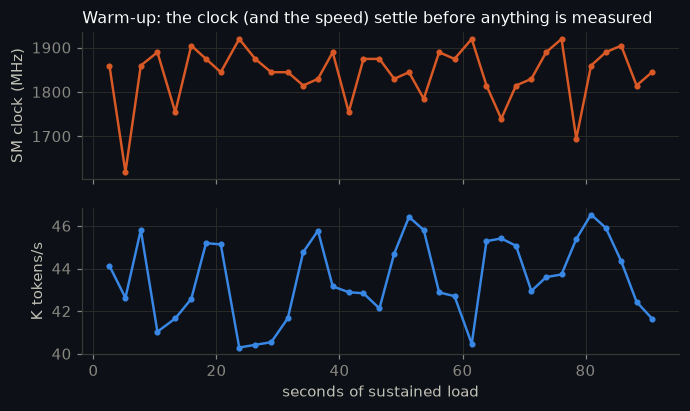

In [51]:
def bench(cfg_name="A", B=8, T=512, precision=AMP, steps=qk(20, 4), warm=4, fused=True, sync_every=1, loader=False, **over):
    """Median-free simple timing of `steps` full training steps on a fixed batch (or the real loader)."""
    free_gpu()
    m = make_model(cfg_name, **over)
    c = m.c
    opt = torch.optim.AdamW(m.parameters(), lr=1e-5, fused=fused, foreach=None if fused else True)
    pl = PackedLoader(TRAIN, T, 0)
    x, y = pl.micro(B)
    x, y = x.to(DEV), y.to(DEV)
    clk, paused = None, 0.0
    with matmul_precision(precision):
        for i in range(warm + steps):
            if i == warm:
                torch.cuda.synchronize(); t0 = time.perf_counter()
            if i == warm + steps // 2:                # read the clock mid-run, under load, and do not time the read
                torch.cuda.synchronize(); tp = time.perf_counter()
                clk = gpu_clocks().get("sm")
                paused += time.perf_counter() - tp
            if loader:
                x, y = pl.micro(B)
                x, y = x.to(DEV, non_blocking=True), y.to(DEV, non_blocking=True)
            with autocast_ctx(precision):
                loss = m(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)      # as in train(): the norm is part of every step
            opt.step(); opt.zero_grad(set_to_none=True)
            if sync_every and i % sync_every == 0:
                loss.item()
        torch.cuda.synchronize()
    dt = (time.perf_counter() - t0 - paused) / steps
    del m, opt, loss
    free_gpu()
    tok = B * T
    return dict(step_ms=1e3 * dt, tok_s=tok / dt, mfu=flops_per_token(c, T) * tok / dt / PEAK, clock=clk)


def abba(configs):
    """Run configs forwards then backwards and average each one's two measurements, so linear drift cancels."""
    names = list(configs)
    got = defaultdict(list)
    for name in names + names[::-1]:
        got[name].append(bench(**configs[name]))
    return {n: dict(step_ms=np.mean([r["step_ms"] for r in v]), tok_s=np.mean([r["tok_s"] for r in v]),
                    mfu=np.mean([r["mfu"] for r in v]), clock=np.mean([r["clock"] or 0 for r in v])) for n, v in got.items()}


def run_mfu():
    out = {}
    ref = dict(cfg_name=MODEL_A, B=qk(8, 4), T=qk(512, 128))
    # 1. warm up to thermal equilibrium, logging the clock
    t_end, clocks = time.time() + qk(90, 10), []
    while time.time() < t_end:
        r = bench(**ref, steps=qk(15, 3), warm=1)
        clocks.append((round(time.time() - t_end + qk(90, 10), 1), r["clock"], r["tok_s"]))
    out["warmup"] = clocks
    # 2. ceilings
    out["gemm_big_tflops"] = gemm_tflops(4096) / 1e12
    c = CFG[MODEL_A]
    BT = ref["B"] * ref["T"]
    shapes = {"qkv-sized": (BT, c.d, c.d), "mlp-sized": (BT, c.d, c.ffn), "head-sized": (BT, c.d, c.vocab)}
    dt_ = torch.bfloat16 if AMP == "bf16" else torch.float16
    small = {}
    for k, (m_, k_, n_) in shapes.items():
        a = torch.randn(m_, k_, device=DEV, dtype=dt_); b = torch.randn(k_, n_, device=DEV, dtype=dt_)
        for _ in range(3):
            a @ b
        torch.cuda.synchronize(); t0 = time.perf_counter()
        for _ in range(20):
            a @ b
        torch.cuda.synchronize()
        small[k] = dict(shape=f"{m_}×{k_} @ {k_}×{n_}", tflops=2 * m_ * k_ * n_ * 20 / (time.perf_counter() - t0) / 1e12)
        del a, b
    out["gemm_model_shapes"] = small
    # 3. the reference, plus one-factor-at-a-time ablations, each interleaved A B B A
    Bh = max(1, ref["B"] // 2)
    out["precision"] = abba({"fp32": dict(ref, B=Bh, precision="fp32"), "tf32": dict(ref, B=Bh, precision="tf32"),
                             AMP: dict(ref, B=Bh, precision=AMP)})
    out["attention"] = abba({"manual softmax(QKᵀ)V": dict(ref, attn="manual"), "fused SDPA kernel": dict(ref)})
    out["micro_batch"] = abba({f"B={b}": dict(ref, B=b) for b in (1, 2, 4, ref["B"])})
    out["optimizer"] = abba({"AdamW, foreach": dict(ref, fused=False), "AdamW, fused": dict(ref)})
    out["sync"] = abba({".item() every step": dict(ref, sync_every=1), "no per-step sync": dict(ref, sync_every=0)})
    out["loader"] = abba({"batch already on GPU": dict(ref), "real loader each step": dict(ref, loader=True)})
    widths = {}
    for d, H, kv in ((256, 4, 2), (384, 6, 2), (512, 8, 2), (768, 12, 4)):
        widths[f"d={d}"] = dict(cfg_name=MODEL_A, B=qk(4, 2), T=qk(512, 128), d=d, n_head=H, n_kv=kv, ffn=int(math.ceil(8 * d / 3 / 64) * 64), n_layer=8)
    widths["SmolLM2-135M (d=576, 30 layers)"] = dict(cfg_name="smollm2_135m", B=qk(4, 2), T=qk(512, 128))
    out["width"] = abba(widths)
    if HAS_TRITON:
        out["compile_note"] = "torch.compile available here but not benchmarked in this notebook"
    out["reference"] = abba({"reference": dict(ref)})["reference"]
    return out


mfu = experiment("mfu", run_mfu, needs_gpu=True)
if mfu:
    ref = mfu["reference"]
    pk, pk_src = R["peak"]["flops"], R["peak"]["source"]
    per_clk = "512 FLOP/clk" in pk_src                     # computed from SMs x FLOP/clk x clock (GeForce)
    peak_obs = R["env"]["sms"] * 512 * ref["clock"] * 1e6 if per_clk and ref["clock"] else None
    gemm = mfu["gemm_big_tflops"] * 1e12
    achieved = ref["mfu"] * pk
    rows = [(f"spec peak at full boost [{pk_src}]", f"{pk / 1e12:.1f}", f"{100 * ref['mfu']:.1f}%")]
    if peak_obs:
        rows.append((f"spec peak at the clock actually observed ({ref['clock']:.0f} MHz)", f"{peak_obs / 1e12:.1f}", f"{100 * achieved / peak_obs:.1f}%"))
    rows.append(("best measured: one 4096³ bf16 matmul", f"{gemm / 1e12:.1f}", f"{100 * achieved / gemm:.1f}%"))
    print(f"Model A, micro-batch {qk(8, 4)}x{qk(512, 128)}, {AMP} autocast, warm GPU: {ref['tok_s'] / 1e3:.1f}K tokens/s = "
          f"{achieved / 1e12:.1f} TFLOP/s of model arithmetic")
    show(md_table(rows, ["measured against", "TFLOP/s", "MFU"]))
    R["mfu_headline"] = dict(mfu_spec=ref["mfu"], mfu_obs_clock=achieved / peak_obs if peak_obs else None, mfu_gemm=achieved / gemm,
                             tok_s=ref["tok_s"], tflops=achieved / 1e12, clock=ref["clock"], gemm_tflops=gemm / 1e12)
    save_results()
    w = np.array(mfu["warmup"], dtype=float)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 3.8), sharex=True)
    a1.plot(w[:, 0], w[:, 1], "o-", color=C["orange"], ms=3); a1.set_ylabel("SM clock (MHz)")
    a2.plot(w[:, 0], w[:, 2] / 1e3, "o-", color=C["blue"], ms=3); a2.set_ylabel("K tokens/s"); a2.set_xlabel("seconds of sustained load")
    a1.set_title("Warm-up: the clock (and the speed) settle before anything is measured")
    finish(fig, "mfu_warmup")

## 20. Where the distance to 40% goes

One factor at a time, each comparison interleaved A-B-B-A on a warm GPU:

matmul precision (micro-batch 4)


| configuration | step | tokens/s | MFU | SM clock (MHz) |
|---|---|---|---|---|
| fp32 | 90.6 ms | 22.6K | 10.9% | 1582 |
| tf32 | 74.6 ms | 27.5K | 13.3% | 1845 |
| bf16 | 73.3 ms | 28.0K | 13.5% | 1898 |

attention kernel


| configuration | step | tokens/s | MFU | SM clock (MHz) |
|---|---|---|---|---|
| manual softmax(QKᵀ)V | 110.0 ms | 37.2K | 18.0% | 1815 |
| fused SDPA kernel | 95.3 ms | 43.0K | 20.8% | 1860 |

micro-batch size (sequences of 512 tokens)


...

| configuration | step | tokens/s | MFU | SM clock (MHz) |
|---|---|---|---|---|
| batch already on GPU | 95.3 ms | 43.0K | 20.8% | 1852 |
| real loader each step | 91.2 ms | 44.9K | 21.7% | 1830 |

model width at a fixed 4×512 micro-batch


| configuration | step | tokens/s | MFU | SM clock (MHz) |
|---|---|---|---|---|
| d=256 | 68.1 ms | 30.1K | 8.7% | 1935 |
| d=384 | 69.0 ms | 29.7K | 14.4% | 1852 |
| d=512 | 76.0 ms | 27.0K | 19.6% | 1905 |
| d=768 | 99.6 ms | 20.6K | 27.1% | 1868 |
| SmolLM2-135M (d=576, 30 layers) | 273.6 ms | 7.5K | 15.9% | 1928 |

A single matmul of the shapes this model actually uses, vs one big square one:


| matmul | shape | TFLOP/s | of the big one |
|---|---|---|---|
| qkv-sized | 4096×384 @ 384×384 | 22.0 | 71% |
| mlp-sized | 4096×384 @ 384×1024 | 25.1 | 82% |
| head-sized | 4096×384 @ 384×49152 | 27.6 | 90% |
| big square | 4096×4096 @ 4096×4096 | 30.7 | 100% |

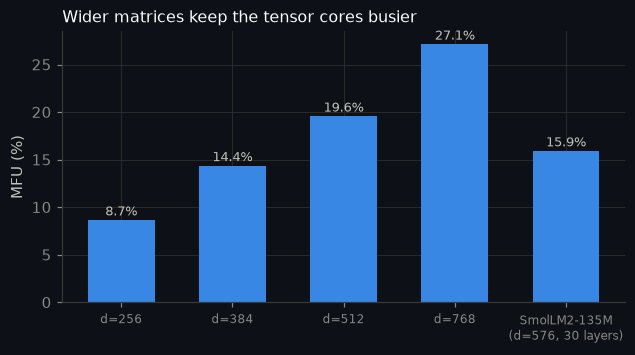

In [52]:
if mfu:
    for key, title in (("precision", f"matmul precision (micro-batch {max(1, qk(8, 4) // 2)})"), ("attention", "attention kernel"),
                       ("micro_batch", "micro-batch size (sequences of 512 tokens)"), ("optimizer", "optimizer kernel"),
                       ("sync", "host-device synchronization"), ("loader", "data loading"),
                       ("width", "model width at a fixed 4×512 micro-batch")):
        print(title)
        show(md_table([(n, f"{r['step_ms']:.1f} ms", f"{r['tok_s'] / 1e3:.1f}K", f"{100 * r['mfu']:.1f}%", f"{r['clock']:.0f}")
                       for n, r in mfu[key].items()], ["configuration", "step", "tokens/s", "MFU", "SM clock (MHz)"]))
    gs = mfu["gemm_model_shapes"]
    print("A single matmul of the shapes this model actually uses, vs one big square one:")
    show(md_table([(k, v["shape"], f"{v['tflops']:.1f}", f"{100 * v['tflops'] / mfu['gemm_big_tflops']:.0f}%") for k, v in gs.items()]
                  + [("big square", "4096×4096 @ 4096×4096", f"{mfu['gemm_big_tflops']:.1f}", "100%")],
                  ["matmul", "shape", "TFLOP/s", "of the big one"]))
    wd = mfu["width"]
    fig, ax = plt.subplots(figsize=(6.6, 3.2))
    names = list(wd)
    ax.bar(range(len(names)), [100 * wd[n]["mfu"] for n in names], color=C["blue"], width=0.6)
    for i, n in enumerate(names):
        ax.text(i, 100 * wd[n]["mfu"] + 0.5, f"{100 * wd[n]['mfu']:.1f}%", ha="center", color=INK2, fontsize=8.5)
    ax.set_xticks(range(len(names)), [n.replace(" (", "\n(") for n in names], fontsize=8)
    ax.set_ylabel("MFU (%)"); ax.set_title("Wider matrices keep the tensor cores busier")
    finish(fig, "mfu_vs_width")

**Where does the time go inside one step?** `torch.profiler` records every GPU kernel. We classify each by name (matrix multiply, attention, normalization, softmax/loss, optimizer, copies, everything else) and compare the GPU's busy time with the step's wall-clock time. That gives an exact three-way split of the gap:

$$
\text{MFU} \;=\; \underbrace{\frac{\text{GPU busy time}}{\text{wall time}}}_{\text{lost: GPU idle}} \times \underbrace{\frac{\text{matmul + attention time}}{\text{GPU busy time}}}_{\text{lost: other kernels}} \times \underbrace{\frac{\text{model FLOPs}}{\text{(matmul + attention time)}\times\text{peak}}}_{\text{lost: matmuls below peak}}
$$

| kernel category | time per step | share of busy time |
|---|---|---|
| matmul | 28.41 ms | 36.1% |
| elementwise / other | 26.66 ms | 33.8% |
| softmax / loss | 14.85 ms | 18.9% |
| attention | 3.82 ms | 4.8% |
| optimizer + clipping | 3.01 ms | 3.8% |
| norms / reductions | 1.45 ms | 1.8% |
| memory copies | 0.59 ms | 0.7% |
| GPU busy (sum of kernels) | 78.79 ms | 100% |
| GPU timeline per step (busy + gaps) | 112.16 ms |  |
| wall time per step, timed without the profiler | 94.93 ms |  |

The ten most expensive kernels:


| category | kernel | per step |
|---|---|---|
| matmul | cutlass · Kernel2 · cutlass_80_tensorop_bf16_s16816gemm_relu_bf16_128x | 11.138 ms |
| softmax / loss | cunn_SoftMaxBackward · LogSoftMaxBackwardEpilogue | 7.425 ms |
| softmax / loss | cunn_SoftMaxForward · LogSoftMaxForwardEpilogue | 7.402 ms |
| matmul | ampere_bf16_s16816gemm_bf16_256x128_ldg8_f2f_stages_32x3_tn | 6.769 ms |
| elementwise / other | unrolled_elementwise_kernel · direct_copy_kernel_cuda · _clEv | 4.742 ms |
| elementwise / other | vectorized_elementwise_kernel · bfloat16_copy_kernel_cuda | 4.675 ms |
| matmul | ampere_bf16_s1688gemm_bf16_128x128_ldg8_f2f_stages_32x1_nn | 3.532 ms |
| elementwise / other | vectorized_elementwise_kernel · CUDAFunctor_add | 3.100 ms |
| attention | fmha_cutlassB_bf16_aligned_64x64_k64_seqaligned_sm80 · PyTorchMemEffAt | 3.001 ms |
| elementwise / other | vectorized_elementwise_kernel · BinaryFunctor · binary_internal | 2.323 ms |

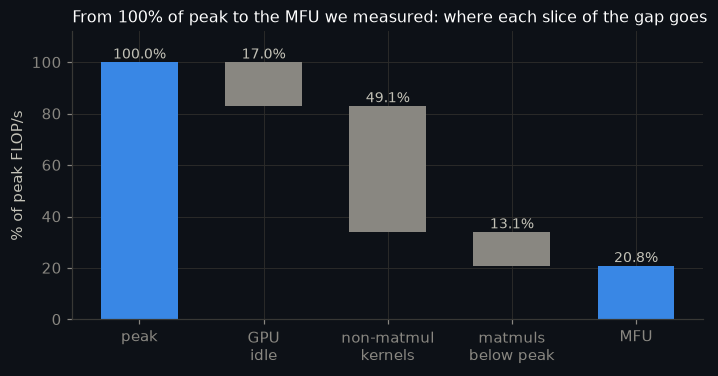

busy 83% of the wall time; matmul + attention are 41% of busy time; inside them the GPU reaches 61% of peak; the product, 20.8%, is the timed MFU (20.8%) split into its three factors. 1191 kernels per step.

What costs the distance to peak, largest first:
  1. kernels that are not matmuls: 49 points of peak
  2. GPU idle: 17 points of peak
  3. matmuls below peak: 13 points of peak
  inside the non-matmul slice: elementwise / other 34%, softmax / loss 19%, optimizer + clipping 4% of GPU time
  and the clock: 20.7% MFU at the spec's full boost is 23.1% at the 1882 MHz the GPU actually held


In [53]:
def kernel_label(name):
    """Readable name for a GPU kernel: pull the identifiers out of a mangled C++ name (_ZN2at6native...)."""
    if not name.startswith("_Z"):
        return name.replace("void ", "")[:70]
    words, i = [], 0
    while i < len(name):
        if name[i].isdigit():
            j = i
            while j < len(name) and name[j].isdigit():
                j += 1
            n, word = int(name[i:j]), name[j:j + int(name[i:j])]
            if n and re.fullmatch(r"[A-Za-z_]\w*", word):
                words.append(word)
                i = j + n
                continue
            i = j
        else:
            i += 1
    junk = ("native", "detail", "void", "array", "TensorIterator", "TensorIteratorBase", "FusedOptimizerTensorListMetadata")
    keep = [w for w in words if len(w) > 4 and w not in junk and not w.startswith(("GLOBAL", "_GLOBAL"))
            and not re.fullmatch(r"E[A-Za-z0-9]{1,4}", w)]
    return " · ".join(list(dict.fromkeys(keep))[:3])[:70] or name[:70]


def kernel_category(name):
    n = kernel_label(name).lower()
    if any(k in n for k in ("flash", "fmha", "attention", "attn")):
        return "attention"
    if any(k in n for k in ("gemm", "cutlass", "xmma", "s16816", "h16816", "cublas", "matmul", "ampere_", "sm80_", "sm86_", "sm90_", "turing_", "volta_")):
        return "matmul"
    if any(k in n for k in ("adam", "multi_tensor", "foreach", "lerp")):
        return "optimizer + clipping"
    if any(k in n for k in ("softmax", "cross_entropy", "nll_loss", "log_softmax")):
        return "softmax / loss"
    if any(k in n for k in ("memcpy", "memset")):
        return "memory copies"
    if "reduce" in n or "norm" in n or "rsqrt" in n:
        return "norms / reductions"
    return "elementwise / other"


def run_profile():
    from torch.profiler import profile, ProfilerActivity, schedule
    from torch.autograd import DeviceType
    ref = dict(cfg_name=MODEL_A, B=qk(8, 4), T=qk(512, 128))
    wall = bench(**ref)                                    # wall time per step without the profiler's overhead
    m = make_model(MODEL_A)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-5, fused=True)
    x, y = PackedLoader(TRAIN, ref["T"], 0).micro(ref["B"])
    x, y = x.to(DEV), y.to(DEV)
    active = 5
    import warnings
    warnings.filterwarnings("ignore", message=".*Profiler clears events.*")
    with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], schedule=schedule(wait=2, warmup=3, active=active)) as prof:
        for _ in range(2 + 3 + active):
            with autocast_ctx(AMP):
                loss = m(x, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); opt.zero_grad(set_to_none=True)
            loss.item()
            prof.step()
    cat, by_name = defaultdict(float), defaultdict(float)
    starts, ends = [], []
    for e in prof.events():
        if e.device_type != DeviceType.CUDA or e.device_time <= 0:
            continue
        if getattr(e, "is_user_annotation", False) or e.name.startswith("ProfilerStep") or "#" in e.name:
            continue                                   # annotation ranges that span many kernels, not kernels
        cat[kernel_category(e.name)] += e.device_time / 1e3 / active          # ms per step
        by_name[(kernel_category(e.name), kernel_label(e.name))] += e.device_time / 1e3 / active
        starts.append(e.time_range.start); ends.append(e.time_range.end)
    del m, opt, loss; free_gpu()
    if not starts:
        return dict(ok=False, wall_ms=wall["step_ms"])
    c = CFG[MODEL_A]
    flops = flops_per_token(c, ref["T"]) * ref["B"] * ref["T"]
    span_ms = (max(ends) - min(starts)) / 1e3 / active                   # GPU timeline per step, idle gaps included
    top = sorted(by_name.items(), key=lambda kv: -kv[1])[:10]
    return dict(ok=True, wall_ms=wall["step_ms"], span_ms=span_ms, cat_ms=dict(cat), busy_ms=sum(cat.values()), flops=flops,
                mfu=wall["mfu"], clock=wall["clock"], kernels_per_step=len(starts) / active,
                top=[(k[0], k[1], v) for k, v in top])


prof_res = experiment("profile", run_profile, needs_gpu=True)
if prof_res and prof_res.get("ok"):
    cat, busy, span = prof_res["cat_ms"], prof_res["busy_ms"], prof_res["span_ms"]
    order = sorted(cat, key=cat.get, reverse=True)
    show(md_table([(k, f"{cat[k]:.2f} ms", f"{100 * cat[k] / busy:.1f}%") for k in order] +
                  [("GPU busy (sum of kernels)", f"{busy:.2f} ms", "100%"),
                   ("GPU timeline per step (busy + gaps)", f"{span:.2f} ms", ""),
                   ("wall time per step, timed without the profiler", f"{prof_res['wall_ms']:.2f} ms", "")],
                  ["kernel category", "time per step", "share of busy time"]))
    print("The ten most expensive kernels:")
    show(md_table([(c_, n_, f"{ms:.3f} ms") for c_, n_, ms in prof_res["top"]], ["category", "kernel", "per step"]))
    mm = cat.get("matmul", 0) + cat.get("attention", 0)
    busy_frac, mm_share = min(1.0, busy / prof_res["wall_ms"]), mm / busy     # kernel time vs a step timed without the profiler
    mm_eff = prof_res["flops"] / (mm / 1e3) / R["peak"]["flops"]
    mfu_ = busy_frac * mm_share * mm_eff
    lost_idle = 1 - busy_frac
    lost_other = busy_frac * (1 - mm_share)
    lost_mm = busy_frac * mm_share * (1 - mm_eff)
    R["mfu_waterfall"] = dict(busy_frac=busy_frac, mm_share=mm_share, mm_eff=mm_eff, mfu=mfu_, lost_idle=lost_idle,
                              lost_other=lost_other, lost_mm=lost_mm, kernels_per_step=prof_res["kernels_per_step"])
    save_results()
    fig, ax = plt.subplots(figsize=(7.4, 3.4))
    steps_ = [("peak", 1.0, 0.0), ("GPU\nidle", lost_idle, 1.0 - lost_idle), ("non-matmul\nkernels", lost_other, 1.0 - lost_idle - lost_other),
              ("matmuls\nbelow peak", lost_mm, mfu_), ("MFU", mfu_, 0.0)]
    for i, (lab, h_, bottom) in enumerate(steps_):
        col = C["blue"] if lab in ("peak", "MFU") else MUTED
        ax.bar(i, 100 * h_, bottom=100 * bottom, color=col, width=0.62)
        ax.text(i, 100 * (bottom + h_) + 1.5, f"{100 * h_:.1f}%", ha="center", color=INK2, fontsize=9)
    ax.set_xticks(range(len(steps_)), [s[0] for s in steps_])
    ax.set_ylabel("% of peak FLOP/s"); ax.set_ylim(0, 112)
    ax.set_title("From 100% of peak to the MFU we measured: where each slice of the gap goes")
    finish(fig, "mfu_waterfall")
    print(f"busy {100 * busy_frac:.0f}% of the wall time; matmul + attention are {100 * mm_share:.0f}% of busy time; "
          f"inside them the GPU reaches {100 * mm_eff:.0f}% of peak; the product, {100 * mfu_:.1f}%, is the timed MFU "
          f"({100 * prof_res['mfu']:.1f}%) split into its three factors. {prof_res['kernels_per_step']:.0f} kernels per step.")
    slices = sorted([("kernels that are not matmuls", lost_other), ("matmuls below peak", lost_mm), ("GPU idle", lost_idle)],
                    key=lambda kv: -kv[1])
    print("\nWhat costs the distance to peak, largest first:")
    for i, (name, v) in enumerate(slices, 1):
        print(f"  {i}. {name}: {100 * v:.0f} points of peak")
    other = sorted(((k, v) for k, v in cat.items() if k not in ("matmul", "attention")), key=lambda kv: -kv[1])
    print("  inside the non-matmul slice: " + ", ".join(f"{k} {100 * v / busy:.0f}%" for k, v in other[:3]) + " of GPU time")
    mh_ = R.get("mfu_headline")
    if mh_ and mh_.get("mfu_obs_clock"):
        print(f"  and the clock: {100 * mh_['mfu_spec']:.1f}% MFU at the spec's full boost is {100 * mh_['mfu_obs_clock']:.1f}% "
              f"at the {mh_['clock']:.0f} MHz the GPU actually held")
elif prof_res:
    print("the profiler captured no GPU kernels on this setup; phase timing above is the fallback")

**So what is costing us the distance to 40%?** The waterfall splits the gap exactly, and the printout below ranks the slices for this run and names what fills the biggest one. The candidates, for a small LLM:

- **Kernels that are not matmuls.** The softmax and cross-entropy over a 49,152-word vocabulary, the dtype conversions (autocast casts every weight to bf16 on every forward pass, and the loss upcasts the logits to fp32), RMSNorm, RoPE, SiLU, the residual adds and the optimizer. Each one moves a lot of memory and does few FLOPs. The fix is **kernel fusion**: `torch.compile` (it needs triton, which this Windows setup does not have, so it is not measured here), fused norm and RoPE kernels, and above all a fused *linear + cross-entropy* kernel that never materializes the fp32 logits.
- **Matmuls below peak.** At width 384 the matrices are thin. The width sweep shows MFU climbing as the model widens, and the single-matmul table shows the model's shapes reaching only part of a big square matmul.
- **An idle GPU.** Python launches every kernel one at a time, and every `.item()` makes the CPU wait for the GPU. CUDA graphs and fewer syncs recover this slice.
- **The laptop's clock.** MFU against the spec at full boost includes the thermal throttle. The row "at the clock actually observed" removes it.

> **Carry forward:** the loss tells you whether it is learning; MFU tells you whether you are paying for hardware you do not use. Measure it warm and interleaved, state the clock, and know which slice of the gap you are fixing.

## 21. Watching a run that lasts weeks

Four traces, each catching what the others cannot. Here they are for the baseline run, with the GPU clock underneath:

| Trace | What it catches |
|---|---|
| **loss** (training and held-out) | whether the model is learning at all; overfitting when the two part |
| **gradient norm** | trouble, before the loss shows it (§11); a missing `zero_grad` (§7) |
| **tokens per second** | something quietly got slower: a slow data loader, a thermal throttle, a noisy neighbour |
| **MFU** | the machine being wasted, which the loss will never mention |

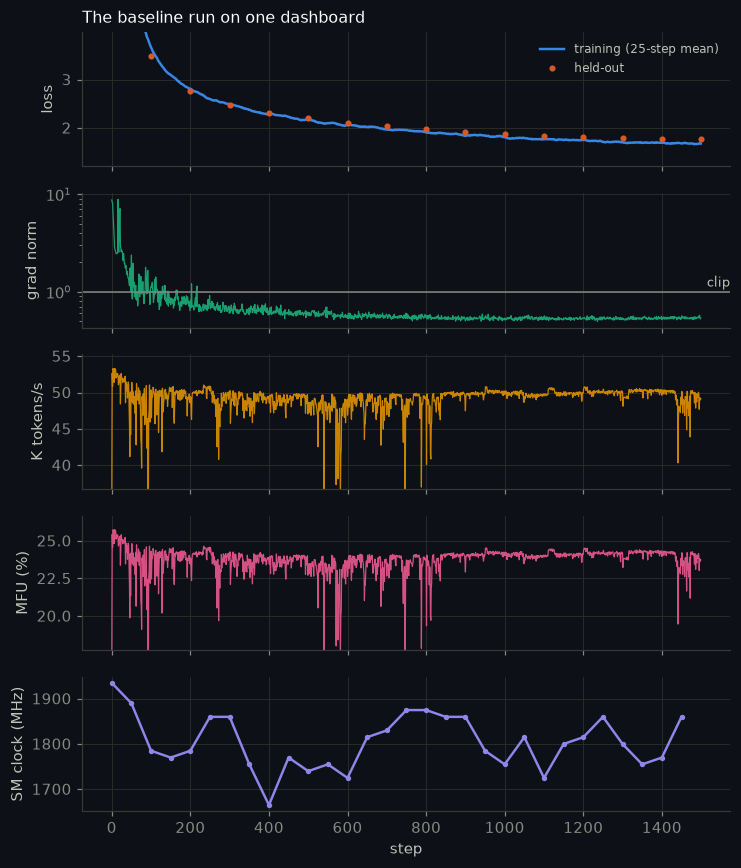

tokens/s: first fifth of the run 49.9K, last fifth 50.1K; SM clock 1822 -> 1808 MHz
median MFU over the run: 24.0% (includes data loading, evaluation pauses excluded)


In [54]:
if base:
    h, v = base["hist"], base["val"]
    st = np.arange(len(h["loss"]))
    fig, axs = plt.subplots(5, 1, figsize=(7.6, 9.2), sharex=True)
    axs[0].plot(st, smooth(h["loss"]), color=C["blue"], label="training (25-step mean)")
    axs[0].plot(v["step"], v["loss"], "o", color=C["orange"], ms=3, label="held-out")
    axs[0].set_ylabel("loss"); axs[0].set_ylim(top=min(6, max(v["loss"][1:] or [6]) + 0.5)); axs[0].legend(fontsize=8)
    axs[1].semilogy(st, h["gnorm"], color=C["aqua"], lw=0.8); axs[1].axhline(base["run"]["clip"], color=MUTED, lw=1)
    label_end(axs[1], st[-1], base["run"]["clip"], "clip", dy=6); axs[1].set_ylabel("grad norm")
    axs[2].plot(st, np.array(h["tok_s"]) / 1e3, color=C["yellow"], lw=0.8); axs[2].set_ylabel("K tokens/s")
    axs[3].plot(st, 100 * arr(h["mfu"]), color=C["magenta"], lw=0.8); axs[3].set_ylabel("MFU (%)")
    if h.get("clock"):
        axs[4].plot(h["clock_step"], arr(h["clock"]), "o-", color=C["violet"], ms=2.5)
    axs[4].set_ylabel("SM clock (MHz)"); axs[4].set_xlabel("step")
    for a_ in axs[2:4]:
        lo_, hi_ = np.nanpercentile(a_.lines[0].get_ydata(), [1, 99.5])
        a_.set_ylim(lo_ * 0.9, hi_ * 1.05)
    axs[0].set_title("The baseline run on one dashboard")
    finish(fig, "dashboard")
    ts, ck = np.array(h["tok_s"]), arr(h.get("clock", []))
    q = len(ts) // 5
    print(f"tokens/s: first fifth of the run {np.median(ts[5:q]) / 1e3:.1f}K, last fifth {np.median(ts[-q:]) / 1e3:.1f}K"
          + (f"; SM clock {np.nanmedian(ck[:max(1, len(ck) // 5)]):.0f} -> {np.nanmedian(ck[-max(1, len(ck) // 5):]):.0f} MHz" if len(ck) else ""))
    print(f"median MFU over the run: {100 * np.nanmedian(arr(h['mfu'])):.1f}% (includes data loading, evaluation pauses excluded)")

Two habits make these traces useful. Agree on a number *before* the run starts (the MFU below which you stop and fix the loop; the gradient-norm level that pages someone), so nobody is negotiating it at three in the morning. And look at tokens/s against the clock: a drop that the clock explains is heat, and a drop it does not explain is your code or your data.

> **Carry forward:** loss for learning, gradient norm for trouble, tokens/s for slowdowns, MFU for waste. Log all four from step one.

---
# Part V: The failures that stay quiet

## 22. Plausible numbers, wrong answers

The failures that end long runs rarely crash. They load without complaint, train without an exception, and produce a loss curve that looks normal. Several have already appeared in this notebook: the forgotten `zero_grad` (§7), the average of averages (§10), fp16 without loss scaling (§15). Four more, each demonstrated live.

### A checkpoint that loads "successfully"

A refactor renamed one module, and a checkpoint lost one tensor on the way. `load_state_dict(..., strict=False)` (often added "to make the error go away") loads everything it can and **returns quietly**. The renamed weight and the lost weight stay at their random initial values.

In [55]:
m_tiny = make_model("tiny", device="cpu")
sd_tiny = m_tiny.state_dict()
sd_tiny["final_norm.weight"] = sd_tiny.pop("norm.weight")
sd_tiny.pop("layers.1.mlp.down_proj.weight")
res_tiny = make_model("tiny", device="cpu").load_state_dict(sd_tiny, strict=False)
print("load_state_dict(strict=False) returned, no exception raised:")
print("  missing   :", res_tiny.missing_keys)
print("  unexpected:", res_tiny.unexpected_keys)
check(len(res_tiny.missing_keys) == 2 and len(res_tiny.unexpected_keys) == 1, "strict=False reports the damage only to those who read its return value")


def run_misload():
    ck = CKPT / "baseline.pt"
    if not ck.exists():
        return None
    sd = torch.load(ck, map_location=DEV)
    windows = val_windows(qk(512, 128), qk(8, 4), qk(10, 2))
    good = make_model(MODEL_A); good.load_state_dict(sd)
    l_good = evaluate(good, windows); del good
    sd2 = dict(sd)
    sd2["final_norm.weight"] = sd2.pop("norm.weight")
    L = CFG[MODEL_A].n_layer
    sd2.pop(f"layers.{L // 2}.mlp.down_proj.weight")
    bad = make_model(MODEL_A)
    r = bad.load_state_dict(sd2, strict=False)
    l_bad = evaluate(bad, windows); del bad; free_gpu()
    return dict(l_good=l_good, l_bad=l_bad, missing=r.missing_keys, unexpected=r.unexpected_keys)


ml = experiment("misload", run_misload)
if ml:
    print(f"Model A, held-out loss: correctly loaded {ml['l_good']:.4f};  loaded with strict=False after the rename "
          f"{ml['l_bad']:.4f}  (+{ml['l_bad'] - ml['l_good']:.3f})")
    observe(ml["l_bad"] > ml["l_good"] + 0.05, "the damaged load is measurably worse, and nothing said so")

load_state_dict(strict=False) returned, no exception raised:
  missing   : ['layers.1.mlp.down_proj.weight', 'norm.weight']
  unexpected: ['final_norm.weight']
✓ strict=False reports the damage only to those who read its return value


Model A, held-out loss: correctly loaded 1.7518;  loaded with strict=False after the rename 2.2760  (+0.524)
✓ the damaged load is measurably worse, and nothing said so


The fix costs two lines: load strictly (or assert that `missing_keys` and `unexpected_keys` are empty, as `load_smollm2` does in §6), and **evaluate the held-out loss immediately after every reload**. It should match the value saved with the checkpoint to several digits.

### Padding counted in the loss

Story-level batches are padded to their longest sequence (§5). If the padding positions are not excluded (`ignore_index=-100`), the "loss" also scores the model on predicting padding. That number depends on how much padding the batch happened to contain, so it cannot be compared across batches, runs or settings.

In [56]:
def run_padding():
    ck = CKPT / "baseline.pt"
    if not ck.exists():
        return None
    m = make_model(MODEL_A); m.load_state_dict(torch.load(ck, map_location=DEV)); m.eval()
    ld = StoryLoader(VALID, 512, 4, seed=99)
    batches = [ld.micro(qk(8, 4), b) for b in range(4)]          # the same stories in both rows
    rows = []
    with torch.no_grad():
        for label, pad_to in (("padded to the longest story in the batch", None), ("padded to 512", 512)):
            tot_ok = tot_pad = n_ok = n_all = 0.0
            for x, y in batches:
                if pad_to:
                    x = F.pad(x, (0, pad_to - x.shape[1]), value=EOS); y = F.pad(y, (0, pad_to - y.shape[1]), value=-100)
                y_pad = torch.where(y == -100, torch.full_like(y, EOS), y)        # padding scored as if it were text
                with autocast_ctx(AMP):
                    tot_ok += m(x.to(DEV), y.to(DEV), reduction="sum").item()
                    tot_pad += m(x.to(DEV), y_pad.to(DEV), reduction="sum").item()
                n_ok += (y != -100).sum().item(); n_all += y.numel()
            rows.append(dict(setup=label, correct=tot_ok / n_ok, with_padding=tot_pad / n_all, pad_frac=1 - n_ok / n_all))
    del m; free_gpu()
    return rows


pad = experiment("padding_counted", run_padding)
if pad:
    show(md_table([(r["setup"], f"{100 * r['pad_frac']:.0f}%", f"{r['correct']:.4f}", f"{r['with_padding']:.4f}") for r in pad],
                  ["batches", "padding positions", "loss, padding ignored (correct)", "loss, padding counted"]))
    observe(abs(pad[1]["with_padding"] - pad[0]["with_padding"]) > 0.05 and abs(pad[1]["correct"] - pad[0]["correct"]) < 1e-3,
            "counted padding makes the loss depend on how the batch was padded; the correct loss does not")

| batches | padding positions | loss, padding ignored (correct) | loss, padding counted |
|---|---|---|---|
| padded to the longest story in the batch | 18% | 1.5929 | 3.8685 |
| padded to 512 | 61% | 1.5928 | 9.3493 |

✓ counted padding makes the loss depend on how the batch was padded; the correct loss does not


### Recompute that does not replay the same randomness

Activation checkpointing (§18) re-runs each block's forward pass during backward. With dropout on, that second run must draw **the same** random mask as the first, otherwise the gradient belongs to a different network than the loss did. PyTorch saves and restores the random-number state for exactly this reason (`preserve_rng_state=True`, the default). Switch it off, as a "speed-up" or by writing a custom recompute, and the gradients are silently wrong. The same rule governs reversible layers, which reconstruct activations instead of storing them, and is why such models are often trained with dropout set to zero.

In [57]:
def grads_under(ckpt, preserve, seed=123):
    m = make_model("tiny", device=gdev, dtype=torch.float64, dropout=0.1)
    m.train(); m.grad_ckpt, m.ckpt_preserve_rng = ckpt, preserve
    x = torch.randint(0, 49152, (2, 33), generator=torch.Generator().manual_seed(1)).to(gdev)
    torch.manual_seed(seed)
    m(x[:, :-1], x[:, 1:]).backward()
    return torch.cat([p.grad.flatten() for p in m.parameters()])


g_plain = grads_under(False, True)
g_ckpt = grads_under(True, True)
g_norng = grads_under(True, False)
e_ok = ((g_ckpt - g_plain).norm() / g_plain.norm()).item()
e_bad = ((g_norng - g_plain).norm() / g_plain.norm()).item()
print(f"gradient with checkpointing, RNG replayed : relative difference {e_ok:.1e} from no checkpointing")
print(f"gradient with checkpointing, RNG not saved: relative difference {e_bad:.1e}")
check(e_ok < 1e-12 and e_bad > 1e-3, "recompute is exact only when it replays the same dropout masks")

gradient with checkpointing, RNG replayed : relative difference 0.0e+00 from no checkpointing
gradient with checkpointing, RNG not saved: relative difference 4.7e-01
✓ recompute is exact only when it replays the same dropout masks


### Evaluating in training mode

`model.eval()` switches dropout (and similar layers) off. Forget it, and every held-out evaluation samples a fresh random sub-network, so the number is noisy and biased upwards.

In [58]:
m_drop = make_model("tiny", device=gdev, dropout=0.1)
xe = torch.randint(0, 49152, (4, 65), generator=torch.Generator().manual_seed(2)).to(gdev)
with torch.no_grad():
    m_drop.train()
    in_train = [m_drop(xe[:, :-1], xe[:, 1:]).item() for _ in range(5)]
    m_drop.eval()
    in_eval = [m_drop(xe[:, :-1], xe[:, 1:]).item() for _ in range(5)]
print("five evaluations in train mode:", [f"{v:.5f}" for v in in_train])
print("five evaluations in eval mode :", [f"{v:.5f}" for v in in_eval])
check(len(set(in_eval)) == 1 and len(set(in_train)) > 1, "eval mode is deterministic; train mode gives a different held-out loss every time")
del m_drop

five evaluations in train mode: ['10.84955', '10.85094', '10.84865', '10.85070', '10.84712']
five evaluations in eval mode : ['10.85044', '10.85044', '10.85044', '10.85044', '10.85044']
✓ eval mode is deterministic; train mode gives a different held-out loss every time


### The checklist

| Failure | What it looks like | The cheap check |
|---|---|---|
| wrong initialization or label shift | first loss far from $\ln V$ | print the step-0 loss (§5) |
| checkpoint loads with missing or renamed keys | a run that resumes "fine" but slightly worse | strict loading; held-out loss right after every reload (§6, §22) |
| forgotten `zero_grad()` | the loss falls for a while, then degrades | the gradient norm grows step after step (§7) |
| average of averages | believable curves, objective tilted to short sequences | normalize by tokens; compare with a one-big-batch gradient (§9–§10) |
| padding counted in the loss | loss depends on batch composition | `ignore_index=-100`; count real tokens (§22) |
| wrong gradients anywhere | training is "just worse" | a float64 gradient check against the nudge (§8) |
| fp16 gradient underflow | learning stalls late in the run | fraction of zero gradients; use bf16 or a `GradScaler` (§15) |
| recompute without the same randomness | slightly wrong gradients, no error | gradient check with recompute on vs off (§22) |
| one abnormal batch | a spike, then a long, slow recovery | gradient norm logged and clipped from step one (§11) |
| the machine is wasted or slowed | the loss looks perfect | tokens/s, MFU and the clock, on the dashboard (§19–§21) |

> **Carry forward:** the dangerous failures do not crash. They produce a plausible number and let you keep going. Print things, and check things.

## 23. Summary

Every number below was measured in this notebook (the full run's values are stored in `assets/results.json`).

In [59]:
def g(path, default=None):
    cur = R
    for k in path.split("/"):
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur


summary = []
if g("grad_check"):
    summary.append(("Does backward() match a nudged weight?",
                    f"Yes: {len(g('grad_check/A') + g('grad_check/smol'))} entries across every parameter type, trained Model A and pretrained SmolLM2, float64, worst "
                    f"{min(r['digits'] for r in g('grad_check/A') + g('grad_check/smol')):.1f} matching digits"))
if g("accum_gradients"):
    ag = g("accum_gradients")
    summary.append(("Average of averages vs token-weighted accumulation (gradient)",
                    f"median error {np.median([r['bug_err'] for r in ag]):.1e} vs {np.median([r['ok_err'] for r in ag]):.1e} "
                    f"against the one-big-batch gradient"))
if g("accum_twins_seeds"):
    rws = twin_rows(g("accum_twins_seeds"))
    summary.append(("…and in training", f"over {len(rws)} seeds: the logged loss is off by {mean_sd([r['gap'] for r in rws], '{:+.1f}')}%; "
                    f"final held-out {mean_sd([r['val_bug'] - r['val_ok'] for r in rws])} vs correct; tilted towards short stories in "
                    f"{sum(r['bucket'][0] < 0 < r['bucket'][-1] for r in rws)} of {len(rws)} seeds"))
if g("stress_detect_seeds"):
    det_ = g("stress_detect_seeds")
    first_ = sum(d["norm_step"] is not None and (d["loss_step"] is None or d["norm_step"] < d["loss_step"]) for d in det_.values())
    lds = [v["loss_step"] - v["norm_step"] for f_ in (g("stress_detect_fixed_seeds") or {}).values() for v in f_.values()
           if v["norm_step"] is not None and v["loss_step"] is not None]
    summary.append(("Did the gradient norm move before the loss?",
                    f"induced instability: the pre-registered rule flagged the norm first in {first_} of {len(det_)} seeds"
                    + (f"; against a fixed pre-ramp baseline the norm led by {min(lds)}–{max(lds)} steps" if lds else "")
                    + ("; a healthy run showed no event at all" if g("natural_events") == [] else "")))
if g("bad_batch_seeds_table"):
    bt = g("bad_batch_seeds_table")
    summary.append(("Does clipping help?", f"against three noise batches it cut the worst damage in "
                    f"{sum(r['damage_clip'] < r['damage_none'] for r in bt)} of {len(bt)} seeds "
                    f"({mean_sd([r['damage_none'] for r in bt])} → {mean_sd([r['damage_clip'] for r in bt])})"))
if g("precision_seeds"):
    pr = g("precision_seeds")
    if "fp16_noscale" in pr:
        fin_ = {p: [s_["val"]["loss"][-1] for s_ in r["seeds"]] for p, r in pr.items()}
        oth = [p for p in fin_ if p != "fp16_noscale"]
        w_ = sum(fin_["fp16_noscale"][i] > max(fin_[p][i] for p in oth) for i in range(len(fin_["fp16_noscale"])))
        summary.append(("Does fp16 need loss scaling?", f"without it, fp16 was the worst precision in {w_} of {len(fin_['fp16_noscale'])} seeds"))
if g("mfu_headline"):
    mh = g("mfu_headline")
    summary.append(("MFU of the training loop", f"{100 * mh['mfu_spec']:.1f}% of the spec peak ({mh['tflops']:.1f} TFLOP/s at "
                    f"{mh['tok_s'] / 1e3:.1f}K tokens/s); {100 * (mh['mfu_obs_clock'] or 0):.1f}% at the observed clock"))
if g("mfu_waterfall"):
    wf = g("mfu_waterfall")
    summary.append(("Where the rest goes", f"GPU idle {100 * wf['lost_idle']:.0f}%, non-matmul kernels {100 * wf['lost_other']:.0f}%, "
                    f"matmuls below peak {100 * wf['lost_mm']:.0f}% of peak"))
summary.append(("0.1 in bits", "fp32 0x3DCCCCCD (0.100000001), bf16 0x3DCD (0.1000977), fp8 E4M3 0x1D (0.1015625)"))
summary.append(("Train in", "bf16 autocast with fp32 master weights and AdamW state; fp8 matmuls only on hardware built for it"))
show(md_table(summary, ["question", "measured answer"]))

| question | measured answer |
|---|---|
| Does backward() match a nudged weight? | Yes: 20 entries across every parameter type, trained Model A and pretrained SmolLM2, float64, worst 7.7 matching digits |
| Average of averages vs token-weighted accumulation (gradient) | median error 2.5e-01 vs 2.9e-05 against the one-big-batch gradient |
| …and in training | over 3 seeds: the logged loss is off by -2.0 ± 0.0%; final held-out +0.0195 ± 0.0178 vs correct; tilted towards short stories in 3 of 3 seeds |
| Did the gradient norm move before the loss? | induced instability: the pre-registered rule flagged the norm first in 0 of 3 seeds; against a fixed pre-ramp baseline the norm led by 20–44 steps; a healthy run showed no event at all |
| Does clipping help? | against three noise batches it cut the worst damage in 3 of 3 seeds (+0.0087 ± 0.0010 → +0.0052 ± 0.0019) |
| Does fp16 need loss scaling? | without it, fp16 was the worst precision in 3 of 3 seeds |
| MFU of the training loop | 20.7% of the spec peak (8.9 TFLOP/s at 42.9K tokens/s); 23.1% at the observed clock |
| Where the rest goes | GPU idle 17%, non-matmul kernels 49%, matmuls below peak 13% of peak |
| 0.1 in bits | fp32 0x3DCCCCCD (0.100000001), bf16 0x3DCD (0.1000977), fp8 E4M3 0x1D (0.1015625) |
| Train in | bf16 autocast with fp32 master weights and AdamW state; fp8 matmuls only on hardware built for it |

### Formula sheet

| Idea | Formula |
|---|---|
| central difference | $\dfrac{\mathcal{L}(w+\varepsilon)-\mathcal{L}(w-\varepsilon)}{2\varepsilon} = \mathcal{L}'(w) + O(\varepsilon^2)$ |
| backprop through $y = Wx$ | $\bar x = W^\top \bar y$, $\quad \bar W = \bar y\,x^\top$ |
| global batch | micro-batch × accumulation steps × GPUs |
| correct accumulation | backprop $S_k / N$ per micro-batch ($S_k$ = summed token losses, $N$ = all tokens) |
| the bug | each token weighted $\frac{1}{K n_k}$ instead of $\frac{1}{N}$ |
| gradient norm, clipping | $\lVert g\rVert = \sqrt{\sum g^2}$, $\quad g \leftarrow g\,\min(1, c/\lVert g\rVert)$ |
| a float | $(-1)^s \times 2^{e-b} \times (1 + m/2^M)$, $\quad b = 2^{E-1}-1$ |
| precision | $\varepsilon = 2^{-M}$, digits $= (M+1)\log_{10}2$ |
| training memory | 16 bytes per weight (+ activations) |
| training FLOPs | $6N + 12LTC$ per token |
| MFU | $F_{\text{token}} \times \text{tokens/s} \,/\, \text{peak FLOP/s}$ |

### Decisions a real run has to make, and what settles them

| Question | What would settle it |
|---|---|
| Which precision? bf16 is safe, fp8 is proven, fp4 is faster and newer | a short run in each on the real architecture, comparing loss and throughput |
| Which clip threshold? | the gradient-norm distribution over the first thousand steps (§11), not habit |
| What MFU is acceptable before stopping to fix the loop? | a number agreed before the run starts |
| Activation checkpointing everywhere, or only in some layers? | a memory-vs-throughput sweep on the hardware actually rented (§18) |

### References

- A. Karpathy, [nanoGPT](https://github.com/karpathy/nanoGPT) and [micrograd](https://github.com/karpathy/micrograd): the minimal GPT and the minimal autograd this notebook echoes.
- Unsloth and Hugging Face (Oct 2024), *Bugs in LLM training: gradient accumulation fix*: the average-of-averages bug and its token-count fix.
- P. Micikevicius et al. (2017), *Mixed Precision Training*: fp32 master weights and loss scaling.
- D. Kalamkar et al. (2019), *A Study of BFLOAT16 for Deep Learning Training*.
- P. Micikevicius et al. (2022), *FP8 Formats for Deep Learning*: E4M3 and E5M2.
- Open Compute Project (2023), *OCP Microscaling Formats (MX) Specification*: MXFP8 and MXFP4.
- NVIDIA (2025), *Pretraining LLMs with NVFP4*: 4-bit training with 16-value blocks and an E4M3 scale.
- A. Chowdhery et al. (2022), *PaLM*, Appendix B: the definition of MFU and the $6N + 12LTC$ count.
- R. Eldan and Y. Li (2023), *TinyStories*; Hugging Face (2024), *SmolLM2*.

In [60]:
secs = R.get("_seconds", {})
if secs:
    show(md_table([(k, f"{v / 60:.1f} min") for k, v in secs.items()] + [("total", f"{sum(secs.values()) / 60:.1f} min")],
                  ["experiment", "time"]))
print(f"results: {RESULTS_FILE if MODE != 'learn' else HERE / 'assets' / 'results.json'}")
save_results()

| experiment | time |
|---|---|
| smollm2_tour | 0.1 min |
| zero_grad_demo | 0.6 min |
| baseline | 8.8 min |
| smollm2_finetune | 1.7 min |
| grad_check | 0.1 min |
| accum_gradients | 0.5 min |
| accum_twins_seeds | 26.1 min |
| stress_seeds | 3.5 min |
| bad_batch_seeds | 3.1 min |
| grad_magnitudes | 0.0 min |
| precision_seeds | 12.7 min |
| quant_real | 0.0 min |
| memory_phases | 0.0 min |
| memory_tricks | 0.3 min |
| mfu | 3.9 min |
| profile | 0.2 min |
| misload | 0.1 min |
| padding_counted | 0.0 min |
| total | 61.7 min |

results: E:\Projects\ERA_V5\10_Training Loop\assets\results.json
